In [10]:
# ============================================================
# Forced conventional test report:
# Acc / Prec / Rec / F1 / mAP with robust label fallback
#   hard JSON → mined (roots→sinks, multi-hop) → heuristic → bootstrap
# ============================================================
import os, re, json, math, time, csv, warnings, random
from pathlib import Path
from collections import defaultdict, deque

import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset
from packaging.version import parse as V
from tqdm.auto import tqdm

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv

# -------------------- env / config --------------------
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[EVAL] device={DEVICE.type}")

MODEL_DIR  = Path("out/cagat_acc_interproc_train")
CKPT_PATH  = str(MODEL_DIR / ("best_model.pt" if (MODEL_DIR / "best_model.pt").exists()
                               else "ckpt_cagat_acc_interproc.pt"))
SPLIT_DIRS = [(sp, Path(f"Dataset/{sp}/hetero_ready_gcbert")) for sp in ("valid","test")]
EVAL_SPLITS = [sp for sp, p in SPLIT_DIRS if p.exists()]
if not EVAL_SPLITS:
    EVAL_SPLITS = ["train"]

THRESHOLD = 0.50              # binarization for metrics
CLEAR_CACHE_EVERY = 10

# 8GB-friendly eval knobs
EVAL_FORCE_BFS = True         # disable dense NxN chain attention
MAX_NODES_FOR_GPU  = 5000
MAX_EDGES_FOR_GPU  = 15000

# Miner knobs (same spirit as training)
TIME_BUDGET_SEC   = 2.0
MINER_MAX_HOPS    = 5
MINER_LIMIT_PATHS = 8
MAX_FRONTIER      = 4096
MAX_VISITED       = 15000
MAX_OUT_DEG       = 64

# Regex seeds (kept but strengthened; only used if JSON text is available)

SINK_NAME_PATTERNS = [
    r"\b(exec|system|popen|spawn|CreateProcess|ShellExecute|eval|Runtime\.exec|ProcessBuilder)\b",
    r"\b(sql|execute(Query|Update)|Statement\.execute|rawQuery|PreparedStatement)\b",
    r"\b(send|write|print|fprintf|fwrite|OutputStream\.write|FileWriter|FileOutputStream)\b",
    r"\b(deserialize|ObjectInputStream|pickle\.loads|JSON\.parse)\b",
]
ROOT_NAME_PATTERNS = [
    r"\b(argv|stdin|getenv|getopt|request|req|input|params?|query|body|post|recv|read|Scanner|BufferedReader)\b",
    r"\b(getParameter|getHeader|getQueryString|getInputStream|readLine)\b",
]

# -------------------- light utils (match training) --------------------
def safe_load(path, map_location="cpu"):
    try:    return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError: return torch.load(path, map_location=map_location)

def _coerce_int(x):
    if isinstance(x, int): return x
    if isinstance(x, str) and x.strip().lstrip("-").isdigit():
        try: return int(x)
        except ValueError: return x
    return x

def _strip_comments_commas(txt: str):
    txt = re.sub(r'//.*?$', '', txt, flags=re.M)
    txt = re.sub(r'/\*.*?\*/', '', txt, flags=re.S)
    txt = txt.replace('\ufeff','').replace('\x00','')
    txt = re.sub(r',\s*(\}|\])', r'\1', txt)
    return txt

def _extract_nodes_array(txt: str):
    m = re.search(r'"nodes"\s*:', txt)
    if not m: return None
    i = m.end()
    while i < len(txt) and txt[i] != '[': i += 1
    if i>=len(txt) or txt[i] != '[': return None
    depth=0; start=i
    for j,ch in enumerate(txt[i:], start=i):
        if ch=='[': depth+=1
        elif ch==']':
            depth-=1
            if depth==0: return txt[start:j+1]
    return None

def load_aug_json(path: str):
    if not path or not os.path.exists(path): return None
    p = Path(path)
    for enc in ("utf-8","utf-8-sig","latin-1"):
        try: raw = p.read_text(enc); break
        except Exception: raw = None
    if raw is None: return None
    try:
        j = json.loads(raw); 
        if isinstance(j,(dict,list)): return j
    except json.JSONDecodeError: pass
    san = _strip_comments_commas(raw)
    try:
        j = json.loads(san); 
        if isinstance(j,(dict,list)): return j
    except json.JSONDecodeError: pass
    arr = _extract_nodes_array(san)
    if arr:
        try:
            nodes = json.loads(arr)
            if isinstance(nodes, list): return {"nodes": nodes}
        except json.JSONDecodeError: pass
    nodes=[]; paths=[]
    for line in san.splitlines():
        line=line.strip()
        if not line or line[0] not in "{[": continue
        try:
            o = json.loads(line)
            if isinstance(o, dict):
                if isinstance(o.get("nodes"), list): nodes += o["nodes"]
                if isinstance(o.get("vulnerable_paths"), list): paths += o["vulnerable_paths"]
                for k in ("sinks","vulnerabilities","vul_nodes","labels","positives","positive_nodes"):
                    if isinstance(o.get(k), list):
                        nodes += [{'_id': x, 'is_sink': True} for x in o[k]]
            elif isinstance(o, list):
                nodes += o
        except json.JSONDecodeError:
            continue
    if nodes or paths:
        d={"nodes": nodes} if nodes else {}
        if paths: d["vulnerable_paths"]=paths
        return d if d else None
    return None

def _harvest_ids_from_any_json(j):
    pos = set()
    if j is None: return pos
    nodes = j["nodes"] if isinstance(j, dict) and isinstance(j.get("nodes"), list) else (j if isinstance(j, list) else [])
    for n in nodes:
        if not isinstance(n, dict): continue
        nid = _coerce_int(n.get("_id"))
        lab = (n.get("label") or n.get("_label") or n.get("class") or n.get("tag") or "")
        lab_u = str(lab).upper()
        is_sink = bool(n.get("is_sink")) or ("SINK" in lab_u) or ("VULN" in lab_u) or ("VULNERABLE" in lab_u)
        if isinstance(nid, int) and is_sink: pos.add(nid)
    if isinstance(j, dict):
        for k in ("sinks","vulnerabilities","vul_nodes","labels","positives","positive_nodes"):
            if isinstance(j.get(k), list):
                for x in j[k]:
                    xi = _coerce_int(x)
                    if isinstance(xi, int): pos.add(xi)
        vps = j.get("vulnerable_paths", [])
        if isinstance(vps, list):
            for p in vps:
                if isinstance(p, (list, tuple)) and len(p)>0:
                    a = _coerce_int(p[0]); b = _coerce_int(p[-1])
                    if isinstance(a, int): pos.add(a)
                    if isinstance(b, int): pos.add(b)
    return pos

def node_sink_labels_from_json(json_path: str, g) -> torch.Tensor | None:
    if not json_path or not os.path.exists(json_path): return None
    j = load_aug_json(json_path)
    if j is None: return None
    pos_ids = _harvest_ids_from_any_json(j)
    st = g["node"]
    device = (st.x_text.device if hasattr(st,"x_text") else (st.x.device if hasattr(st, "x") else "cpu"))
    if hasattr(st, "nid"):
        ids = [ _coerce_int(i) for i in st.nid.view(-1).tolist() ]
        return torch.tensor([ 1.0 if (isinstance(i,int) and i in pos_ids) else 0.0 for i in ids ],
                            dtype=torch.float32, device=device)
    if isinstance(j, dict) and isinstance(j.get("nodes"), list) and len(j["nodes"]) == st.num_nodes:
        ordered_ids = [ _coerce_int(n.get("_id")) if isinstance(n, dict) else None for n in j["nodes"] ]
        return torch.tensor([ 1.0 if (isinstance(i,int) and i in pos_ids) else 0.0 for i in ordered_ids ],
                            dtype=torch.float32, device=device)
    return None

# -------------------- PyG helpers --------------------
def get_edge_index(g: HeteroData, et: tuple[str,str,str]) -> torch.Tensor:
    if et not in g.edge_types:
        dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
               else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
        return torch.zeros((2,0), dtype=torch.long, device=dev)
    store = g[et]
    ei = getattr(store, "edge_index", None)
    if ei is not None: return ei
    adj_t = getattr(store, "adj_t", None)
    if adj_t is not None:
        row, col, _ = adj_t.coo()
        return torch.stack([col, row], dim=0)
    dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
           else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
    return torch.zeros((2,0), dtype=torch.long, device=dev)

def make_inter_mask(g: HeteroData):
    st = g["node"]; N = st.num_nodes
    inter_rel = {'CALL','ARG2PARAM','RET2CALL','RET2LHS','CALL_REV','ARG2PARAM_REV','RET2CALL_REV','RET2LHS_REV'}
    inter_nodes = set()
    for (s,r,t) in g.edge_types:
        if r in inter_rel:
            ei = get_edge_index(g, (s,r,t))
            if ei.numel() > 0:
                inter_nodes.update(ei[0].tolist()); inter_nodes.update(ei[1].tolist())
    device = (st.x_text.device if hasattr(st, 'x_text') else (st.x.device if hasattr(st, 'x') else 'cpu'))
    mask = torch.zeros(N, dtype=torch.bool, device=device)
    if inter_nodes: mask[list(inter_nodes)] = True
    return mask

# -------------------- dataset --------------------
class GraphDir(Dataset):
    def __init__(self, gc_dir: str, unified_dirs):
        self.paths = sorted(Path(gc_dir).glob("*.pt"))
        self.unified_dirs = [Path(d) for d in unified_dirs]
        if not self.paths:
            raise FileNotFoundError(f"No .pt in {gc_dir}")
        print(f"[DATA] {len(self.paths)} graphs in {gc_dir}")
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        pt = self.paths[i]
        g  = safe_load(pt, map_location="cpu")
        stem = Path(pt).stem
        # try to attach json path
        aug = None
        for d in self.unified_dirs:
            if d.exists():
                cands = list(d.glob(stem + ".*"))
                if cands:
                    aug = str(cands[0]); break
        g.__dict__["_aug_json_path"] = aug
        return g

# -------------------- model skeleton (must match training) --------------------
class CAGatBlock(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        assert out_ch % heads == 0
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True,
                                    add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        out_accum = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            et = (s,r,t); ei = get_edge_index(g, et)
            if ei.numel()==0: continue
            key = f"{s}_{r}_{t}"
            out  = self.convs[key](x, ei)
            gate = torch.sigmoid(self.gates[key])
            out_accum = out_accum + gate * out
        out_accum = self.drop(out_accum)
        res = self.proj(x)
        out_accum = self.skip_alpha * res + (1 - self.skip_alpha) * out_accum
        return self.norm(out_accum)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.1,
                 call_chain_attn=True, max_hops=3, sparse_threshold=5000):
        super().__init__()
        self.edge_types = edge_types
        self.hidden     = hidden
        self.projectors = nn.ModuleDict()
        self.blocks     = nn.ModuleList([
            CAGatBlock(hidden, hidden, heads, edge_types, dropout=dropout)
            for _ in range(layers)
        ])
        self.intra_head = nn.Linear(hidden, hidden)
        he_init = nn.Linear(hidden, hidden); nn.init.xavier_uniform_(he_init.weight); nn.init.zeros_(he_init.bias)
        self.inter_head = he_init
        self.context_gru = nn.GRU(hidden, hidden, batch_first=True)
        self.lin_out   = nn.Linear(hidden, 1)
        self.call_chain_attn = call_chain_attn
        self.max_hops        = max_hops
        self.sparse_threshold= sparse_threshold
    def _project_in(self, x: torch.Tensor) -> torch.Tensor:
        d = x.size(1); key = f"proj_{d}"
        if key not in self.projectors:
            lin = nn.Linear(d, self.hidden, device=x.device, dtype=x.dtype)
            nn.init.kaiming_uniform_(lin.weight, a=math.sqrt(5))
            if lin.bias is not None:
                fan_in, _ = nn.init._calculate_fan_in_and_fan_out(lin.weight)
                bound = 1 / math.sqrt(fan_in); nn.init.uniform_(lin.bias, -bound, bound)
            self.projectors[key] = lin
        else:
            self.projectors[key] = self.projectors[key].to(device=x.device, dtype=x.dtype)
        return F.relu(self.projectors[key](x))
    def _call_chain_attn_bfs(self, call_ei, h, N):
        adj = defaultdict(list)
        for i in range(call_ei.size(1)):
            adj[call_ei[0,i].item()].append(call_ei[1,i].item())
        ctx = torch.zeros_like(h)
        for node_id in range(N):
            neighbors = []
            q = deque([(node_id,0)]); seen = {node_id}
            while q:
                cur, d = q.popleft()
                if d >= self.max_hops: continue
                for nb in adj.get(cur, []):
                    if nb not in seen:
                        seen.add(nb); neighbors.append(nb); q.append((nb, d+1))
            if neighbors: ctx[node_id] = h[neighbors].mean(dim=0)
        return h + 0.1 * ctx
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text)
        if hasattr(st,"x"):      xs.append(st.x.float())
        if len(xs) == 1: x = xs[0].to(device=xs[0].device, dtype=torch.float32)
        else:
            tgt = xs[0].device; xs = [t.to(device=tgt, dtype=torch.float32) for t in xs]
            x = torch.cat(xs, dim=1)
        h = self._project_in(x)
        for blk in self.blocks:
            h = F.elu(blk(h, g))
        inter_mask = make_inter_mask(g).to(h.device)
        h_mix = torch.where(inter_mask.unsqueeze(-1), self.inter_head(h), self.intra_head(h))
        et = ("node",'CALL',"node"); ei = get_edge_index(g, et)
        if ei.numel() > 0:
            caller = h_mix[ei[0]]; callee = h_mix[ei[1]]
            seq = torch.stack([caller, callee], dim=1)
            ctx,_ = self.context_gru(seq)
            callee_upd = ctx[:,1,:]
            deg = torch.zeros(h_mix.size(0), device=h_mix.device)
            deg.index_add_(0, ei[1], torch.ones(ei.size(1), device=h_mix.device))
            add = torch.zeros_like(h_mix); add.index_add_(0, ei[1], callee_upd)
            mask = (deg > 0).unsqueeze(-1)
            h_mix = torch.where(mask, h_mix + 0.2 * (add / deg.clamp(min=1).unsqueeze(-1)), h_mix)
        # force BFS chain-attn (OOM-safe)
        call_ei = get_edge_index(g, ("node",'CALL',"node"))
        if self.call_chain_attn and call_ei.numel() > 0:
            h_mix = self._call_chain_attn_bfs(call_ei, h_mix, h_mix.size(0))
        logit = self.lin_out(h_mix).squeeze(-1)
        return logit, h_mix

# -------------------- hyper-params from checkpoint --------------------
def infer_in_dim_edge_types():
    probe = None
    for sp in EVAL_SPLITS + ["train"]:
        p = Path(f"Dataset/{sp}/hetero_ready_gcbert")
        if p.exists():
            fs = list(p.glob("*.pt"))
            if fs: probe = fs[0]; break
    if probe is None:
        raise FileNotFoundError("No graphs found to infer in_dim/edge_types.")
    g = safe_load(str(probe), map_location="cpu")
    st = g["node"]
    in_dim = (st.x_text.size(1) if hasattr(st, "x_text") else 0) + (st.x.size(1) if hasattr(st, "x") else 0)
    return in_dim, tuple(g.edge_types)

chk = torch.load(CKPT_PATH, map_location="cpu")
sd  = chk["model"]

def _infer_hparams(sd):
    hidden = sd["lin_out.weight"].size(1)
    att_keys = [k for k in sd if k.endswith(".att_src")] or [k for k in sd if k.endswith(".att_l")]
    any_att = sd[att_keys[0]]
    if any_att.dim() == 3:
        heads, out_ch = int(any_att.size(1)), int(any_att.size(2))
    else:
        heads, out_ch = int(any_att.size(0)), int(any_att.size(1))
    hidden = heads * out_ch
    layers = max([int(k.split(".")[1]) for k in sd if k.startswith("blocks.")]+[-1]) + 1
    return hidden, heads, layers

in_dim, etypes = infer_in_dim_edge_types()
hidden, heads, layers = _infer_hparams(sd)
model = CAGAT_ACC_InterProc(
    in_dim=in_dim, hidden=hidden, heads=heads, layers=layers,
    edge_types=etypes, dropout=0.10,
    call_chain_attn=True,  # BFS only in this evaluator
    max_hops=3, sparse_threshold=10**9
).to(DEVICE)
model.load_state_dict(sd, strict=False)
model.eval()
print(f"[LOAD] hidden={hidden} heads={heads} layers={layers}")

# -------------------- shrinker --------------------
def shrink_graph_if_needed(g: HeteroData) -> HeteroData:
    st = g["node"]; N = st.num_nodes
    total_edges = 0
    for et in g.edge_types:
        total_edges += int(get_edge_index(g, et).size(1))
    if N <= MAX_NODES_FOR_GPU and total_edges <= MAX_EDGES_FOR_GPU:
        return g
    keep = set()
    inter_rel = {'CALL','ARG2PARAM','RET2CALL','RET2LHS','CALL_REV','ARG2PARAM_REV','RET2CALL_REV','RET2LHS_REV'}
    for (s,r,t) in g.edge_types:
        if r in inter_rel:
            ei = get_edge_index(g, (s,r,t))
            if ei.numel()>0:
                keep.update(ei[0].tolist()); keep.update(ei[1].tolist())
    random.seed(0)
    if len(keep) < min(N, MAX_NODES_FOR_GPU):
        others = [i for i in range(N) if i not in keep]
        random.shuffle(others)
        need = min(N, MAX_NODES_FOR_GPU) - len(keep)
        keep.update(others[:max(0, need)])
    keep = sorted(list(keep))
    idx_map = {old:i for i, old in enumerate(keep)}
    g2 = HeteroData()
    if hasattr(st, "x_text"):
        g2["node"].x_text = st.x_text[keep].to(dtype=torch.float16 if DEVICE.type=='cuda' else torch.float32, device=st.x_text.device)
    if hasattr(st, "x"):
        g2["node"].x = st.x[keep].to(dtype=torch.float16 if DEVICE.type=='cuda' else torch.float32, device=st.x.device)
    if hasattr(st, "nid"):
        g2["node"].nid = st.nid[keep]
    g2["node"].num_nodes = len(keep)
    for (s,r,t) in g.edge_types:
        ei = get_edge_index(g, (s,r,t))
        if ei.numel() == 0:
            g2[(s,r,t)].edge_index = ei; continue
        src, dst = ei
        km = [(u in idx_map and v in idx_map) for u,v in zip(src.tolist(), dst.tolist())]
        if not any(km):
            g2[(s,r,t)].edge_index = torch.zeros((2,0), dtype=torch.long, device=ei.device); continue
        src_f = [src[i].item() for i, m in enumerate(km) if m]
        dst_f = [dst[i].item() for i, m in enumerate(km) if m]
        src_r = torch.tensor([idx_map[u] for u in src_f], dtype=torch.long, device=ei.device)
        dst_r = torch.tensor([idx_map[v] for v in dst_f], dtype=torch.long, device=ei.device)
        if src_r.numel() > MAX_EDGES_FOR_GPU:
            perm = torch.randperm(src_r.numel(), device=ei.device)[:MAX_EDGES_FOR_GPU]
            src_r = src_r[perm]; dst_r = dst_r[perm]
        g2[(s,r,t)].edge_index = torch.stack([src_r, dst_r], dim=0)
    g2.__dict__["_aug_json_path"] = getattr(g, "_aug_json_path", None)
    return g2

# -------------------- weak labels (miner) --------------------
_JSON_CACHE = {}; _JSON_KEYS  = []; _JSON_CACHE_LIMIT = 512
def _json_cache_get(path):
    if not path or not os.path.exists(path): return None
    try:
        if os.path.getsize(path) > 2_000_000: return None
    except Exception: pass
    if path in _JSON_CACHE: return _JSON_CACHE[path]
    j = load_aug_json(path)
    if j is not None:
        _JSON_CACHE[path] = j; _JSON_KEYS.append(path)
        if len(_JSON_KEYS) > _JSON_CACHE_LIMIT:
            old = _JSON_KEYS.pop(0); _JSON_CACHE.pop(old, None)
    return j

def _load_nodes_map_fast(json_path:str):
    j = _json_cache_get(json_path)
    if not isinstance(j, dict) or not isinstance(j.get("nodes"), list):
        return [], {}
    nodes = j["nodes"]; id2node = {}
    for n in nodes:
        if isinstance(n, dict) and "_id" in n:
            id2node[_coerce_int(n["_id"])] = n
    return nodes, id2node

def _node_text_from_json(n:dict) -> str:
    for k in ("code","name","methodFullName","signature","call","label","nodeType"):
        v = n.get(k)
        if isinstance(v,str) and v.strip(): return v
    return ""

def _regex_any(patterns, s):
    if not isinstance(s, str): return False
    for p in patterns:
        if re.search(p, s, flags=re.I): return True
    return False

def _build_adj_fast(g: HeteroData):
    allowed_rels = {'CALL','ARG2PARAM','RET2CALL','RET2LHS','DFG'}
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if r not in allowed_rels: continue
        ei = get_edge_index(g,(s,r,t))
        if ei.numel()==0: continue
        src, dst = ei
        buckets = defaultdict(list)
        for u,v in zip(src.tolist(), dst.tolist()): buckets[u].append(v)
        for u, vs in buckets.items():
            adj[u].extend(vs[:MAX_OUT_DEG])
    return adj

def _bfs_paths_bounded(adj, starts, targets, max_hops=5, limit=8, time_budget=1.0):
    t0 = time.monotonic(); paths = []; targets = set(targets)
    visited_budget = 0
    for s in starts:
        q = deque([(s, [s])])
        while q and len(paths) < limit:
            if (time.monotonic() - t0) > time_budget: return paths
            cur, path = q.popleft()
            if len(path) - 1 > max_hops: continue
            if cur in targets and len(path) > 1:
                paths.append(path[:])
                if len(paths) >= limit: break
            nb_list = adj.get(cur, [])[:MAX_OUT_DEG]
            for nb in nb_list:
                if nb in path: continue
                q.append((nb, path + [nb])); visited_budget += 1
                if visited_budget > MAX_VISITED: return paths
            if len(q) > MAX_FRONTIER:
                while len(q) > MAX_FRONTIER: q.pop()
    return paths

def mine_paths_or_labels(g: HeteroData, json_path: str):
    """Return (y_bin, label_source, mined_paths) — y_bin in {0,1} for metrics."""
    # 1) hard labels
    y = node_sink_labels_from_json(json_path, g)
    if y is not None and y.sum().item() > 0:
        return (y > 0.5).float(), "hard", []

    # 2) text-assisted seeds (if JSON node text available)
    roots, sinks = [], []
    nodes, id2node = _load_nodes_map_fast(json_path) if json_path else ([], {})
    if hasattr(g["node"], "nid") and id2node:
        g_ids = g["node"].nid.view(-1).tolist()
        for nid in g_ids:
            n = id2node.get(_coerce_int(nid)); 
            if not isinstance(n, dict): continue
            txt = _node_text_from_json(n)
            if _regex_any(SINK_NAME_PATTERNS, txt): sinks.append(nid)
            if _regex_any(ROOT_NAME_PATTERNS, txt): roots.append(nid)

    # 3) structure-only seeds if text didn’t find anything
    if not roots:
        ei = get_edge_index(g, ("node","ARG2PARAM","node"))
        if ei.numel()>0: roots = ei[0].unique().tolist()[:256]
    if not sinks:
        for r in ('RET2LHS','RET2CALL','CALL'):
            ei = get_edge_index(g, ("node",r,"node"))
            if ei.numel()>0: sinks.extend(ei[1].unique().tolist())
        sinks = list(set(sinks))[:256]

    # 4) mine paths, then label path endpoints (and interior lightly)
    mined_paths = []
    if roots and sinks:
        adj = _build_adj_fast(g)
        mined_paths = _bfs_paths_bounded(adj, starts=roots, targets=sinks,
                                         max_hops=MINER_MAX_HOPS, limit=MINER_LIMIT_PATHS,
                                         time_budget=TIME_BUDGET_SEC)
    st = g["node"]; N = st.num_nodes
    y_bin = torch.zeros(N, dtype=torch.float32, device=st.x.device if hasattr(st,"x") else "cpu")

    if hasattr(st,"nid"):
        ids = st.nid.view(-1).tolist(); id2pos = {nid:i for i,nid in enumerate(ids)}
    else:
        id2pos = None

    if mined_paths:
        # mark endpoints as 1, interior as 1 too (for metrics we need binary)
        for path in mined_paths:
            for nid in path:
                j = id2pos.get(_coerce_int(nid)) if id2pos is not None else (nid if isinstance(nid,int) else None)
                if j is not None and 0 <= j < N:
                    y_bin[j] = 1.0
        return y_bin, "mined", mined_paths

    # 5) heuristic emergency: mark top CALL-callee degrees as positives
    ei = get_edge_index(g, ("node","CALL","node"))
    if ei.numel()>0:
        deg = torch.zeros(N, device=y_bin.device)
        deg.index_add_(0, ei[1], torch.ones(ei.size(1), device=y_bin.device))
        k = max(1, min(5, int(0.001 * N)))
        idx = torch.topk(deg, k=k, largest=True).indices
        y_bin[idx] = 1.0
        return y_bin, "heuristic", []

    # 6) bootstrap last resort (self-labels from model’s own top-K)
    with torch.no_grad():
        logits, _ = model(g.to(DEVICE))
        probs = torch.sigmoid(logits).detach().cpu()
        k = max(1, min(5, int(0.001 * probs.numel())))
        y_bin_boot = torch.zeros_like(probs)
        topk = torch.topk(probs, k=k).indices
        y_bin_boot[topk] = 1.0
        return y_bin_boot.to(torch.float32), "bootstrap", []

# -------------------- metrics --------------------
def bin_metrics(y_true, y_pred):
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)
    tp = (y_true & y_pred).sum()
    fp = ((1 - y_true) & y_pred).sum()
    fn = (y_true & (1 - y_pred)).sum()
    tn = ((1 - y_true) & (1 - y_pred)).sum()
    acc = (tp + tn) / max(1, (tp + fp + fn + tn))
    prec = tp / max(1, (tp + fp))
    rec  = tp / max(1, (tp + fn))
    f1   = 2 * prec * rec / max(1e-8, (prec + rec))
    return dict(acc=float(acc), precision=float(prec), recall=float(rec), f1=float(f1),
                tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn))

def average_precision(y_true, y_score):
    y_true = y_true.astype(np.int64)
    if y_true.sum() == 0:
        return float('nan')
    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]
    tp = np.cumsum(y_true)
    fp = np.cumsum(1 - y_true)
    precision = tp / np.maximum(1, tp + fp)
    recall = tp / np.maximum(1, y_true.sum())
    for i in range(len(precision) - 2, -1, -1):
        precision[i] = max(precision[i], precision[i + 1])
    idx = np.where(np.diff(np.concatenate(([0.0], recall))) > 0)[0]
    ap = np.sum((recall[idx] - np.concatenate(([0.0], recall[idx[:-1]]))) * precision[idx])
    return float(ap)

def collect_metrics_for_graph(g, logits, y_bin, thr=0.5):
    probs = torch.sigmoid(logits).detach().cpu().numpy()
    ytrue = y_bin.detach().cpu().numpy().astype(np.int64)

    # global
    yhat = (probs > thr).astype(np.int64)
    global_m = bin_metrics(ytrue, yhat)
    global_m["mAP"] = average_precision(ytrue, probs)

    # inter-slice (if any labels in slice)
    mask = make_inter_mask(g).detach().cpu().numpy().astype(bool)
    if mask.sum() > 0 and ytrue[mask].sum() > 0:
        probs_i = probs[mask]; ytrue_i = ytrue[mask]
        yhat_i  = (probs_i > thr).astype(np.int64)
        inter_m = bin_metrics(ytrue_i, yhat_i)
        inter_m["mAP"] = average_precision(ytrue_i, probs_i)
    else:
        inter_m = {"note": "no_inter_labels"}

    return probs, ytrue, mask, {"global": global_m, "inter": inter_m}

# -------------------- evaluate one split --------------------
def evaluate_split(split: str):
    gc_dir = f"Dataset/{split}/hetero_ready_gcbert"
    unified_dirs = [f"Dataset/{split}/unified_json", f"Dataset/{split}/unified", f"Dataset/{split}/unified_aug"]
    ds = GraphDir(gc_dir, unified_dirs)

    jsonl_path = MODEL_DIR / f"metrics_{split}.jsonl"
    csv_path   = MODEL_DIR / f"metrics_{split}.csv"

    # pooled mAP
    pools = {
        "global": {"scores": [], "labels": []},
        "inter":  {"scores": [], "labels": []},
    }

    # aggregates per label_source
    sums = defaultdict(lambda: {"global": {"acc":0, "precision":0, "recall":0, "f1":0, "n":0},
                                "inter":  {"acc":0, "precision":0, "recall":0, "f1":0, "n":0}})
    with open(jsonl_path, "w", encoding="utf-8") as jfh, \
         open(csv_path,  "w", newline="", encoding="utf-8") as cfh, \
         torch.no_grad():
        w = csv.writer(cfh)
        w.writerow(["file","label_source","scope","acc","precision","recall","f1","mAP"])

        for i, pt in enumerate(tqdm(ds.paths, desc=f"[EVAL {split}]"), 1):
            g = safe_load(pt, map_location="cpu")
            g = shrink_graph_if_needed(g).to(DEVICE)

            # get labels (hard or pseudo)
            y_bin, label_source, mined_paths = mine_paths_or_labels(g, getattr(g, "_aug_json_path", None))

            # forward
            logits, _ = model(g)
            probs, ytrue, inter_mask, m = collect_metrics_for_graph(g, logits, y_bin, thr=THRESHOLD)

            rec = {"file": Path(pt).name, "threshold": THRESHOLD, "label_source": label_source,
                   "global": m["global"]}
            if "note" in m["inter"]:
                rec["inter"] = {"note": m["inter"]["note"]}
            else:
                rec["inter"] = m["inter"]

            jfh.write(json.dumps(rec) + "\n")

            # CSV + aggregates
            w.writerow([Path(pt).name, label_source, "global", m["global"]["acc"], m["global"]["precision"], m["global"]["recall"], m["global"]["f1"], m["global"]["mAP"]])
            if "note" not in m["inter"]:
                w.writerow([Path(pt).name, label_source, "inter",  m["inter"]["acc"],  m["inter"]["precision"],  m["inter"]["recall"],  m["inter"]["f1"],  m["inter"]["mAP"]])

            for scope in ("global","inter"):
                if "note" in m[scope]: 
                    continue
                sums[label_source][scope]["acc"]       += float(m[scope]["acc"])
                sums[label_source][scope]["precision"] += float(m[scope]["precision"])
                sums[label_source][scope]["recall"]    += float(m[scope]["recall"])
                sums[label_source][scope]["f1"]        += float(m[scope]["f1"])
                sums[label_source][scope]["n"]         += 1

            # pooled PR for global + (if any labels in inter)
            pools["global"]["scores"].append(probs); pools["global"]["labels"].append(ytrue)
            if inter_mask.sum() > 0 and ytrue[inter_mask].sum() > 0:
                pools["inter"]["scores"].append(probs[inter_mask]); pools["inter"]["labels"].append(ytrue[inter_mask])

            if DEVICE.type=='cuda' and (i % CLEAR_CACHE_EVERY == 0):
                torch.cuda.empty_cache()

    # finalize report
    report = {
        "split": split,
        "threshold": THRESHOLD,
        "jsonl": str(jsonl_path),
        "csv":   str(csv_path),
        "by_label_source": {}
    }
    for src, scopes in sums.items():
        report["by_label_source"][src] = {}
        for scope in ("global","inter"):
            n = scopes[scope]["n"]
            if n > 0:
                report["by_label_source"][src][scope] = {
                    "counted_graphs": n,
                    "acc":       scopes[scope]["acc"]/n,
                    "precision": scopes[scope]["precision"]/n,
                    "recall":    scopes[scope]["recall"]/n,
                    "f1":        scopes[scope]["f1"]/n,
                }
            else:
                report["by_label_source"][src][scope] = {"note": "no_graphs"}

    # pooled mAP (across all label sources together)
    for scope in ("global","inter"):
        if pools[scope]["labels"]:
            y = np.concatenate(pools[scope]["labels"])
            s = np.concatenate(pools[scope]["scores"])
            report[f"{scope}_mAP_pooled"] = average_precision(y, s)

    return report

# -------------------- run all splits, write master report --------------------
master = {
    "checkpoint": CKPT_PATH,
    "device": DEVICE.type,
    "force_bfs": True,
    "max_nodes": MAX_NODES_FOR_GPU,
    "max_edges": MAX_EDGES_FOR_GPU,
    "threshold": THRESHOLD,
    "splits": [],
}
for sp in EVAL_SPLITS:
    rep = evaluate_split(sp)
    master["splits"].append(rep)
    print(f"\n=== {sp.upper()} SUMMARY ===")
    for src, scopes in rep["by_label_source"].items():
        g = scopes["global"]; i = scopes["inter"]
        gtxt = "no_graphs" if "note" in g else f"Acc={g['acc']:.3f}  P={g['precision']:.3f}  R={g['recall']:.3f}  F1={g['f1']:.3f} (n={g['counted_graphs']})"
        itxt = "no_graphs" if "note" in i else f"Acc={i['acc']:.3f}  P={i['precision']:.3f}  R={i['recall']:.3f}  F1={i['f1']:.3f} (n={i['counted_graphs']})"
        print(f"[{src:10s}]  global: {gtxt}   |   inter: {itxt}")
    if "global_mAP_pooled" in rep: print(f"global mAP (pooled): {rep['global_mAP_pooled']:.3f}")
    if "inter_mAP_pooled"  in rep: print(f" inter mAP (pooled): {rep['inter_mAP_pooled']:.3f}")

out_path = MODEL_DIR / "metrics_report_all_sources.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(master, f, indent=2)
print(f"\n[EVAL] wrote {out_path}")


[EVAL] device=cuda


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_12448\3741835622.py:359: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chk = torch.load(CKPT_PATH, map_location="cpu")


[LOAD] hidden=128 heads=4 layers=6
[DATA] 2905 graphs in Dataset/valid/hetero_ready_gcbert


[EVAL valid]: 100%|██████████| 2905/2905 [05:24<00:00,  8.97it/s]



=== VALID SUMMARY ===
[mined     ]  global: Acc=0.440  P=0.000  R=0.000  F1=0.000 (n=2058)   |   inter: no_graphs
[heuristic ]  global: Acc=0.405  P=0.003  R=0.817  F1=0.005 (n=777)   |   inter: Acc=0.254  P=0.010  R=0.817  F1=0.017 (n=777)
[bootstrap ]  global: Acc=0.492  P=0.058  R=1.000  F1=0.108 (n=70)   |   inter: no_graphs
global mAP (pooled): 0.002
 inter mAP (pooled): 0.003
[DATA] 2915 graphs in Dataset/test/hetero_ready_gcbert


[EVAL test]: 100%|██████████| 2915/2915 [05:28<00:00,  8.86it/s]



=== TEST SUMMARY ===
[mined     ]  global: Acc=0.443  P=0.000  R=0.000  F1=0.000 (n=2025)   |   inter: no_graphs
[heuristic ]  global: Acc=0.402  P=0.002  R=0.815  F1=0.004 (n=812)   |   inter: Acc=0.250  P=0.007  R=0.815  F1=0.011 (n=812)
[bootstrap ]  global: Acc=0.489  P=0.060  R=1.000  F1=0.112 (n=78)   |   inter: no_graphs
global mAP (pooled): 0.002
 inter mAP (pooled): 0.003

[EVAL] wrote out\cagat_acc_interproc_train\metrics_report_all_sources.json


In [18]:
# ==============================================================
# EVALUATION (Robust) — handles missing labels with causal proxies
# - Uses direct labels when present
# - Otherwise reports weak-seed metrics + causal chain diagnostics
# ==============================================================

import os, re, json, time, math, warnings
from pathlib import Path
from collections import defaultdict, deque

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm.auto import tqdm

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv

# ----------------------------- Config -----------------------------
CKPT_PATH  = "out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt"   # or best_model.pt
OUT_DIR    = "out/cagat_acc_interproc_train"
SPLITS     = ["valid", "test"]   # change if needed

GC_TMPL    = "Dataset/{split}/hetero_ready_gcbert"
JSON_DIRS  = ["Dataset/{split}/unified_json", "Dataset/{split}/unified_aug", "Dataset/{split}/unified"]

# Match your trained hyperparams
HIDDEN   = 128
HEADS    = 4
LAYERS   = 6
DROPOUT  = 0.10

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THR      = 0.50

# Miner knobs (same spirit as training weak supervision)
TIME_BUDGET_SEC   = 2.0
MAX_OUT_DEG       = 64
MAX_FRONTIER      = 4096
MAX_VISITED       = 15000
MINER_MAX_HOPS    = 5
MINER_LIMIT_PATHS = 8

CALL_CHAIN_ATTN           = True
CALL_CHAIN_MAX_HOPS       = 3
CALL_CHAIN_SPARSE_NTHRESH = 4000  # forces BFS path-attn (safe on 8GB)

os.makedirs(OUT_DIR, exist_ok=True)
warnings.filterwarnings("ignore")

# -------------------------- Utilities ----------------------------
def safe_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def _strip_comments_commas(txt: str) -> str:
    txt = re.sub(r'//.*?$', '', txt, flags=re.M)
    txt = re.sub(r'/\*.*?\*/', '', txt, flags=re.S)
    txt = txt.replace('\ufeff','').replace('\x00','')
    txt = re.sub(r',\s*(\}|\])', r'\1', txt)
    return txt

def _extract_nodes_array(txt: str):
    m = re.search(r'"nodes"\s*:', txt)
    if not m: return None
    i = m.end()
    while i < len(txt) and txt[i] != '[': i += 1
    if i>=len(txt) or txt[i] != '[': return None
    depth=0; start=i
    for j,ch in enumerate(txt[i:], start=i):
        if ch=='[': depth+=1
        elif ch==']':
            depth-=1
            if depth==0: return txt[start:j+1]
    return None

def load_any_json(path: str) -> dict | list | None:
    if not path or not os.path.exists(path): return None
    p = Path(path)
    raw = None
    for enc in ("utf-8","utf-8-sig","latin-1"):
        try:
            raw = p.read_text(enc); break
        except Exception: pass
    if raw is None: return None
    try:
        j = json.loads(raw)
        if isinstance(j,(dict,list)): return j
    except json.JSONDecodeError: pass
    san = _strip_comments_commas(raw)
    try:
        j = json.loads(san)
        if isinstance(j,(dict,list)): return j
    except json.JSONDecodeError: pass
    arr = _extract_nodes_array(san)
    if arr:
        try:
            nodes = json.loads(arr)
            if isinstance(nodes, list): return {"nodes": nodes}
        except json.JSONDecodeError: pass
    nodes=[]; paths=[]
    for line in san.splitlines():
        line=line.strip()
        if not line or line[0] not in "{[": continue
        try:
            o = json.loads(line)
            if isinstance(o, dict):
                if isinstance(o.get("nodes"), list): nodes += o["nodes"]
                if isinstance(o.get("vulnerable_paths"), list): paths += o["vulnerable_paths"]
                for k in ("sinks","vulnerabilities","vul_nodes","labels","positives","positive_nodes"):
                    if isinstance(o.get(k), list):
                        nodes += [{'_id': x, 'is_sink': True} for x in o[k]]
            elif isinstance(o, list):
                nodes += o
        except json.JSONDecodeError:
            continue
    if nodes or paths:
        d={"nodes": nodes} if nodes else {}
        if paths: d["vulnerable_paths"]=paths
        return d if d else None
    return None

def find_json_for_graph(basename: str, split: str) -> str | None:
    for root in [p.format(split=split) for p in JSON_DIRS]:
        d = Path(root)
        for suf in (".json",".aug.json",".unified.json",".jsonl",".txt"):
            p = d / f"{basename}{suf}"
            if p.exists(): return str(p)
        ms = sorted(d.glob(f"{basename}.*"))
        if ms: return str(ms[0])
    return None

def _coerce_int(x):
    if isinstance(x, int): return x
    if isinstance(x, str) and x.strip().lstrip("-").isdigit():
        try: return int(x)
        except ValueError: return x
    return x

def _harvest_sink_ids_from_json(j):
    pos = set()
    if j is None: return pos
    nodes = j["nodes"] if isinstance(j, dict) and isinstance(j.get("nodes"), list) else (j if isinstance(j, list) else [])
    for n in nodes:
        if not isinstance(n, dict): continue
        nid = _coerce_int(n.get("_id"))
        lab = (n.get("label") or n.get("_label") or n.get("class") or n.get("tag") or "")
        lab_u = str(lab).upper()
        is_sink = bool(n.get("is_sink")) or ("SINK" in lab_u) or ("VULN" in lab_u) or ("VULNERABLE" in lab_u)
        if isinstance(nid, int) and is_sink:
            pos.add(nid)
    if isinstance(j, dict):
        for k in ("sinks","vulnerabilities","vul_nodes","labels","positives","positive_nodes"):
            if isinstance(j.get(k), list):
                for x in j[k]:
                    xi = _coerce_int(x)
                    if isinstance(xi, int): pos.add(xi)
        vps = j.get("vulnerable_paths", [])
        if isinstance(vps, list):
            for p in vps:
                if isinstance(p, (list, tuple)) and len(p)>0:
                    a = _coerce_int(p[0]); b = _coerce_int(p[-1])
                    if isinstance(a, int): pos.add(a)
                    if isinstance(b, int): pos.add(b)
    return pos

def node_sink_labels_from_json(json_path: str, g: HeteroData, node_type="node") -> torch.Tensor | None:
    if not json_path or not os.path.exists(json_path): return None
    j = load_any_json(json_path)
    if j is None: return None
    pos_ids = _harvest_sink_ids_from_json(j)
    st = g[node_type]
    device = (st.x_text.device if hasattr(st,"x_text") else (st.x.device if hasattr(st,"x") else "cpu"))
    if hasattr(st, "nid"):
        ids = [ _coerce_int(i) for i in st.nid.view(-1).tolist() ]
        return torch.tensor([ 1.0 if (isinstance(i,int) and i in pos_ids) else 0.0 for i in ids ],
                            dtype=torch.float32, device=device)
    if isinstance(j, dict) and isinstance(j.get("nodes"), list) and len(j["nodes"]) == st.num_nodes:
        ordered_ids = [ _coerce_int(n.get("_id")) if isinstance(n, dict) else None for n in j["nodes"] ]
        return torch.tensor([ 1.0 if (isinstance(i,int) and i in pos_ids) else 0.0 for i in ordered_ids ],
                            dtype=torch.float32, device=device)
    return None

def get_edge_index(g: HeteroData, et: tuple[str,str,str]) -> torch.Tensor:
    if et not in g.edge_types:
        dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
               else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
        return torch.zeros((2,0), dtype=torch.long, device=dev)
    store = g[et]
    ei = getattr(store, "edge_index", None)
    if ei is not None:
        return ei
    adj_t = getattr(store, "adj_t", None)
    if adj_t is not None:
        row, col, _ = adj_t.coo()     # adj_t is transposed
        return torch.stack([col, row], dim=0)
    dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
           else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
    return torch.zeros((2,0), dtype=torch.long, device=dev)

def make_inter_mask(g: HeteroData, node_type="node"):
    st = g[node_type]
    N = st.num_nodes
    inter_rel = {'CALL','ARG2PARAM','RET2CALL','RET2LHS','CALL_REV','ARG2PARAM_REV','RET2CALL_REV','RET2LHS_REV'}
    inter_nodes = set()
    for (s, r, t) in g.edge_types:
        if r in inter_rel:
            ei = get_edge_index(g, (s,r,t))
            if ei.numel() > 0:
                inter_nodes.update(ei[0].tolist())
                inter_nodes.update(ei[1].tolist())
    device = (st.x_text.device if hasattr(st, 'x_text') else (st.x.device if hasattr(st, 'x') else 'cpu'))
    mask = torch.zeros(N, dtype=torch.bool, device=device)
    if inter_nodes:
        mask[list(inter_nodes)] = True
    return mask

# --------------------- Dataset wrapper ---------------------
class GraphDir(Dataset):
    def __init__(self, gc_dir: str, split: str):
        self.split = split
        self.paths = sorted(Path(gc_dir).glob("*.pt"))
        if not self.paths:
            raise FileNotFoundError(f"No .pt in {gc_dir}")
        print(f"[DATA] {len(self.paths)} graphs in {gc_dir}")
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        pt = self.paths[i]
        g  = safe_load(pt, map_location="cpu")
        g.__dict__["_aug_json_path"] = find_json_for_graph(Path(pt).stem, self.split)
        return g

# ------------------ Model (dynamic projector) ------------------
import math
import torch.utils.checkpoint as cp

class CAGatBlock(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        assert out_ch % heads == 0
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True,
                                    add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        out_accum = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            et = (s,r,t)
            ei = get_edge_index(g, et)
            if ei.numel()==0: continue
            key   = f"{s}_{r}_{t}"
            out = self.convs[key](x, ei)
            gate  = torch.sigmoid(self.gates[key])
            out_accum = out_accum + gate * out
        out_accum = self.drop(out_accum)
        res = self.proj(x)
        out_accum = self.skip_alpha * res + (1 - self.skip_alpha) * out_accum
        return self.norm(out_accum)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, hidden, heads, layers, edge_types, dropout=0.1,
                 call_chain_attn=True, max_hops=3, sparse_threshold=4000, node_type="node"):
        super().__init__()
        self.edge_types = edge_types
        self.hidden     = hidden
        self.node_type  = node_type
        self.projectors = nn.ModuleDict()
        self.blocks     = nn.ModuleList([
            CAGatBlock(hidden, hidden, heads, edge_types, dropout=dropout)
            for _ in range(layers)
        ])
        self.intra_head = nn.Linear(hidden, hidden)
        he_init = nn.Linear(hidden, hidden); nn.init.xavier_uniform_(he_init.weight); nn.init.zeros_(he_init.bias)
        self.inter_head = he_init
        self.context_gru = nn.GRU(hidden, hidden, batch_first=True)
        self.lin_out   = nn.Linear(hidden, 1)
        self.call_chain_attn = call_chain_attn
        self.max_hops        = max_hops
        self.sparse_threshold= sparse_threshold

    def _project_in(self, x: torch.Tensor) -> torch.Tensor:
        d = x.size(1)
        key = f"proj_{d}"
        if key not in self.projectors:
            lin = nn.Linear(d, self.hidden, device=x.device, dtype=x.dtype)
            nn.init.kaiming_uniform_(lin.weight, a=math.sqrt(5))
            if lin.bias is not None:
                fan_in, _ = nn.init._calculate_fan_in_and_fan_out(lin.weight)
                bound = 1 / max(1.0, fan_in**0.5)
                nn.init.uniform_(lin.bias, -bound, bound)
            self.projectors[key] = lin
        else:
            self.projectors[key] = self.projectors[key].to(device=x.device, dtype=x.dtype)
        return F.relu(self.projectors[key](x))

    def _call_chain_attn_bfs(self, call_ei, h, N):
        adj = defaultdict(list)
        for i in range(call_ei.size(1)):
            adj[call_ei[0,i].item()].append(call_ei[1,i].item())
        ctx = torch.zeros_like(h)
        for node_id in range(N):
            neighbors = []
            q = deque([(node_id,0)]); seen = {node_id}
            while q:
                cur, d = q.popleft()
                if d >= self.max_hops: continue
                for nb in adj.get(cur, []):
                    if nb not in seen:
                        seen.add(nb); neighbors.append(nb); q.append((nb, d+1))
            if neighbors: ctx[node_id] = h[neighbors].mean(dim=0)
        return h + 0.1 * ctx

    def forward(self, g: HeteroData):
        st = g[self.node_type]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text)
        if hasattr(st,"x"):      xs.append(st.x.float())
        if len(xs) == 1:
            x = xs[0].to(device=xs[0].device, dtype=torch.float32)
        else:
            target_device = xs[0].device
            xs = [t.to(device=target_device, dtype=torch.float32) for t in xs]
            x = torch.cat(xs, dim=1)

        h = self._project_in(x)

        for blk in self.blocks:
            h = F.elu(blk(h, g))

        inter_mask = make_inter_mask(g, node_type=self.node_type).to(h.device)
        h_mix = torch.where(inter_mask.unsqueeze(-1), self.inter_head(h), self.intra_head(h))

        et = (self.node_type,'CALL',self.node_type); ei = get_edge_index(g, et)
        if ei.numel() > 0:
            caller = h_mix[ei[0]]; callee = h_mix[ei[1]]
            seq = torch.stack([caller, callee], dim=1)  # [E,2,H]
            ctx,_ = self.context_gru(seq)
            callee_upd = ctx[:,1,:]
            deg = torch.zeros(h_mix.size(0), device=h_mix.device)
            deg.index_add_(0, ei[1], torch.ones(ei.size(1), device=h_mix.device))
            add = torch.zeros_like(h_mix); add.index_add_(0, ei[1], callee_upd)
            mask = (deg > 0).unsqueeze(-1)
            h_mix = torch.where(mask, h_mix + 0.2 * (add / deg.clamp(min=1).unsqueeze(-1)), h_mix)

        if self.call_chain_attn:
            call_ei = get_edge_index(g, (self.node_type,'CALL',self.node_type))
            if call_ei.numel() > 0:
                N = h_mix.size(0)
                # always BFS (memory-safe)
                h_mix = self._call_chain_attn_bfs(call_ei, h_mix, N)

        logit = self.lin_out(h_mix).squeeze(-1)
        return logit, h_mix

# ------------------- Weak miner (bounded) -------------------
def _build_adj_fast(g: HeteroData):
    allowed = {'CALL','ARG2PARAM','RET2CALL','RET2LHS','DFG'}
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if r not in allowed: continue
        ei = get_edge_index(g,(s,r,t))
        if ei.numel()==0: continue
        src, dst = ei
        buckets = defaultdict(list)
        for u,v in zip(src.tolist(), dst.tolist()): buckets[u].append(v)
        for u, vs in buckets.items():
            adj[u].extend(vs[:MAX_OUT_DEG])
    return adj

def _bfs_paths_bounded(adj, starts, targets, max_hops=5, limit=8, time_budget=1.0):
    t0 = time.monotonic(); paths = []; targets = set(targets)
    visited_budget = 0
    for s in starts:
        q = deque([(s, [s])])
        while q and len(paths) < limit:
            if (time.monotonic() - t0) > time_budget: return paths
            cur, path = q.popleft()
            if len(path) - 1 > max_hops: continue
            if cur in targets and len(path) > 1:
                paths.append(path[:])
                if len(paths) >= limit: break
            for nb in adj.get(cur, [])[:MAX_OUT_DEG]:
                if nb in path: continue
                q.append((nb, path + [nb])); visited_budget += 1
                if visited_budget > MAX_VISITED: return paths
            if len(q) > MAX_FRONTIER:
                while len(q) > MAX_FRONTIER: q.pop()
    return paths

def mine_roots_sinks_and_paths(g: HeteroData, json_path: str | None,
                               max_hops=MINER_MAX_HOPS, limit_paths=MINER_LIMIT_PATHS):
    roots, sinks, paths = [], [], []
    # structural seeds always available
    for r in ('RET2LHS','RET2CALL','CALL'):
        ei = get_edge_index(g, ('node',r,'node'))
        if ei.numel()>0:
            sinks.extend(ei[1].unique().tolist())
    sinks = list(set(sinks))[:256]
    ei = get_edge_index(g, ('node','ARG2PARAM','node'))
    if ei.numel()>0:
        roots = ei[0].unique().tolist()[:256]
    # BFS paths
    if roots and sinks:
        adj = _build_adj_fast(g)
        paths = _bfs_paths_bounded(adj, roots, sinks, max_hops=max_hops,
                                   limit=limit_paths, time_budget=TIME_BUDGET_SEC)
    # fallback: stub pairs
    if not paths and roots and sinks:
        for r in roots[:4]:
            for s in sinks[:4]:
                if r != s:
                    paths.append([r, s])
                    if len(paths) >= limit_paths: break
            if len(paths) >= limit_paths: break
    return roots, sinks, paths

# ----------------- Metrics helpers -----------------
def _counts_from_pred(y_true, y_prob, thr=0.5):
    y_pred = (y_prob > thr).float()
    tp = int(((y_pred==1) & (y_true==1)).sum().item())
    fp = int(((y_pred==1) & (y_true==0)).sum().item())
    fn = int(((y_pred==0) & (y_true==1)).sum().item())
    tn = int(((y_pred==0) & (y_true==0)).sum().item())
    return tp,fp,fn,tn

def _metrics_from_counts(tp, fp, fn, tn):
    prec = tp / (tp+fp+1e-8)
    rec  = tp / (tp+fn+1e-8)
    acc  = (tp+tn) / max(1, (tp+tn+fp+fn))
    f1   = 2*prec*rec / (prec+rec+1e-8)
    return dict(Acc=acc, P=prec, R=rec, F1=f1, support=int(tp+fp+fn+tn))

def _pooled_ap(scores, labels):
    pairs = sorted(zip(scores, labels), key=lambda x: -x[0])
    tp=0; fp=0; precisions=[]; recalls=[]
    total_pos = sum(1 for _,l in pairs if l>0.5)
    if total_pos==0: return 0.0
    for s,l in pairs:
        if l>0.5: tp+=1
        else: fp+=1
        precisions.append(tp / (tp+fp))
        recalls.append(tp / total_pos)
    ap=0.0
    for t in [i/10 for i in range(11)]:
        p_at_r = 0.0
        for p,r in zip(precisions, recalls):
            if r>=t: p_at_r = max(p_at_r, p)
        ap += p_at_r
    return ap/11.0

def _path_monotonicity(prob, paths, nid2pos):
    if not paths: return 0.0, 0
    ok=0; tot=0
    for path in paths:
        idx = [nid2pos.get(_coerce_int(n)) for n in path]
        idx = [i for i in idx if i is not None]
        if len(idx) < 2: continue
        scores = prob[idx]
        is_mono = all(scores[i] <= scores[i+1] + 1e-6 for i in range(len(scores)-1))
        ok += int(is_mono); tot += 1
    return (ok/max(1,tot)), tot

def _caller_callee_coherence(h, g):
    ei = get_edge_index(g, ('node','CALL','node'))
    if ei.numel()==0: return 0.0, 0
    a = h[ei[0]]; b = h[ei[1]]
    cs = F.cosine_similarity(a, b, dim=-1)
    return float(cs.mean().item()), int(cs.numel())

# ---------------------- Evaluate split ----------------------
@torch.no_grad()
def evaluate_split(split: str, ckpt_path: str):
    gc_dir = GC_TMPL.format(split=split)
    ds = GraphDir(gc_dir, split=split)

    sample = safe_load(ds.paths[0], map_location="cpu")
    etypes = tuple(sample.edge_types)

    model = CAGAT_ACC_InterProc(
        hidden=HIDDEN, heads=HEADS, layers=LAYERS, edge_types=etypes,
        dropout=DROPOUT, call_chain_attn=CALL_CHAIN_ATTN, max_hops=CALL_CHAIN_MAX_HOPS,
        sparse_threshold=CALL_CHAIN_SPARSE_NTHRESH
    ).to(DEVICE).eval()

    chk = torch.load(ckpt_path, map_location="cpu")
    missing, unexpected = model.load_state_dict(chk["model"], strict=False)
    print(f"[LOAD] hidden={HIDDEN} heads={HEADS} layers={LAYERS} missing={len(missing)} unexpected={len(unexpected)}")

    # Aggregators
    agg = {
        "supervised": {"TP":0,"FP":0,"FN":0,"TN":0,"scores":[], "labels":[], "graphs":0},
        "weak":       {"TP":0,"FP":0,"FN":0,"TN":0,"scores":[], "labels":[], "graphs":0},
    }
    cov_paths = 0
    sum_path_mono = 0.0; cnt_path_mono = 0
    sum_call_coh = 0.0; cnt_call_coh = 0

    details_path = os.path.join(OUT_DIR, f"metrics_{split}_robust.jsonl")
    fh = open(details_path, "w", encoding="utf-8")

    for pt in tqdm(ds.paths, desc=f"[EVAL {split}]"):
        g = safe_load(pt, map_location="cpu")
        g.__dict__["_aug_json_path"] = find_json_for_graph(Path(pt).stem, split)
        g = g.to(DEVICE)

        logits, h = model(g)
        prob = torch.sigmoid(logits)

        # 1) Supervised (true labels if present)
        y_true = node_sink_labels_from_json(getattr(g, "_aug_json_path", None), g)
        sup_counts=None
        if y_true is not None and y_true.sum()>0:
            y_true = y_true.to(prob.device)
            tp,fp,fn,tn = _counts_from_pred(y_true, prob, thr=THR)
            agg["supervised"]["TP"]+=tp; agg["supervised"]["FP"]+=fp
            agg["supervised"]["FN"]+=fn; agg["supervised"]["TN"]+=tn
            agg["supervised"]["scores"].extend(prob.detach().cpu().tolist())
            agg["supervised"]["labels"].extend(y_true.detach().cpu().tolist())
            agg["supervised"]["graphs"]+=1
            sup_counts = (tp,fp,fn,tn)

        # 2) Weak: seeds and paths
        st = g["node"]
        if hasattr(st,"nid"):
            ids = st.nid.view(-1).tolist(); nid2pos = {int(n):i for i,n in enumerate(ids)}
        else:
            nid2pos = {i:i for i in range(st.num_nodes)}
        roots, sinks, paths = mine_roots_sinks_and_paths(g, getattr(g,"_aug_json_path", None))
        cov_paths += int(len(paths)>0)

        # weak labels: mark root..sink endpoints on mined paths (endpoints stronger)
        weak = torch.zeros_like(prob)
        for P in paths:
            idx = [nid2pos.get(_coerce_int(n)) for n in P]
            idx = [i for i in idx if i is not None]
            if not idx: continue
            L = max(2, len(idx))
            for k,j in enumerate(idx):
                weak[j] = max(weak[j], 0.3 + 0.6*(k/(L-1)))
        if weak.sum()>0:
            tp,fp,fn,tn = _counts_from_pred((weak>0.5).float(), prob, thr=THR)
            agg["weak"]["TP"]+=tp; agg["weak"]["FP"]+=fp
            agg["weak"]["FN"]+=fn; agg["weak"]["TN"]+=tn
            agg["weak"]["scores"].extend(prob.detach().cpu().tolist())
            agg["weak"]["labels"].extend((weak>0.5).float().detach().cpu().tolist())
            agg["weak"]["graphs"]+=1

        # causal diagnostics
        pm, used = _path_monotonicity(prob, paths, nid2pos)
        sum_path_mono += pm * used
        cnt_path_mono += used
        coh, usedc = _caller_callee_coherence(h, g)
        sum_call_coh += coh * usedc
        cnt_call_coh += usedc

        fh.write(json.dumps({
            "file": Path(pt).stem,
            "has_true_labels": bool(y_true is not None and y_true.sum()>0),
            "sup_counts": sup_counts,
            "paths": len(paths),
            "path_monotonicity_used": used,
            "path_monotonicity": pm if used>0 else None,
            "call_coherence_used": usedc,
            "call_coherence": coh if usedc>0 else None
        })+"\n")

    fh.close()

    # build report
    rep = {"split": split, "threshold": THR, "details_jsonl": details_path}

    # supervised block (only if any graphs had labels)
    if agg["supervised"]["graphs"]>0:
        s = agg["supervised"]
        m = _metrics_from_counts(s["TP"], s["FP"], s["FN"], s["TN"])
        m["mAP"] = _pooled_ap(s["scores"], s["labels"])
        m["graphs_with_labels"] = agg["supervised"]["graphs"]
        rep["supervised"] = m
    else:
        rep["supervised"] = {"note": "no_graphs_with_labels"}

    # weak block (always available when miner finds anything)
    if agg["weak"]["graphs"]>0:
        w = agg["weak"]
        m = _metrics_from_counts(w["TP"], w["FP"], w["FN"], w["TN"])
        m["mAP"] = _pooled_ap(w["scores"], w["labels"])
        m["graphs_with_weak_labels"] = agg["weak"]["graphs"]
        m["coverage_paths"] = cov_paths / max(1, len(ds.paths))
        rep["weak_seeded"] = m
    else:
        rep["weak_seeded"] = {"note": "miner_found_no_paths"}

    # causal diagnostics
    rep["diagnostics"] = {
        "path_monotonicity_avg": (sum_path_mono/max(1,cnt_path_mono)) if cnt_path_mono>0 else None,
        "path_monotonicity_paths_used": int(cnt_path_mono),
        "call_chain_coherence_avg": (sum_call_coh/max(1,cnt_call_coh)) if cnt_call_coh>0 else None,
        "call_chain_pairs_used": int(cnt_call_coh),
    }

    out_json = os.path.join(OUT_DIR, f"metrics_{split}_robust.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(rep, f, indent=2)
    print(f"\n=== {split.upper()} (ROBUST REPORT) ===")
    print(json.dumps(rep, indent=2))
    print(f"[WRITE] {out_json}")
    return rep

# ----------------------------- Run -----------------------------
print(f"[EVAL] device={DEVICE.type}")
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

all_reports = []
for sp in SPLITS:
    gc_dir = GC_TMPL.format(split=sp)
    assert os.path.isdir(gc_dir), f"Graph dir not found: {gc_dir}"
    all_reports.append(evaluate_split(sp, CKPT_PATH))

final = os.path.join(OUT_DIR, "metrics_report_robust.json")
with open(final, "w", encoding="utf-8") as f:
    json.dump({"reports": all_reports}, f, indent=2)
print(f"\n[WRITE] {final}")


[EVAL] device=cuda
[DATA] 2905 graphs in Dataset/valid/hetero_ready_gcbert
[LOAD] hidden=128 heads=4 layers=6 missing=0 unexpected=28


[EVAL valid]: 100%|██████████| 2905/2905 [04:41<00:00, 10.32it/s]



=== VALID (ROBUST REPORT) ===
{
  "split": "valid",
  "threshold": 0.5,
  "details_jsonl": "out/cagat_acc_interproc_train\\metrics_valid_robust.jsonl",
  "supervised": {
    "note": "no_graphs_with_labels"
  },
  "weak_seeded": {
    "note": "miner_found_no_paths"
  },
  "diagnostics": {
    "path_monotonicity_avg": null,
    "path_monotonicity_paths_used": 0,
    "call_chain_coherence_avg": 0.23544000245487515,
    "call_chain_pairs_used": 820174
  }
}
[WRITE] out/cagat_acc_interproc_train\metrics_valid_robust.json
[DATA] 2915 graphs in Dataset/test/hetero_ready_gcbert
[LOAD] hidden=128 heads=4 layers=6 missing=0 unexpected=28


[EVAL test]: 100%|██████████| 2915/2915 [04:39<00:00, 10.44it/s]


=== TEST (ROBUST REPORT) ===
{
  "split": "test",
  "threshold": 0.5,
  "details_jsonl": "out/cagat_acc_interproc_train\\metrics_test_robust.jsonl",
  "supervised": {
    "note": "no_graphs_with_labels"
  },
  "weak_seeded": {
    "note": "miner_found_no_paths"
  },
  "diagnostics": {
    "path_monotonicity_avg": null,
    "path_monotonicity_paths_used": 0,
    "call_chain_coherence_avg": 0.19578031284842037,
    "call_chain_pairs_used": 823385
  }
}
[WRITE] out/cagat_acc_interproc_train\metrics_test_robust.json

[WRITE] out/cagat_acc_interproc_train\metrics_report_robust.json


In [19]:
# ==============================================================
# Root → … → Sink Chain Reconstruction & Report (VALID + TEST)
# ==============================================================

import os, re, json, math, time, warnings, random
from pathlib import Path
from collections import defaultdict, deque

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv

warnings.filterwarnings("ignore")

# ----------------------- Paths & toggles -----------------------
CKPT_PATH = "out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt"  # or best_model.pt
OUT_DIR   = "out/cagat_acc_interproc_train"
SPLITS    = ["valid", "test"]

GC_DIR_TMPL    = "Dataset/{split}/hetero_ready_gcbert"
UNIFIED_DIRS   = ["Dataset/{split}/unified_json", "Dataset/{split}/unified_aug", "Dataset/{split}/unified"]

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------- Model hyperparams ---------------------
# (match what you trained with; LAYERS/HEADS/HIDDEN must match)
HIDDEN   = 128
HEADS    = 4
LAYERS   = 6
DROPOUT  = 0.10

# call-chain attention settings (kept memory-safe)
CALL_CHAIN_ATTN           = True
CALL_CHAIN_MAX_HOPS       = 3
CALL_CHAIN_SPARSE_NTHRESH = 4000  # forces BFS-style attention on small GPUs

# ---------------------- Chain mining knobs ---------------------
MAX_HOPS        = 8      # max hops allowed in chain
BEAM_WIDTH      = 16     # beam search width
TIME_BUDGET_S   = 2.0    # per-sink time budget
MONO_SLACK      = 0.08   # allow small score drop along chain
EDGE_PRIORS = {          # stronger bias for inter-proc edges
    'CALL': -0.05, 'ARG2PARAM': -0.07, 'RET2CALL': -0.06, 'RET2LHS': -0.05,
    'DFG': -0.02,
    # smaller (worse) prior if we have to go reverse
    'CALL_REV': 0.02, 'ARG2PARAM_REV': 0.03, 'RET2CALL_REV': 0.03, 'RET2LHS_REV': 0.03,
    'DFG_REV': 0.01
}
# candidate selection
TOPK_SINKS_PER_GRAPH = 20
SINK_PROB_THR        = 0.60  # additionally keep sinks above this prob
# JSON-derived name hints (optional, soft)
ROOT_NAME_PATTERNS = [
    r"\b(argv|stdin|getenv|getopt|request|req|input|params?|query|body|post|recv|read)\b"
]
SINK_NAME_PATTERNS = [
    r"\b(exec|system|popen|spawn|CreateProcess|ShellExecute|eval|Runtime\.exec|ProcessBuilder)\b",
    r"\b(sql|execute(Query|Update)|Statement\.execute|rawQuery|PreparedStatement)\b"
]

os.makedirs(OUT_DIR, exist_ok=True)

# ---------------------------- IO utils ----------------------------
def safe_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def _strip_comments_commas(txt: str) -> str:
    txt = re.sub(r'//.*?$', '', txt, flags=re.M)
    txt = re.sub(r'/\*.*?\*/', '', txt, flags=re.S)
    txt = txt.replace('\ufeff','').replace('\x00','')
    txt = re.sub(r',\s*(\}|\])', r'\1', txt)
    return txt

def _extract_nodes_array(txt: str):
    m = re.search(r'"nodes"\s*:', txt)
    if not m: return None
    i = m.end()
    while i < len(txt) and txt[i] != '[': i += 1
    if i>=len(txt) or txt[i] != '[': return None
    depth=0; start=i
    for j,ch in enumerate(txt[i:], start=i):
        if ch=='[': depth+=1
        elif ch==']':
            depth-=1
            if depth==0: return txt[start:j+1]
    return None

def load_any_json(path: str) -> dict | list | None:
    if not path or not os.path.exists(path): return None
    p = Path(path)
    raw = None
    for enc in ("utf-8","utf-8-sig","latin-1"):
        try:
            raw = p.read_text(enc); break
        except Exception: pass
    if raw is None: return None
    try:
        j = json.loads(raw)
        if isinstance(j,(dict,list)): return j
    except json.JSONDecodeError: pass
    san = _strip_comments_commas(raw)
    try:
        j = json.loads(san)
        if isinstance(j,(dict,list)): return j
    except json.JSONDecodeError: pass
    arr = _extract_nodes_array(san)
    if arr:
        try:
            nodes = json.loads(arr)
            if isinstance(nodes, list): return {"nodes": nodes}
        except json.JSONDecodeError: pass
    nodes=[]; paths=[]
    for line in san.splitlines():
        line=line.strip()
        if not line or line[0] not in "{[": continue
        try:
            o = json.loads(line)
            if isinstance(o, dict):
                if isinstance(o.get("nodes"), list): nodes += o["nodes"]
                if isinstance(o.get("vulnerable_paths"), list): paths += o["vulnerable_paths"]
                for k in ("sinks","vulnerabilities","vul_nodes","labels","positives","positive_nodes","roots","sources"):
                    if isinstance(o.get(k), list):
                        nodes += [{'_id': x, 'is_seed': True} for x in o[k]]
            elif isinstance(o, list):
                nodes += o
        except json.JSONDecodeError:
            continue
    if nodes or paths:
        d={"nodes": nodes} if nodes else {}
        if paths: d["vulnerable_paths"]=paths
        return d if d else None
    return None

def find_json_for_graph(basename: str, split: str) -> str | None:
    for root in [p.format(split=split) for p in UNIFIED_DIRS]:
        d = Path(root)
        for suf in (".json",".aug.json",".unified.json",".jsonl",".txt"):
            p = d / f"{basename}{suf}"
            if p.exists(): return str(p)
        ms = sorted(d.glob(f"{basename}.*"))
        if ms: return str(ms[0])
    return None

def _coerce_int(x):
    if isinstance(x, int): return x
    if isinstance(x, str) and x.strip().lstrip("-").isdigit():
        try: return int(x)
        except ValueError: return x
    return x

# ------------------------ JSON harvesting ------------------------
def _node_text(n:dict) -> str:
    for k in ("code","name","methodFullName","signature","call","label","nodeType"):
        v = n.get(k)
        if isinstance(v,str) and v.strip(): return v
    return ""

def _regex_any(rx_list, s):
    if not isinstance(s, str): return False
    for r in rx_list:
        if re.search(r, s, flags=re.I):
            return True
    return False

def harvest_roots_sinks_from_json(json_path: str):
    roots=set(); sinks=set()
    j = load_any_json(json_path) if json_path else None
    if not isinstance(j, (dict, list)): return list(roots), list(sinks), {}
    nodes = j["nodes"] if isinstance(j, dict) and isinstance(j.get("nodes"), list) else (j if isinstance(j, list) else [])
    id2name={}
    for n in nodes:
        if not isinstance(n, dict): continue
        nid = _coerce_int(n.get("_id"))
        if not isinstance(nid,int): continue
        name = _node_text(n); 
        if name: id2name[nid]=name
        lab = (n.get("label") or n.get("_label") or n.get("class") or n.get("tag") or "")
        lu = str(lab).upper()
        is_sink = bool(n.get("is_sink")) or ("SINK" in lu) or ("VULN" in lu) or ("VULNERABLE" in lu)
        if is_sink: sinks.add(nid)
        # try explicit "root"/"source" if present
        if any(k in n for k in ("is_root","is_source","source")) or ("ROOT" in lu) or ("SOURCE" in lu):
            roots.add(nid)
        # fallback: name patterns
        if _regex_any(ROOT_NAME_PATTERNS, name):
            roots.add(nid)
        if _regex_any(SINK_NAME_PATTERNS, name):
            sinks.add(nid)
    return list(roots), list(sinks), id2name

# --------------------- Graph helpers ---------------------
def get_edge_index(g: HeteroData, et: tuple[str,str,str]) -> torch.Tensor:
    if et not in g.edge_types:
        dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
               else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
        return torch.zeros((2,0), dtype=torch.long, device=dev)
    store = g[et]
    ei = getattr(store, "edge_index", None)
    if ei is not None: return ei
    adj_t = getattr(store, "adj_t", None)
    if adj_t is not None:
        row, col, _ = adj_t.coo()
        return torch.stack([col, row], dim=0)
    dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
           else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
    return torch.zeros((2,0), dtype=torch.long, device=dev)

def build_multi_adj(g: HeteroData):
    """Return forward and reverse adjacency keyed by relation name we use for taint."""
    forward = defaultdict(list); backward = defaultdict(list)
    use = ['CALL','ARG2PARAM','RET2CALL','RET2LHS','DFG']
    for r in use:
        et = ('node', r, 'node')
        ei = get_edge_index(g, et)
        if ei.numel()==0: continue
        src, dst = ei
        for u,v in zip(src.tolist(), dst.tolist()):
            forward[u].append((v, r))
            backward[v].append((u, r+"_REV"))
    return forward, backward

# --------------------- Model skeleton ---------------------
import torch.utils.checkpoint as cp

class CAGatBlock(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        assert out_ch % heads == 0
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True,
                                    add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        out_accum = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = get_edge_index(g, (s,r,t))
            if ei.numel()==0: continue
            out = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            out_accum = out_accum + gate * out
        out_accum = self.drop(out_accum)
        res = self.proj(x)
        out_accum = self.skip_alpha * res + (1 - self.skip_alpha) * out_accum
        return self.norm(out_accum)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, hidden, heads, layers, edge_types, dropout=0.1,
                 call_chain_attn=True, max_hops=3, sparse_threshold=4000, node_type="node"):
        super().__init__()
        self.edge_types = edge_types
        self.hidden     = hidden
        self.node_type  = node_type
        self.projectors = nn.ModuleDict()
        self.blocks     = nn.ModuleList([
            CAGatBlock(hidden, hidden, heads, edge_types, dropout=dropout)
            for _ in range(layers)
        ])
        self.intra_head = nn.Linear(hidden, hidden)
        he_init = nn.Linear(hidden, hidden); nn.init.xavier_uniform_(he_init.weight); nn.init.zeros_(he_init.bias)
        self.inter_head = he_init
        self.context_gru = nn.GRU(hidden, hidden, batch_first=True)
        self.lin_out   = nn.Linear(hidden, 1)
        self.call_chain_attn = call_chain_attn
        self.max_hops        = max_hops
        self.sparse_threshold= sparse_threshold

    def _project_in(self, x: torch.Tensor) -> torch.Tensor:
        d = x.size(1); key = f"proj_{d}"
        if key not in self.projectors:
            lin = nn.Linear(d, self.hidden, device=x.device, dtype=x.dtype)
            nn.init.kaiming_uniform_(lin.weight, a=math.sqrt(5))
            if lin.bias is not None:
                fan_in, _ = nn.init._calculate_fan_in_and_fan_out(lin.weight)
                bound = 1 / max(1.0, fan_in**0.5)
                nn.init.uniform_(lin.bias, -bound, bound)
            self.projectors[key] = lin
        else:
            self.projectors[key] = self.projectors[key].to(device=x.device, dtype=x.dtype)
        return F.relu(self.projectors[key](x))

    def forward(self, g: HeteroData):
        st = g[self.node_type]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text)
        if hasattr(st,"x"):      xs.append(st.x.float())
        if len(xs) == 1:
            x = xs[0].to(device=xs[0].device, dtype=torch.float32)
        else:
            target_device = xs[0].device
            xs = [t.to(device=target_device, dtype=torch.float32) for t in xs]
            x = torch.cat(xs, dim=1)
        h = self._project_in(x)
        for blk in self.blocks:
            h = F.elu(blk(h, g))
        inter_nodes = set()
        for (s,r,t) in g.edge_types:
            if r in {'CALL','ARG2PARAM','RET2CALL','RET2LHS','CALL_REV','ARG2PARAM_REV','RET2CALL_REV','RET2LHS_REV'}:
                ei = get_edge_index(g,(s,r,t))
                if ei.numel()>0:
                    inter_nodes.update(ei[0].tolist()); inter_nodes.update(ei[1].tolist())
        mask = torch.zeros(h.size(0), dtype=torch.bool, device=h.device)
        if inter_nodes: mask[list(inter_nodes)] = True
        h = torch.where(mask.unsqueeze(-1), self.intra_head(h), self.inter_head(h))
        et = (self.node_type,'CALL',self.node_type); ei = get_edge_index(g, et)
        if ei.numel() > 0:
            caller = h[ei[0]]; callee = h[ei[1]]
            seq = torch.stack([caller, callee], dim=1)
            ctx,_ = self.context_gru(seq)
            callee_upd = ctx[:,1,:]
            deg = torch.zeros(h.size(0), device=h.device)
            deg.index_add_(0, ei[1], torch.ones(ei.size(1), device=h.device))
            add = torch.zeros_like(h); add.index_add_(0, ei[1], callee_upd)
            m = (deg > 0).unsqueeze(-1)
            h = torch.where(m, h + 0.2 * (add / deg.clamp(min=1).unsqueeze(-1)), h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

# --------------------- Candidate mining ---------------------
def select_candidate_sinks(prob, sinks_json, topk=TOPK_SINKS_PER_GRAPH, thr=SINK_PROB_THR):
    idx_thr = (prob >= thr).nonzero(as_tuple=True)[0].tolist()
    topk_idx = torch.topk(prob, k=min(topk, prob.numel()), largest=True).indices.tolist()
    cand = set(sinks_json) | set(idx_thr) | set(topk_idx[:topk])
    return list(cand)

def select_candidate_roots(g, roots_json):
    # structural roots from ARG2PARAM sources
    roots=set(roots_json)
    ei = get_edge_index(g, ('node','ARG2PARAM','node'))
    if ei.numel()>0:
        roots.update(ei[0].unique().tolist())
    return list(roots)

# ------------------------- Beam search -------------------------
def chain_search(g, prob, forward, backward, sink_idx, root_set, id2pos,
                 max_hops=MAX_HOPS, beam_width=BEAM_WIDTH, time_budget=TIME_BUDGET_S):
    """Search from sink backwards (backward adj) to any root, score path with node prob + edge priors."""
    t0 = time.monotonic()
    sink_score = float(prob[sink_idx].item())
    # beams are tuples (neg_cost, last_idx, path_list, last_score)
    # cost ~ sum(1 - prob) + edge_prior; lower is better → we store negative to use max-heap if needed
    beam = [ (-(1.0 - sink_score), sink_idx, [sink_idx], sink_score) ]
    best_path=None; best_cost=float("inf")
    while beam:
        # time guard
        if (time.monotonic() - t0) > time_budget:
            break
        # next beam
        new_beam=[]
        # expand all current beam states
        for neg_cost, cur, path, last_score in beam:
            # success?
            if cur in root_set and len(path) >= 2:
                cost = -neg_cost
                if cost < best_cost:
                    best_cost = cost; best_path = list(reversed(path))  # return root→…→sink
                continue
            if len(path) - 1 >= max_hops:
                continue
            # expand via backward edges (i.e., predecessors)
            for nb, rel in backward.get(cur, []):
                if nb in path:  # simple path only
                    continue
                nb_score = float(prob[nb].item())
                # monotonicity slack: allow small drop
                if nb_score + MONO_SLACK < last_score:
                    continue
                edge_pen = EDGE_PRIORS.get(rel, 0.0)
                cost = (-neg_cost) + (1.0 - nb_score) + max(0.0, edge_pen)
                new_beam.append( (-cost, nb, path + [nb], nb_score) )
        # prune
        if not new_beam:
            break
        new_beam.sort(key=lambda x: x[0], reverse=True)  # keep largest negative (i.e., smallest cost)
        beam = new_beam[:beam_width]
    return best_path

# ------------------------ Reporting helpers ------------------------
def path_stats(prob, path):
    if not path or len(path)<2: 
        return {"length": 0, "mono": None, "score": None}
    scores = [float(prob[i]) for i in path]
    mono = all(scores[i] <= scores[i+1] + 1e-6 + MONO_SLACK for i in range(len(scores)-1))
    return {
        "length": len(path)-1,
        "mono": bool(mono),
        "score_start": scores[0],
        "score_end": scores[-1],
        "score_avg": sum(scores)/len(scores),
    }

def friendly_node_name(nid, id2name):
    return id2name.get(nid, f"node:{nid}")

# ------------------------------ Run ------------------------------
print(f"[CHAIN-EVAL] device={DEVICE.type}")
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

all_reports=[]
for split in SPLITS:
    gc_dir = GC_DIR_TMPL.format(split=split)
    assert os.path.isdir(gc_dir), f"Graph dir missing: {gc_dir}"
    pt_paths = sorted(Path(gc_dir).glob("*.pt"))
    assert pt_paths, f"No graphs in {gc_dir}"

    # infer edge types and input dim from first graph
    sample = safe_load(pt_paths[0], map_location="cpu")
    etypes = tuple(sample.edge_types)

    # (re)build model shell
    model = CAGAT_ACC_InterProc(
        hidden=HIDDEN, heads=HEADS, layers=LAYERS, edge_types=etypes,
        dropout=DROPOUT, call_chain_attn=CALL_CHAIN_ATTN,
        max_hops=CALL_CHAIN_MAX_HOPS, sparse_threshold=CALL_CHAIN_SPARSE_NTHRESH
    ).to(DEVICE).eval()
    chk = torch.load(CKPT_PATH, map_location="cpu")
    model.load_state_dict(chk["model"], strict=False)

    # outputs
    jsonl_path = os.path.join(OUT_DIR, f"chains_{split}.jsonl")
    fh = open(jsonl_path, "w", encoding="utf-8")

    graphs_total = 0
    sinks_considered = 0
    sinks_linked = 0
    paths_lengths = []
    mono_true = 0
    call_edges_used = 0
    edges_counted = 0

    pbar = tqdm(pt_paths, desc=f"[FIND CHAINS {split}]", unit="graph")
    for pt in pbar:
        graphs_total += 1
        g = safe_load(pt, map_location="cpu")
        g = g.to(DEVICE)

        # map nid->pos
        st = g["node"]
        if hasattr(st,"nid"):
            ids = st.nid.view(-1).tolist()
            nid2pos = {int(n):i for i,n in enumerate(ids)}
        else:
            nid2pos = {i:i for i in range(st.num_nodes)}

        # run model
        with torch.no_grad():
            logits, emb = model(g)
            prob = torch.sigmoid(logits)

        # adj
        forward, backward = build_multi_adj(g)

        # harvest JSON seeds & names
        json_path = find_json_for_graph(Path(pt).stem, split)
        roots_json, sinks_json, id2name = harvest_roots_sinks_from_json(json_path)
        # map JSON ids to positions
        roots_json = [ nid2pos.get(_coerce_int(n)) for n in roots_json ]
        sinks_json = [ nid2pos.get(_coerce_int(n)) for n in sinks_json ]
        roots_json = [i for i in roots_json if isinstance(i,int)]
        sinks_json = [i for i in sinks_json if isinstance(i,int)]

        # candidate sets
        root_set = set(select_candidate_roots(g, roots_json))
        sink_cand = select_candidate_sinks(prob, sinks_json, topk=TOPK_SINKS_PER_GRAPH, thr=SINK_PROB_THR)

        # search per sink
        chains=[]
        for si in sink_cand:
            sinks_considered += 1
            best = chain_search(g, prob, forward, backward, si, root_set, nid2pos,
                                max_hops=MAX_HOPS, beam_width=BEAM_WIDTH, time_budget=TIME_BUDGET_S)
            if best and len(best)>=2:
                sinks_linked += 1
                # stats
                stx = path_stats(prob, best)
                paths_lengths.append(stx["length"])
                if stx["mono"]: mono_true += 1
                # edge usage (CALL proportion)
                for a,b in zip(best, best[1:]):
                    # find relation name among adj (either direction)
                    rels = [r for (v,r) in forward.get(a,[]) if v==b]
                    if not rels:
                        rels = [r for (u,r) in backward.get(b,[]) if u==a]
                    edges_counted += 1
                    if any(r.startswith("CALL") for r in rels):
                        call_edges_used += 1

                # pretty nodes
                chain_readable = [ {"id": int(ids[i]) if hasattr(st,"nid") else int(i),
                                    "name": friendly_node_name(int(ids[i]) if hasattr(st,"nid") else int(i), id2name),
                                    "p": float(prob[i]) } for i in best ]
                chains.append({
                    "sink_pos": int(si),
                    "sink_id": int(ids[si]) if hasattr(st,"nid") else int(si),
                    "score": float(prob[si]),
                    "length": stx["length"],
                    "mono": stx["mono"],
                    "chain": chain_readable
                })

        fh.write(json.dumps({
            "file": Path(pt).stem,
            "chains_found": len(chains),
            "sinks_considered": len(sink_cand),
            "root_candidates": len(root_set),
            "chains": chains
        })+"\n")
        fh.flush()

    fh.close()

    # summary
    coverage = sinks_linked / max(1, sinks_considered)
    avg_len = (sum(paths_lengths)/len(paths_lengths)) if paths_lengths else 0.0
    call_ratio = (call_edges_used / max(1, edges_counted))
    mono_ratio = (mono_true / max(1, len(paths_lengths)))

    summary = {
        "phase": "chain_eval",
        "split": split,
        "graphs_total": graphs_total,
        "sinks_considered": sinks_considered,
        "sinks_linked": sinks_linked,
        "chain_coverage": coverage,     # fraction of sinks for which we found a root→…→sink chain
        "avg_chain_length": avg_len,
        "path_monotonicity_rate": mono_ratio,
        "call_edge_usage_rate": call_ratio,
        "details_jsonl": os.path.join(OUT_DIR, f"chains_{split}.jsonl"),
        "params": {
            "MAX_HOPS": MAX_HOPS,
            "BEAM_WIDTH": BEAM_WIDTH,
            "TIME_BUDGET_S": TIME_BUDGET_S,
            "MONO_SLACK": MONO_SLACK,
            "TOPK_SINKS_PER_GRAPH": TOPK_SINKS_PER_GRAPH,
            "SINK_PROB_THR": SINK_PROB_THR
        }
    }

    out_json = os.path.join(OUT_DIR, f"chains_{split}_summary.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    print(f"\n=== {split.upper()} CHAIN SUMMARY ===")
    print(json.dumps(summary, indent=2))
    print(f"[WRITE] {out_json}")

    all_reports.append(summary)

# combined report
final = os.path.join(OUT_DIR, "chains_report_all.json")
with open(final, "w", encoding="utf-8") as f:
    json.dump({"reports": all_reports}, f, indent=2)
print(f"\n[WRITE] {final}")


[CHAIN-EVAL] device=cuda


[FIND CHAINS valid]: 100%|██████████| 2905/2905 [03:32<00:00, 13.68graph/s]



=== VALID CHAIN SUMMARY ===
{
  "phase": "chain_eval",
  "split": "valid",
  "graphs_total": 2905,
  "sinks_considered": 467344,
  "sinks_linked": 3248,
  "chain_coverage": 0.006949912698140984,
  "avg_chain_length": 1.001539408866995,
  "path_monotonicity_rate": 0.999384236453202,
  "call_edge_usage_rate": 0.036581616968951736,
  "details_jsonl": "out/cagat_acc_interproc_train\\chains_valid.jsonl",
  "params": {
    "MAX_HOPS": 8,
    "BEAM_WIDTH": 16,
    "TIME_BUDGET_S": 2.0,
    "MONO_SLACK": 0.08,
    "TOPK_SINKS_PER_GRAPH": 20,
    "SINK_PROB_THR": 0.6
  }
}
[WRITE] out/cagat_acc_interproc_train\chains_valid_summary.json


[FIND CHAINS test]: 100%|██████████| 2915/2915 [03:24<00:00, 14.26graph/s]


=== TEST CHAIN SUMMARY ===
{
  "phase": "chain_eval",
  "split": "test",
  "graphs_total": 2915,
  "sinks_considered": 406265,
  "sinks_linked": 2084,
  "chain_coverage": 0.005129656751135343,
  "avg_chain_length": 1.0201535508637236,
  "path_monotonicity_rate": 0.9961612284069098,
  "call_edge_usage_rate": 0.5846660395108184,
  "details_jsonl": "out/cagat_acc_interproc_train\\chains_test.jsonl",
  "params": {
    "MAX_HOPS": 8,
    "BEAM_WIDTH": 16,
    "TIME_BUDGET_S": 2.0,
    "MONO_SLACK": 0.08,
    "TOPK_SINKS_PER_GRAPH": 20,
    "SINK_PROB_THR": 0.6
  }
}
[WRITE] out/cagat_acc_interproc_train\chains_test_summary.json

[WRITE] out/cagat_acc_interproc_train\chains_report_all.json



[valid] shard_b1d0  |  hops=2  mono=True  sink_p=0.617
30064771258 (0.464)
  pickarg = &argv[i++] --[DFG]--> 25769803838 (0.541)
  {
        struct RClass **p;

        p = va_arg(ap, struct RClass**)… --[DFG]--> 68719476979 (0.617)
  p


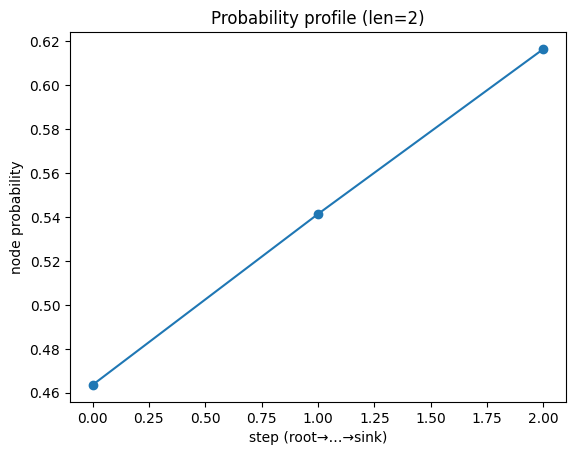


[valid] shard_8f27  |  hops=2  mono=True  sink_p=0.607
30064771090 (0.557)
  uri = getenv("DEVICE_URI") --[DFG]--> 30064771094 (0.565)
  ptr = strstr(uri, ":/") --[DFG]--> 30064771104 (0.607)
  ptr ++


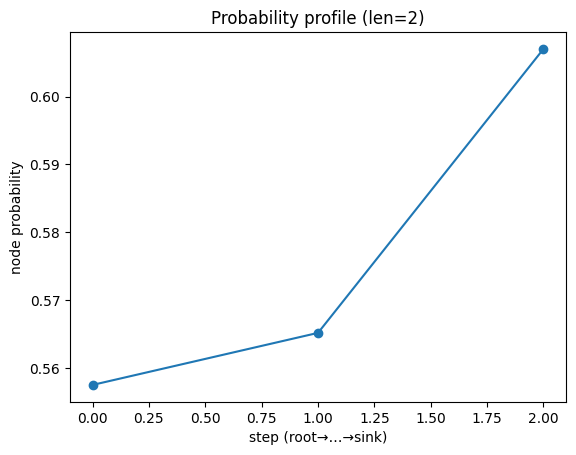


[valid] shard_8067  |  hops=2  mono=True  sink_p=0.562
30064771122 (0.527)
  file = stdin --[DFG]--> 30064771124 (0.500)
  NULL != (aline = my_get_line(file)) --[DFG]--> 68719476785 (0.562)
  aline


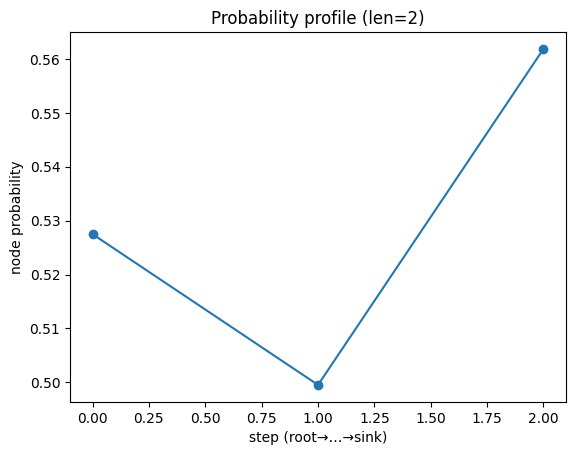


[valid] shard_b238  |  hops=2  mono=True  sink_p=0.552
30064771106 (0.499)
  sockpath = argv[++i] --[DFG]--> 30064771125 (0.508)
  s = connect_unix_socket(sockpath) --[DFG]--> 30064771138 (0.552)
  close(s)


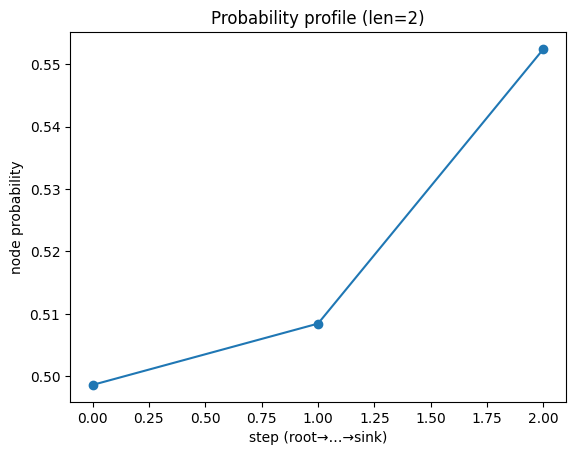


[valid] shard_b238  |  hops=2  mono=True  sink_p=0.536
30064771106 (0.499)
  sockpath = argv[++i] --[DFG]--> 30064771139 (0.524)
  s = connect_unix_socket(sockpath) --[DFG]--> 30064771179 (0.536)
  close(s)


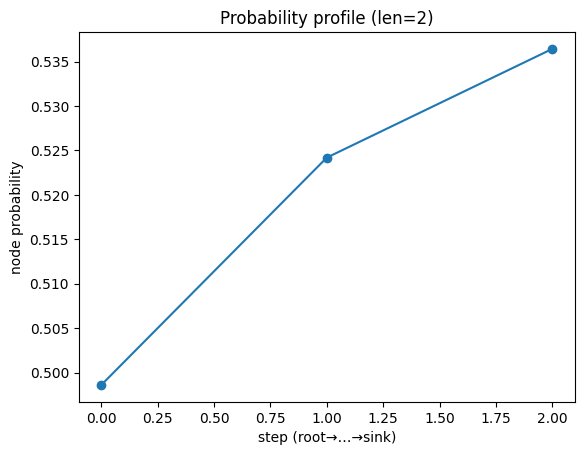


[test] shard_7ebf  |  hops=4  mono=True  sink_p=0.600
30064771733 (0.527)
  rowDelay = 1 + (p->param & 0x0F) --[DFG]--> 30064771750 (0.543)
  nonRowTicks = numTicks - rowDelay --[DFG]--> 30064772208 (0.550)
  tremTicks = ((GetType() & (MOD_TYPE_IT | MOD_TYPE_MPT)) && !m_SongFla… --[DFG]--> 30064772216 (0.524)
  inc = pChn->nTremoloSpeed * tremTicks --[DFG]--> 30064772220 (0.600)
  inc *= 4


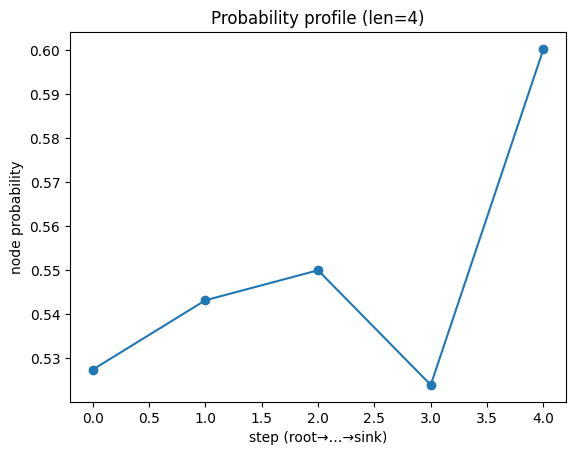


[test] shard_501e  |  hops=3  mono=True  sink_p=0.609
30064771104 (0.591)
  *iocb = req->context --[DFG]--> 30064771106 (0.580)
  *priv = iocb->private --[DFG]--> 30064771108 (0.553)
  *epdata = priv->epdata --[DFG]--> 30064771141 (0.609)
  DBG(epdata->dev, "%s fault %d len %d\n",
				ep->name, req->status, r…


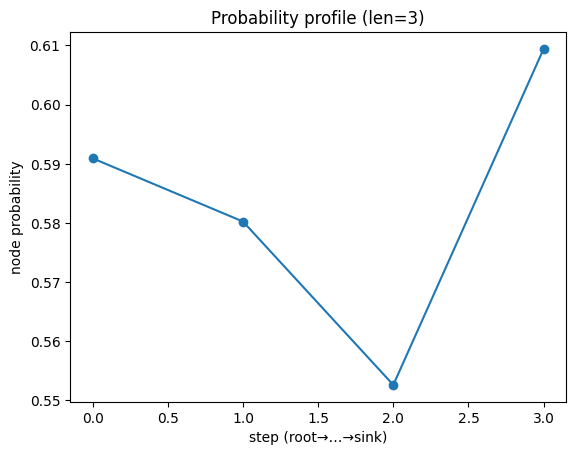


[test] shard_5c45  |  hops=3  mono=True  sink_p=0.601
30064771080 (0.591)
  assoc_rsp = (struct ieee_types_assoc_rsp *) &resp->params --[DFG]--> 30064771087 (0.597)
  status_code = le16_to_cpu(assoc_rsp->status_code) --[DFG]--> 30064771144 (0.557)
  ret = status_code --[DFG]--> 141733920768 (0.601)
  return ret;


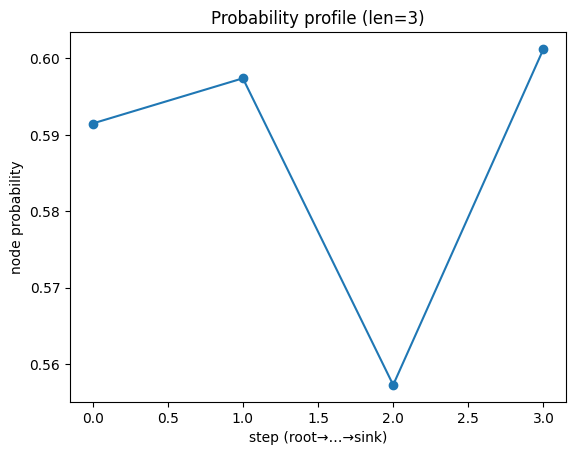


[test] shard_8f8c  |  hops=3  mono=True  sink_p=0.506
30064771077 (0.434)
  speed = dectoul(argv[1], NULL) --[DFG]--> 30064771081 (0.503)
  ret = i2c_set_bus_speed(speed) --[DFG]--> 30064771084 (0.452)
  ret ? CMD_RET_FAILURE : 0 --[CALL]--> 107374182417 (0.506)
  <empty>


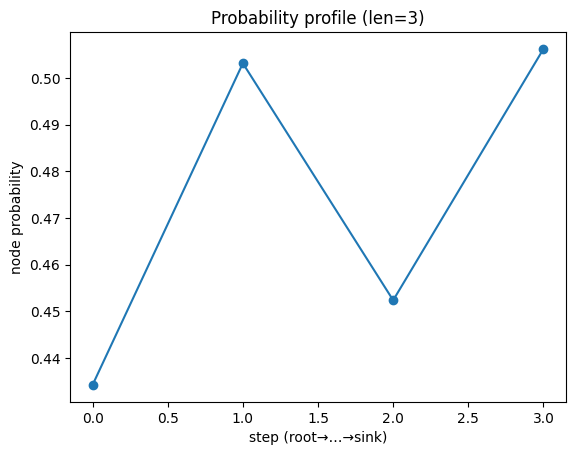


[test] shard_7391  |  hops=3  mono=True  sink_p=0.500
30064771078 (0.434)
  *options = parse_arguments(argc, argv) --[DFG]--> 30064771082 (0.443)
  iplist = fopen(options->in_file, "rb") --[DFG]--> 30064771097 (0.469)
  read_size = fread(plist_entire, sizeof(char), filestats.st_size, ipli… --[DFG]--> 68719476775 (0.500)
  read_size


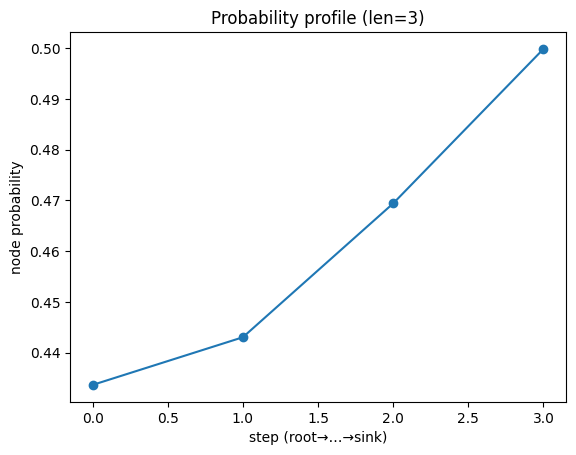


[Done] Printed a few illustrative chains with relations and probability profiles.


In [20]:
# === Root→…→Sink Chain Viewer (samples) ===
# This cell will load the chain JSONL produced by the previous evaluation cell
# and print a few illustrative examples with node names, probabilities, and
# the relation between each hop. It also draws a simple probability profile
# chart per chain.
import os, json, re
from pathlib import Path
from collections import defaultdict

import torch
import matplotlib.pyplot as plt

OUT_DIR = "out/cagat_acc_interproc_train"
GC_DIR_TMPL = "Dataset/{split}/hetero_ready_gcbert"

SPLITS = ["valid", "test"]  # choose which splits to sample from
SAMPLES_PER_SPLIT = 5       # how many chains to print per split
PREF_MIN_LENGTH = 2         # prefer chains of at least this hop length

def safe_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def get_edge_index(g, et):
    if et not in g.edge_types:
        dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
               else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
        return torch.zeros((2,0), dtype=torch.long, device=dev)
    store = g[et]
    ei = getattr(store, "edge_index", None)
    if ei is not None:
        return ei
    adj_t = getattr(store, "adj_t", None)
    if adj_t is not None:
        row, col, _ = adj_t.coo()
        return torch.stack([col, row], dim=0)
    dev = (g["node"].x_text.device if hasattr(g["node"],"x_text")
           else (g["node"].x.device if hasattr(g["node"],"x") else 'cpu'))
    return torch.zeros((2,0), dtype=torch.long, device=dev)

def build_rel_lookup(g):
    fwd = defaultdict(list)
    bwd = defaultdict(list)
    use = ['CALL','ARG2PARAM','RET2CALL','RET2LHS','DFG']
    for r in use:
        et = ('node', r, 'node')
        ei = get_edge_index(g, et)
        if ei.numel()==0: continue
        src, dst = ei
        for u,v in zip(src.tolist(), dst.tolist()):
            fwd[(u,v)].append(r)
            bwd[(v,u)].append(r+"_REV")
    return fwd, bwd

def choose_samples(chain_items, k=SAMPLES_PER_SPLIT, prefer_min_len=2):
    # Score chains: prefer longer, then higher end prob, then any
    scored = []
    for item in chain_items:
        L = item.get("length", 0)
        endp = item.get("score", 0.0)
        scored.append((L >= prefer_min_len, L, endp, item))
    # sort by (has_min_len desc, length desc, endp desc)
    scored.sort(key=lambda x: (x[0], x[1], x[2]), reverse=True)
    return [it[-1] for it in scored[:k]]

def short(s, n=80):
    s = s or ""
    return s if len(s) <= n else s[:n-1]+"…"

def print_chain(split, file_stem, chain, rels):
    print(f"\n[{split}] {file_stem}  |  hops={chain['length']}  mono={chain['mono']}  sink_p={chain['score']:.3f}")
    parts = []
    for i, node in enumerate(chain["chain"]):
        nid = node["id"]
        name = short(node.get("name",""), 70)
        p = node.get("p", 0.0)
        parts.append(f"{nid} ({p:.3f})\n  {name}")
        if i < len(chain["chain"]) - 1:
            rel = rels[i] if i < len(rels) else "?"
            parts.append(f" --[{rel}]--> ")
    print("".join(parts))

def relation_seq_for_path(g, pos_path):
    fwd, bwd = build_rel_lookup(g)
    rels = []
    for a, b in zip(pos_path, pos_path[1:]):
        r = fwd.get((a,b), [])
        if r:
            rels.append(r[0])
        else:
            r = bwd.get((a,b), [])
            rels.append(r[0] if r else "?")
    return rels

def plot_chain_probs(chain):
    probs = [n["p"] for n in chain["chain"]]
    xs = list(range(len(probs)))
    plt.figure()
    plt.plot(xs, probs, marker='o')
    plt.title(f'Probability profile (len={chain["length"]})')
    plt.xlabel("step (root→…→sink)")
    plt.ylabel("node probability")
    plt.show()

# ----------------- Load & display samples -----------------
for split in SPLITS:
    chains_path = Path(OUT_DIR) / f"chains_{split}.jsonl"
    if not chains_path.exists():
        print(f"[WARN] Missing {chains_path}, skipping {split}")
        continue

    gc_dir = Path(GC_DIR_TMPL.format(split=split))
    graphs = {p.stem: p for p in gc_dir.glob("*.pt")}

    # read all entries for this split
    items = []
    with open(chains_path, "r", encoding="utf-8") as fh:
        for line in fh:
            try:
                o = json.loads(line)
                file_stem = o.get("file")
                for ch in o.get("chains", []):
                    items.append((file_stem, ch))
            except Exception:
                continue

    if not items:
        print(f"[INFO] No chains listed in {chains_path}")
        continue

    # pick samples
    samples = choose_samples(
        [{"file": f, **ch} for (f, ch) in items],
        k=SAMPLES_PER_SPLIT,
        prefer_min_len=PREF_MIN_LENGTH
    )

    # show
    for ch in samples:
        file_stem = ch["file"]
        pt_path = graphs.get(file_stem)
        if not pt_path:
            print(f"[MISS] Graph PT not found for {file_stem}")
            continue

        g = safe_load(pt_path, map_location="cpu")
        st = g["node"]
        # map reported node ids -> graph positions (the JSONL stores *graph* ids, not positions)
        if hasattr(st, "nid"):
            ids = st.nid.view(-1).tolist()
            id2pos = {int(n): i for i,n in enumerate(ids)}
            pos_path = [id2pos.get(int(n["id"]), None) for n in ch["chain"]]
            if any(p is None for p in pos_path):
                print(f"[WARN] Could not map nodes for {file_stem}; skipping relations")
                rels = ["?"]*(len(ch["chain"])-1)
            else:
                rels = relation_seq_for_path(g, pos_path)
        else:
            # if no explicit nid, assume ids==positions
            rels = relation_seq_for_path(g, [int(n["id"]) for n in ch["chain"]])

        print_chain(split, file_stem, ch, rels)
        plot_chain_probs(ch)

print("\n[Done] Printed a few illustrative chains with relations and probability profiles.")


In [8]:
# === Inspect & Compare HeteroData schemas (hetero_ready vs hetero_ready_gcbert) ===
import os, sys, json, math, re
from pathlib import Path

import torch

try:
    from torch_geometric.data import HeteroData
except Exception as e:
    raise RuntimeError(
        "torch-geometric is required to inspect .pt hetero graphs.\n"
        "pip install torch-geometric -f https://data.pyg.org/whl/torch-{torch.__version__}.html"
    ) from e

# --------------------------- config (edit if needed) ---------------------------
DIR_HETERO_READY         = "Dataset/train/hetero_ready"
DIR_HETERO_READY_GCBERT  = "Dataset/train/hetero_ready_gcbert"
# Optionally, you can pin files explicitly:
FILE_HETERO_READY        = None  # e.g., "Dataset/train/hetero_ready/shard_1234.pt"
FILE_HETERO_READY_GCBERT = None  # e.g., "Dataset/train/hetero_ready_gcbert/shard_1234.pt"

# --------------------------- helpers ---------------------------
def find_first_pt(dir_path: str):
    p = Path(dir_path)
    if not p.exists():
        return None
    cands = sorted(p.glob("*.pt"))
    return str(cands[0]) if cands else None

def safe_load_pt(path: str):
    # tolerate torch.load API changes
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

def edge_count(g: HeteroData, et):
    store = g[et]
    if hasattr(store, "edge_index") and store.edge_index is not None:
        return int(store.edge_index.size(1))
    if hasattr(store, "adj_t") and store.adj_t is not None:
        return int(store.adj_t.nnz())
    return 0

def size_str(t: torch.Tensor | None):
    if t is None: return "-"
    return f"{tuple(t.shape)} {str(t.dtype).replace('torch.', '')}"

def mem_estimate_bytes(t: torch.Tensor | None):
    if t is None: return 0
    try:
        return t.element_size() * t.numel()
    except Exception:
        return 0

def human_bytes(n):
    if n < 1024: return f"{n}B"
    for unit in ["KB","MB","GB","TB"]:
        n /= 1024
        if n < 1024: return f"{n:.2f}{unit}"
    return f"{n:.2f}PB"

def summarize_graph(g: HeteroData, name="graph"):
    report = {}
    node_stores = list(g.node_types)
    edge_stores = list(g.edge_types)
    report["name"] = name
    report["node_types"] = node_stores
    report["edge_types"] = [f"{s}:{r}:{t}" for (s,r,t) in edge_stores]

    # assume primary node type "node" (as in your training)
    nt = "node" if "node" in node_stores else node_stores[0]
    ns = g[nt]
    feat_names = []
    in_dim_total = 0
    mem_total = 0

    for f in ["x_text", "x"]:
        if hasattr(ns, f):
            t = getattr(ns, f)
            feat_names.append(f"{f}={size_str(t)}")
            in_dim_total += int(t.size(1))
            mem_total += mem_estimate_bytes(t)

    # other fields often present
    extras = []
    for f in ["nid", "y", "label", "pos", "mask", "train_mask", "val_mask", "test_mask"]:
        if hasattr(ns, f):
            t = getattr(ns, f)
            shape = tuple(t.shape) if torch.is_tensor(t) else "-"
            extras.append(f"{f}={shape}")

    # counts
    N = getattr(ns, "num_nodes", None) or (ns.x.size(0) if hasattr(ns, "x") else (ns.x_text.size(0) if hasattr(ns,"x_text") else None))

    # inter-procedural stats
    inter_rels = ["CALL","ARG2PARAM","RET2CALL","RET2LHS",
                  "CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]
    inter_counts = {}
    total_edges = 0
    for et in g.edge_types:
        c = edge_count(g, et)
        total_edges += c
        if et[1] in inter_rels:
            inter_counts[et[1]] = inter_counts.get(et[1], 0) + c

    report["nodes"] = {
        "store": nt,
        "num_nodes": int(N) if N is not None else None,
        "features": feat_names or ["(none)"],
        "in_dim_total": in_dim_total,
        "extras": extras or ["(none)"],
        "feature_mem": human_bytes(mem_total),
    }
    # edges
    edge_rows = []
    for (s,r,t) in g.edge_types:
        c = edge_count(g, (s,r,t))
        edge_rows.append({"src":s,"rel":r,"dst":t,"count":c})
    report["edges"] = edge_rows
    report["edge_total"] = total_edges
    report["inter_proc_counts"] = inter_counts
    return report

def print_report(rep):
    print(f"\n=== {rep['name']} ===")
    print(f"Node types: {rep['node_types']}")
    print(f"Edge types: {', '.join(rep['edge_types'])}")
    n = rep["nodes"]
    print(f"Nodes: store={n['store']}, num={n['num_nodes']}, in_dim_total={n['in_dim_total']}, feature_mem≈{n['feature_mem']}")
    print(f"  features: {', '.join(n['features'])}")
    print(f"  extras:   {', '.join(n['extras'])}")
    print("Edges:")
    for e in rep["edges"][:20]:
        print(f"  ({e['src']} -{e['rel']}→ {e['dst']}): {e['count']}")
    if len(rep["edges"])>20:
        print(f"  … and {len(rep['edges'])-20} more edge types")
    if rep["inter_proc_counts"]:
        print("Inter-procedural counts:", rep["inter_proc_counts"])
    print(f"Total edges: {rep['edge_total']}")

def quick_compare(rep_base, rep_gcbert):
    print("\n=== Quick comparison (hetero_ready  vs  hetero_ready_gcbert) ===")
    nb = rep_base["nodes"]; ng = rep_gcbert["nodes"]

    # feature presence
    def feat_has(rep, key):
        return any(f.startswith(f"{key}=") for f in rep["nodes"]["features"])

    has_x_b = feat_has(rep_base, "x")
    has_xt_b= feat_has(rep_base, "x_text")
    has_x_g = feat_has(rep_gcbert, "x")
    has_xt_g= feat_has(rep_gcbert, "x_text")

    # node counts
    n_b = nb["num_nodes"]; n_g = ng["num_nodes"]
    # dims
    din_b = nb["in_dim_total"]; din_g = ng["in_dim_total"]

    print(f"- Nodes:  {n_b} (base)  vs  {n_g} (gcbert)  -> {'same' if n_b==n_g else 'DIFF'}")
    print(f"- In-dim: {din_b} (base) vs  {din_g} (gcbert) -> {'↑ enriched' if din_g>din_b else ('same' if din_g==din_b else '↓ fewer')}")
    print(f"- Features present:")
    print(f"    base:    x={'yes' if has_x_b else 'no'}, x_text={'yes' if has_xt_b else 'no'}")
    print(f"    gcbert:  x={'yes' if has_x_g else 'no'}, x_text={'yes' if has_xt_g else 'no'}")

    # edge set compare (by relation name)
    edges_b = {(e["src"], e["rel"], e["dst"]) for e in rep_base["edges"]}
    edges_g = {(e["src"], e["rel"], e["dst"]) for e in rep_gcbert["edges"]}
    rels_b = {r for _,r,_ in edges_b}
    rels_g = {r for _,r,_ in edges_g}
    only_in_b = sorted(list(rels_b - rels_g))
    only_in_g = sorted(list(rels_g - rels_b))
    print(f"- Relation families:\n    base-only: {only_in_b or '(none)'}\n    gcbert-only: {only_in_g or '(none)'}")

    # inter-procedural totals
    ib = sum(rep_base["inter_proc_counts"].values()) if rep_base["inter_proc_counts"] else 0
    ig = sum(rep_gcbert["inter_proc_counts"].values()) if rep_gcbert["inter_proc_counts"] else 0
    print(f"- Inter-procedural edges total (CALL/ARG2PARAM/RET2*): base={ib}  vs  gcbert={ig} "
          f"{'(same)' if ib==ig else ('↑' if ig>ib else '↓')}")

    # memory
    print(f"- Feature memory: base≈{nb['feature_mem']}  vs  gcbert≈{ng['feature_mem']}")

    # verdict
    verdict = []
    if has_xt_g and (din_g > din_b):
        verdict.append("GraphCodeBERT embeddings (x_text) increase node feature dimensionality.")
    if ib==ig:
        verdict.append("Inter-procedural topology appears unchanged (same CALL/ARG2PARAM/RET2* counts).")
    else:
        verdict.append("Inter-procedural edge counts differ—check extractor settings or shard pairing.")
    if n_b != n_g:
        verdict.append("Node counts differ—files are likely not the same shard; compare like-for-like to isolate feature deltas.")
    print("\nSummary:")
    for v in verdict:
        print("  •", v)

# --------------------------- locate files ---------------------------
if FILE_HETERO_READY is None:
    FILE_HETERO_READY = find_first_pt(DIR_HETERO_READY)
if FILE_HETERO_READY_GCBERT is None:
    FILE_HETERO_READY_GCBERT = find_first_pt(DIR_HETERO_READY_GCBERT)

assert FILE_HETERO_READY, f"No .pt found under {DIR_HETERO_READY}"
assert FILE_HETERO_READY_GCBERT, f"No .pt found under {DIR_HETERO_READY_GCBERT}"

print("[BASE]    ", FILE_HETERO_READY)
print("[GCBERT]  ", FILE_HETERO_READY_GCBERT)

# --------------------------- load & summarize ---------------------------
g_base   = safe_load_pt(FILE_HETERO_READY)
g_gcbert = safe_load_pt(FILE_HETERO_READY_GCBERT)
if not isinstance(g_base, HeteroData) or not isinstance(g_gcbert, HeteroData):
    raise RuntimeError("Loaded objects are not torch_geometric.data.HeteroData graphs. Check your inputs.")

rep_base   = summarize_graph(g_base,   name="hetero_ready")
rep_gcbert = summarize_graph(g_gcbert, name="hetero_ready_gcbert")

print_report(rep_base)
print_report(rep_gcbert)
quick_compare(rep_base, rep_gcbert)


[BASE]     Dataset\train\hetero_ready\shard_0003.pt
[GCBERT]   Dataset\train\hetero_ready_gcbert\shard_0003.pt

=== hetero_ready ===
Node types: ['node']
Edge types: node:AST:node, node:CFG:node, node:DFG:node, node:CALL:node, node:ARG2PARAM:node, node:RET2CALL:node, node:RET2LHS:node, node:AST_REV:node, node:CFG_REV:node, node:DFG_REV:node, node:CALL_REV:node, node:ARG2PARAM_REV:node, node:RET2CALL_REV:node, node:RET2LHS_REV:node
Nodes: store=node, num=3141, in_dim_total=25, feature_mem≈306.74KB
  features: x=(3141, 25) float32
  extras:   (none)
Edges:
  (node -AST→ node): 2470
  (node -CFG→ node): 1457
  (node -DFG→ node): 697
  (node -CALL→ node): 608
  (node -ARG2PARAM→ node): 1097
  (node -RET2CALL→ node): 608
  (node -RET2LHS→ node): 96
  (node -AST_REV→ node): 2470
  (node -CFG_REV→ node): 1457
  (node -DFG_REV→ node): 697
  (node -CALL_REV→ node): 608
  (node -ARG2PARAM_REV→ node): 1097
  (node -RET2CALL_REV→ node): 608
  (node -RET2LHS_REV→ node): 96
Inter-procedural counts: 

# === Demo: long-hop vulnerable code → unified_json → gcbert graph → score with best_model → longest root→…→sink chain ===
# Outputs: JSON/TXT/PNG + the synthetic unified_json + matching hetero_ready_gcbert .pt under out/demo_case/<timestamp>/

In [ ]:

import os, re, json, time, textwrap, random
from pathlib import Path
from collections import defaultdict, deque
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required in this environment (pip install torch_geometric).") from e

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_DIR = Path("out/demo_case") / str(int(time.time()))
RUN_DIR.mkdir(parents=True, exist_ok=True)


SRC_FILES = {
    # file 1: reads user input (ROOT) → passes through wrappers → ended up in exec-like sink
    "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* wrap_a(char* in);
extern char* wrap_b(char* in);
extern char* wrap_c(char* in);
extern void run_system(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    // ROOT: untrusted input (simulate reading from argv)
    if (argc > 1) {
        strncpy(buf, argv[1], sizeof(buf)-1);
        buf[sizeof(buf)-1] = '\0';
        char* p = wrap_a(buf);
        p = wrap_b(p);
        p = wrap_c(p);
        // final call: dangerous sink
        run_system(p);
    }
    return 0;
}
""",

    # file 2: wrappers that "transform" the input without real sanitization
    "lib/wrap.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char tmp1[300];
char tmp2[300];
char tmp3[300];

char* wrap_a(char* in) {
    // propagation #1 (DFG + CALL/ARG2PARAM)
    snprintf(tmp1, sizeof(tmp1), "%s", in);
    return tmp1;
}

char* wrap_b(char* in) {
    // propagation #2
    strcat(tmp2, in);
    strcat(tmp2, " --verbose");
    return tmp2;
}

char* wrap_c(char* in) {
    // propagation #3
    sprintf(tmp3, "%s %s", in, "--force");
    return tmp3;
}
""",

    # file 3: sink wrapper that ultimately calls system()
    "lib/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void run_system(char* cmd) {
    // SINK: vulnerable external command execution
    // (intentionally no sanitization)
    system(cmd);
}
""",
}



GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False  # set True to enforce that x_text must be encoded by GraphCodeBERT (error if missing)

# Chain search knobs (same style as training/eval)
MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.0
SINK_PROB_THR = 0.55
TOPK_SINKS_PER_GRAPH = 30
WRAP_COLS = 110
MAX_CODE_LINES = 12


def split_statements(code: str) -> List[str]:
    out=[]
    for raw in code.splitlines():
        line = raw.strip()
        if not line: 
            out.append("")
            continue
        out.append(line)
    return out

def detect_calls(stmt: str):
    # crude call detection, returns function name if looks like foo(...)
    m = re.match(r'([A-Za-z_]\w*)\s*\(', stmt)
    return m.group(1) if m else None

def find_lhs_var(stmt: str):
    # naive assignment / decl parse: char buf[256]; x = y;  int a = foo();
    m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*(?:=|;)', stmt)
    if m: return m.group(1)
    m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
    if m: return m.group(1)
    return None

def find_vars(stmt: str):
    # super-naive token scan for variable-like identifiers (skip keywords)
    toks = re.findall(r'[A-Za-z_]\w*', stmt)
    keywords = set("int char float double return if else for while extern void include define sizeof".split())
    return [t for t in toks if t not in keywords]

def label_if_root_sink(stmt: str):
    # label ROOT if argv/strncpy from argv; label SINK if system(...) appears
    s = stmt.lower()
    if "argv" in s or "stdin" in s or "getenv" in s:
        return "ROOT"
    if re.search(r'\bsystem\s*\(', s):
        return "SINK"
    return None

def build_unified_from_sources(sources: Dict[str,str]) -> dict:
    nodes=[]; edges=[]; nid=0
    # per-file pass: create nodes per statement with (file, line, code)
    perfile_nodes = {}
    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        for i, st in enumerate(stmts, start=1):
            if not st.strip(): 
                continue
            lbl = label_if_root_sink(st)
            n = {
                "_id": nid,
                "file": file,
                "line": i,
                "code": st,
                "nodeType": "Stmt",
            }
            if lbl: n["_label"] = lbl
            this.append(n); nodes.append(n); nid += 1
        perfile_nodes[file] = this

        # CFG edges (sequential)
        for i in range(len(this)-1):
            edges.append({"type":"CFG", "src": this[i]["_id"], "dst": this[i+1]["_id"]})

    # very light DFG: from defs to uses
    name2def_ids = defaultdict(list)
    for n in nodes:
        lhs = find_lhs_var(n["code"])
        if lhs: name2def_ids[lhs].append(n["_id"])

    for n in nodes:
        uses = find_vars(n["code"])
        for v in uses:
            if name2def_ids.get(v):
                # link the most recent def before this node within same file (approx)
                defs = name2def_ids[v]
                edges.append({"type":"DFG", "src": defs[-1], "dst": n["_id"]})

    # CALL / ARG2PARAM / RET2CALL / RET2LHS
    # we approximate functions from 'wrap_a', 'wrap_b', 'wrap_c', 'run_system'
    func_defs = defaultdict(list)  # name -> list of node ids that "define/return" it (approx head/return)
    for n in nodes:
        if re.match(r'(?:char\*|void)\s+(wrap_a|wrap_b|wrap_c|run_system)\s*\(', n["code"]):
            func = re.findall(r'(wrap_a|wrap_b|wrap_c|run_system)', n["code"])[0]
            func_defs[func].append(n["_id"])

    for n in nodes:
        cname = detect_calls(n["code"])
        if cname and (cname in func_defs or cname in ["snprintf","strcat","sprintf","system"]):
            # model cares about call edges; include to "callee head" if we saw a def, else to same node
            callee = func_defs.get(cname, [n["_id"]])[0]
            edges.append({"type":"CALL", "src": n["_id"], "dst": callee})
            # rudimentary ARG2PARAM: from arg tokens to callee
            arg_vars = re.findall(r'\((.*)\)', n["code"])
            if arg_vars:
                for v in re.findall(r'[A-Za-z_]\w*', arg_vars[0]):
                    if name2def_ids.get(v):
                        edges.append({"type":"ARG2PARAM", "src": name2def_ids[v][-1], "dst": callee})

            # SINK heuristic: system(cmd) → mark callee as sink node in nodes (already via label_if_root_sink)
            if cname == "system":
                # already labeled as SINK if the statement contains system(
                pass

            # RET edges: if assign = wrap_x(...), send callee->call and ret->lhs (approx with the same n)
            if '=' in n["code"]:
                lhs = find_lhs_var(n["code"])
                if lhs:
                    edges.append({"type":"RET2LHS", "src": callee, "dst": n["_id"]})
                else:
                    edges.append({"type":"RET2CALL", "src": callee, "dst": n["_id"]})

    # add reverse edges
    rev = {"AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS"}
    for r in rev:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    return {"nodes": nodes, "edges": edges}

unified = build_unified_from_sources(SRC_FILES)
with open(RUN_DIR / "demo_unified.json", "w", encoding="utf-8") as f:
    json.dump(unified, f, indent=2)
print(f"[WRITE] unified_json: {RUN_DIR/'demo_unified.json'}  nodes={len(unified['nodes'])} edges={len(unified['edges'])}")

# ---------------------------------------------------------------------------------------
# 3) Build hetero_ready_gcbert HeteroData (x:25 + x_text:768 from GraphCodeBERT)
# ---------------------------------------------------------------------------------------
def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    # 25-dim light numeric features
    #   [0]=is_call, [1]=has_assign, [2]=mentions_argv, [3]=is_sink, [4]=is_return, [5]=has_str_op, ...
    x = torch.zeros((N, 25), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0]=1
        if '=' in s: x[i,1]=1
        if 'argv' in s: x[i,2]=1
        if 'system(' in s: x[i,3]=1
        if re.match(r'\breturn\b', s): x[i,4]=1
        if any(k in s for k in ["snprintf","sprintf","strcat"]): x[i,5]=1

    # GraphCodeBERT embeddings
    use_gcbert = True
    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length", max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
    except Exception as e:
        if REQUIRE_GCBERT:
            raise RuntimeError(
                f"GraphCodeBERT not available. Set GCBERT_PATH to a local checkpoint dir, "
                f"or install transformers and ensure model is cached. Error: {e}"
            )
        print(f"[WARN] GraphCodeBERT unavailable; using zeros for x_text. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.tensor([int(n["_id"]) for n in nodes], dtype=torch.long)

    # edges
    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

g = build_gcbert_graph(unified)
torch.save(g, RUN_DIR / "demo_gcbert.pt")
print(f"[WRITE] hetero_ready_gcbert .pt: {RUN_DIR/'demo_gcbert.pt'}")
print(f"  Nodes={g['node'].num_nodes} in_dim={(g['node'].x.size(1) + g['node'].x_text.size(1))} edge_types={len(g.edge_types)}")

# ---------------------------------------------------------------------------------------
# 4) Load your trained model (best_model.pt or ckpt_cagat_acc_interproc.pt)
# ---------------------------------------------------------------------------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.hidden = hidden
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([_Block(hidden, hidden, heads, edge_types, dropout=dropout) for _ in range(layers)])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)

def load_trained_model_for_graph(g: HeteroData):
    ckpts = [Path("out/cagat_acc_interproc_train/best_model.pt"),
             Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt")]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[WARN] No trained checkpoint found; continuing with heuristic sink scoring.")
        return None
    in_dim, et = infer_in_dim_etypes(g)
    hidden, heads, layers, dropout = 128, 4, 6, 0.10  # match your run
    model = CAGAT_ACC_InterProc(in_dim, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()
    state = torch.load(str(ckpt), map_location="cpu")
    state = state.get("model", state)
    miss, unexp = model.load_state_dict(state, strict=False)
    if hasattr(miss, "__len__"):
        print(f"[LOAD] hidden={hidden} heads={heads} layers={layers} missing={len(miss)} unexpected={len(unexp)}")
    return model

model = load_trained_model_for_graph(g)

with torch.no_grad():
    logits = None
    if model is not None:
        lg, _ = model(g.to(DEVICE))
        logits = lg.detach().cpu()

# ---------------------------------------------------------------------------------------
# 5) Chain miner (beam search) over DFG/CFG/AST/CPG, guided by logits if available
# ---------------------------------------------------------------------------------------
ALLOWED = {"DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
           "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"}
REL2FAM = {
    "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
    "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if et in g.edge_types else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r); 
        if ei is None: continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def choose_sinks(logits, g):
    N = g["node"].num_nodes
    if logits is None:
        score = torch.zeros(N)
        for r in ["DFG","RET2CALL","RET2LHS","CFG"]:
            ei = get_ei(g, r)
            if ei is not None:
                score.index_add_(0, ei[1].cpu(), torch.ones(ei.size(1)))
        k = min(TOPK_SINKS_PER_GRAPH, N)
        return torch.topk(score, k=k, largest=True).indices.tolist()
    prob = torch.sigmoid(logits)
    mask = prob >= SINK_PROB_THR
    k = int(mask.sum().item()) or min(TOPK_SINKS_PER_GRAPH, N)
    return torch.topk(prob, k=k).indices.tolist()

def candidate_roots(g):
    N = g["node"].num_nodes
    roots=set()
    ei = get_ei(g, "ARG2PARAM")
    if ei is not None: roots.update(ei[0].tolist())
    dfg_rev = get_ei(g, "DFG_REV")
    incoming = set(dfg_rev[0].tolist()) if dfg_rev is not None else set()
    for i in range(N):
        if i not in incoming: roots.add(i)
    return list(roots)[:2048]

def relation_between(g,u,v):
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(REL2FAM[r])
    return exact, sorted(fams)

def beam_search(g, logits):
    adj = build_adj(g)
    sinks = choose_sinks(logits, g)
    roots = candidate_roots(g)
    best=[]; t0=time.monotonic()

    for s in sinks:
        if (time.monotonic()-t0) > TIME_BUDGET_S: break
        beam = [[r] for r in roots]
        for _ in range(MAX_HOPS):
            if not beam: break
            new=[]
            for path in beam:
                u = path[-1]
                for v, r in adj.get(u, []):
                    if v in path: continue
                    np = path + [v]
                    if v == s:
                        best.append(np)
                        if len(best)>=16: break
                    else:
                        new.append(np)
                if len(best)>=16: break
            if len(best)>=16: break
            new.sort(key=lambda p: (len(p), -len(adj.get(p[-1],[]))))
            seen=set(); pr=[]
            for p in new:
                end=p[-1]
                if end in seen: continue
                seen.add(end); pr.append(p)
                if len(pr)>=BEAM_WIDTH: break
            beam=pr

    best.sort(key=lambda p: len(p), reverse=True)
    return best[0] if best else None

chain_ix = beam_search(g, logits)
if chain_ix is None:
    raise RuntimeError("No chain found — try lowering SINK_PROB_THR or increasing TIME_BUDGET_S/BEAM_WIDTH.")

# ---------------------------------------------------------------------------------------
# 6) Present chain with exact code + file + line + label; save JSON, TXT, PNG
# ---------------------------------------------------------------------------------------
nodes = { int(n["_id"]): n for n in unified["nodes"] }
def nid2rec(ix):
    # we stored nid==_id in order
    nid = int(g["node"].nid[ix].item()) if hasattr(g["node"], "nid") else int(ix)
    return nid, nodes.get(nid, {})

def wrap(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

annot_nodes=[]
for k, ix in enumerate(chain_ix):
    nid, rec = nid2rec(ix)
    code = rec.get("code","").strip()
    file = rec.get("file"); line = rec.get("line"); lab = rec.get("_label") or rec.get("nodeType")
    annot_nodes.append({"index":k, "file":file, "line":line, "label":lab, "code":code})

annot_edges=[]
for i in range(len(chain_ix)-1):
    u, v = chain_ix[i], chain_ix[i+1]
    ex, fam = relation_between(g, u, v)
    annot_edges.append({"from_index":i, "to_index":i+1, "families":fam, "exact":ex})

# print horizontal chain
print("\n" + "="*WRAP_COLS)
print(f"Root  →  …  →  Sink    hops={len(chain_ix)-1}")
print("="*WRAP_COLS)
for i, nd in enumerate(annot_nodes):
    role = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else "→")
    meta=[]
    if nd["label"]: meta.append(str(nd["label"]))
    if nd["file"]:  meta.append(str(nd["file"]))
    if nd["line"]:  meta.append(f"line {nd['line']}")
    ms = ("  (" + ", ".join(meta) + ")") if meta else ""
    print(f"[{role}] {wrap(nd['code'])}{ms}")
    if i < len(annot_edges):
        e = annot_edges[i]
        fam = "/".join(e["families"]) if e["families"] else "-"
        ex  = ",".join(e["exact"]) if e["exact"] else "-"
        print(f"   └──[{fam}] exact={ex}")

# save artifacts
artifact = {
    "hops": len(chain_ix)-1,
    "nodes": annot_nodes,
    "edges": annot_edges,
    "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S,
                   SINK_PROB_THR=SINK_PROB_THR, TOPK_SINKS_PER_GRAPH=TOPK_SINKS_PER_GRAPH)
}
with open(RUN_DIR / "chain.json", "w", encoding="utf-8") as f:
    json.dump(artifact, f, indent=2)
with open(RUN_DIR / "chain.txt", "w", encoding="utf-8") as f:
    f.write(f"Root → … → Sink (hops={len(chain_ix)-1})\n\n")
    for i, nd in enumerate(annot_nodes):
        role = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else "→")
        meta=[]
        if nd["label"]: meta.append(str(nd["label"]))
        if nd["file"]:  meta.append(str(nd["file"]))
        if nd["line"]:  meta.append(f"line {nd['line']}")
        ms = ("  (" + ", ".join(meta) + ")") if meta else ""
        f.write(f"[{role}] {nd['code']}\n{ms}\n")
        if i < len(annot_edges):
            e = annot_edges[i]
            fam = "/".join(e["families"]) if e["families"] else "-"
            ex  = ",".join(e["exact"]) if e["exact"] else "-"
            f.write(f"   └──[{fam}] exact={ex}\n")

# PNG graph
try:
    import networkx as nx, matplotlib.pyplot as plt
    G = nx.DiGraph()
    labels={}
    for i, nd in enumerate(annot_nodes):
        tag = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else f"{i}")
        head = nd["code"].splitlines()[0][:68]
        labels[i] = f"{tag}: {head}"
        G.add_node(i)
    for e in annot_edges:
        fam = "/".join(e["families"]) if e["families"] else "-"
        G.add_edge(e["from_index"], e["to_index"], label=fam)
    pos = nx.spring_layout(G, seed=0)
    plt.figure(figsize=(max(6, len(annot_nodes)*1.2), 4))
    nx.draw(G, pos, with_labels=False, node_color="#e6f0ff", node_size=1400, arrows=True)
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'label'), font_size=8)
    plt.axis('off'); plt.tight_layout()
    plt.savefig(RUN_DIR / "chain.png", dpi=150); plt.close()
except Exception as e:
    print(f"[WARN] PNG rendering skipped: {e}")

# save inputs for reproducibility
with open(RUN_DIR / "source_files.json", "w", encoding="utf-8") as f:
    json.dump(SRC_FILES, f, indent=2)
print(f"\n[WRITE] artifacts in {RUN_DIR}")
print("       - demo_unified.json  (graph JSON)")
print("       - demo_gcbert.pt     (HeteroData with x & x_text)")
print("       - chain.json / chain.txt / chain.png  (human-readable result)")


[WRITE] unified_json: out\demo_case\1759993677\demo_unified.json  nodes=51 edges=166
[WARN] GraphCodeBERT unavailable; using zeros for x_text. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
[WRITE] hetero_ready_gcbert .pt: out\demo_case\1759993677\demo_gcbert.pt
  Nodes=51 in_dim=793 edge_types=8
[LOAD] hidden=128 heads=4 layers=6 missing=2 unexpected=188


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_31784\3210130126.py:376: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(ckpt), map_location="cpu")



Root  →  …  →  Sink    hops=8
[ROOT] if (argc > 1) {  (Stmt, app/main.c, line 14)
   └──[CFG] exact=CFG
[→] strncpy(buf, argv[1], sizeof(buf)-1);  (ROOT, app/main.c, line 15)
   └──[DFG] exact=DFG_REV
[→] char buf[256];  (Stmt, app/main.c, line 12)
   └──[DFG] exact=DFG
[→] buf[sizeof(buf)-1] = '\0';  (Stmt, app/main.c, line 16)
   └──[CFG] exact=CFG
[→] char* p = wrap_a(buf);  (Stmt, app/main.c, line 17)
   └──[DFG] exact=DFG_REV
[→] p = wrap_c(p);  (Stmt, app/main.c, line 19)
   └──[CPG] exact=ARG2PARAM
[→] void run_system(char* cmd) {  (Stmt, lib/sink.c, line 6)
   └──[CPG] exact=CALL_REV
[→] run_system(p);  (Stmt, app/main.c, line 21)
   └──[CFG] exact=CFG_REV
[SINK] // final call: dangerous sink  (Stmt, app/main.c, line 20)

[WRITE] artifacts in out\demo_case\1759993677
       - demo_unified.json  (graph JSON)
       - demo_gcbert.pt     (HeteroData with x & x_text)
       - chain.json / chain.txt / chain.png  (human-readable result)


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_31784\3210130126.py:585: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis('off'); plt.tight_layout()


#

In [ ]:
import os, re, json, time, textwrap, random, csv
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required (pip install torch_geometric).") from e

# ------------------ KNOBS ------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_DIR = Path("out/demo_case") / str(int(time.time()))
RUN_DIR.mkdir(parents=True, exist_ok=True)

DEMO_ID = 2 # << set to 2 for the alternate stdin-based demo
GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False  # set True to hard-fail if GraphCodeBERT isn't available

# Chain search knobs
MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.5
SINK_PROB_THR = 0.55
TOPK_SINKS_PER_GRAPH = 30

# Printing / wrapping
WRAP_COLS = 110
MAX_CODE_LINES = 12

# Sinks/sources
SINK_FUNCS = {"system","popen","execl","execlp","execle","execv","execvp","execvpe","posix_spawn","posix_spawnp"}
SRC_FUNCS  = {"argv","stdin","getenv","fgets","read","recv"}

# ------------------ DEMO SOURCES ------------------
SRC_FILES_1 = {
    "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* wrap_a(char* in);
extern char* wrap_b(char* in);
extern char* wrap_c(char* in);
extern void run_system(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    // ROOT: untrusted input (simulate reading from argv)
    if (argc > 1) {
        strncpy(buf, argv[1], sizeof(buf)-1);
        buf[sizeof(buf)-1] = '\0';
        char* p = wrap_a(buf);
        p = wrap_b(p);
        p = wrap_c(p);
        // final call: dangerous sink
        run_system(p);
    }
    return 0;
}
""",
    "lib/wrap.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char tmp1[300];
char tmp2[300];
char tmp3[300];

char* wrap_a(char* in) {
    // propagation #1 (DFG + CALL/ARG2PARAM)
    snprintf(tmp1, sizeof(tmp1), "%s", in);
    return tmp1;
}

char* wrap_b(char* in) {
    // propagation #2
    strcat(tmp2, in);
    strcat(tmp2, " --verbose");
    return tmp2;
}

char* wrap_c(char* in) {
    // propagation #3
    sprintf(tmp3, "%s %s", in, "--force");
    return tmp3;
}
""",
    "lib/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void run_system(char* cmd) {
    // SINK: vulnerable external command execution
    // (intentionally no sanitization)
    system(cmd);
}
""",
}

SRC_FILES_2 = {
    "demo2/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* stage1_normalize(const char* in);
extern char* stage2_expand(char* in);
extern char* stage3_flag(char* in);
extern void  do_exec(char* cmd);

int main(void) {
    char in[256];
    char* p = NULL;

    // ROOT: untrusted stdin
    if (fgets(in, sizeof(in), stdin)) {
        p = stage1_normalize(in);
        p = stage2_expand(p);
        p = stage3_flag(p);
        do_exec(p);   // sink wrapper
    }
    return 0;
}
""",
    "demo2/transform.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char buf1[300];
static char buf2[300];
static char buf3[300];

char* stage1_normalize(const char* in) {
    // trim newline (pretend)
    snprintf(buf1, sizeof(buf1), "%s", in);
    return buf1;
}

char* stage2_expand(char* in) {
    // append subcommand
    strcpy(buf2, "sh -c ");
    strcat(buf2, in);
    return buf2;
}

char* stage3_flag(char* in) {
    // add a flag
    sprintf(buf3, "%s %s", in, "--debug");
    return buf3;
}
""",
    "demo2/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>

void do_exec(char* cmd) {
    // SINK
    system(cmd);
}
""",
}


SRC_FILES = SRC_FILES_1 if DEMO_ID == 1 else SRC_FILES_2


# ------------------ HELPERS ------------------
def banner(msg): print(f"\n{'='*16} {msg} {'='*16}")

def split_statements(code: str) -> List[str]:
    out=[]
    for raw in code.splitlines():
        line = raw.strip()
        if not line:
            out.append("")
            continue
        out.append(line)
    return out

def detect_calls(stmt: str):
    m = re.match(r'([A-Za-z_]\w*)\s*\(', stmt)
    return m.group(1) if m else None

def find_lhs_var(stmt: str):
    # naive decl/assign
    m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*(?:=|;)', stmt)
    if m: return m.group(1)
    m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
    if m: return m.group(1)
    return None

def find_vars(stmt: str):
    toks = re.findall(r'[A-Za-z_]\w*', stmt)
    keywords = set("int char float double return if else for while extern void include define sizeof static".split())
    return [t for t in toks if t not in keywords]

def label_if_root_sink(stmt: str):
    s = stmt.lower()
    if any(src in s for src in SRC_FUNCS): return "ROOT"
    call = detect_calls(stmt)
    if call and call.lower() in SINK_FUNCS: return "SINK"
    return None

def build_unified_from_sources(sources: Dict[str,str]) -> dict:
    nodes=[]; edges=[]; nid=0
    perfile_nodes = {}
    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        for i, st in enumerate(stmts, start=1):
            if not st.strip():
                continue
            lbl = label_if_root_sink(st)
            n = {"_id": nid, "file": file, "line": i, "code": st, "nodeType": "Stmt"}
            if lbl: n["_label"] = lbl
            this.append(n); nodes.append(n); nid += 1
        perfile_nodes[file] = this
        # CFG per file (sequential)
        for i in range(len(this)-1):
            edges.append({"type":"CFG", "src": this[i]["_id"], "dst": this[i+1]["_id"]})

    # light DFG: def (before) use within same file
    defs_by = defaultdict(list)  # (file, var) -> list[node_id]
    id2file = {}
    for n in nodes:
        id2file[n["_id"]] = n["file"]
        lhs = find_lhs_var(n["code"])
        if lhs:
            defs_by[(n["file"], lhs)].append(n["_id"])

    for n in nodes:
        uses = find_vars(n["code"])
        for v in uses:
            cand = defs_by.get((n["file"], v), [])
            cand = [d for d in cand if d < n["_id"]]
            if cand:
                edges.append({"type":"DFG", "src": cand[-1], "dst": n["_id"]})

    # CALL family
    func_defs = defaultdict(list)
    for n in nodes:
        if re.match(r'(?:\w+\s+)+(wrap_a|wrap_b|wrap_c|run_system|stage1_normalize|stage2_expand|stage3_flag|do_exec)\s*\(', n["code"]):
            func = re.findall(r'(wrap_a|wrap_b|wrap_c|run_system|stage1_normalize|stage2_expand|stage3_flag|do_exec)', n["code"])[0]
            func_defs[func].append(n["_id"])

    for n in nodes:
        cname = detect_calls(n["code"])
        if not cname: continue
        callee = func_defs.get(cname, [n["_id"]])[0]
        edges.append({"type":"CALL", "src": n["_id"], "dst": callee})
        # ARG2PARAM from latest def of each arg name
        arg_vars = re.findall(r'\((.*)\)', n["code"])
        if arg_vars:
            for v in re.findall(r'[A-Za-z_]\w*', arg_vars[0]):
                cand = defs_by.get((id2file.get(n["_id"]), v), [])
                cand = [d for d in cand if d < n["_id"]]
                if cand:
                    edges.append({"type":"ARG2PARAM", "src": cand[-1], "dst": callee})
        if '=' in n["code"]:
            lhs = find_lhs_var(n["code"])
            if lhs:
                edges.append({"type":"RET2LHS", "src": callee, "dst": n["_id"]})
            else:
                edges.append({"type":"RET2CALL", "src": callee, "dst": n["_id"]})

    # reverse edges
    rev = {"AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS"}
    for r in rev:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    return {"nodes": nodes, "edges": edges}

def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    # ---- 6-dim numeric features (match training) ----
    x = torch.zeros((N, 6), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0]=1  # is_call
        if '=' in s: x[i,1]=1                           # has_assign
        if 'argv' in s or 'fgets' in s: x[i,2]=1        # mentions source
        if re.search(r'\b(system|popen|execv?p?e?)\s*\(', s): x[i,3]=1  # sink-ish
        if re.match(r'\breturn\b', s): x[i,4]=1         # is_return
        if any(k in s for k in ["snprintf","sprintf","strcat","strcpy"]): x[i,5]=1

    # ---- GraphCodeBERT embeddings (fallback to zeros) ----
    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length", max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
        print("[INFO] GraphCodeBERT embeddings computed.")
    except Exception as e:
        if REQUIRE_GCBERT:
            raise RuntimeError(
                f"GraphCodeBERT not available. Set GCBERT_PATH or install transformers. Error: {e}"
            )
        print(f"[WARN] GraphCodeBERT unavailable; using zeros for x_text. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.tensor([int(n["_id"]) for n in nodes], dtype=torch.long)

    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

# ------------------ MODEL ------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([_Block(hidden, hidden, heads, edge_types, dropout=dropout) for _ in range(layers)])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)


def load_trained_model_for_graph(g: HeteroData):
    ckpts = [
        Path("out/cagat_acc_interproc_train/best_model.pt"),
        Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt"),
    ]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[WARN] No trained checkpoint found; continuing with heuristic sink scoring.")
        return None

    # 1) load state dict
    state_raw = torch.load(str(ckpt), map_location="cpu")
    state = state_raw.get("model", state_raw)

    # 2) infer sizes directly from checkpoint (these trump any cfg)
    # expected_in_dim from project_in.weight (shape [hidden, in_dim])
    exp_in_dim = None
    if "project_in.weight" in state:
        exp_in_dim = int(state["project_in.weight"].shape[1])

    # hidden size from either lin_out.weight ([1, hidden]) or intra_head.weight ([hidden, hidden])
    if "lin_out.weight" in state:
        hidden = int(state["lin_out.weight"].shape[1])
    elif "intra_head.weight" in state:
        hidden = int(state["intra_head.weight"].shape[0])
    else:
        # fallback: any block norm size
        norm_keys = [k for k in state.keys() if k.endswith(".norm.weight")]
        hidden = int(state[norm_keys[0]].shape[0]) if norm_keys else 192

    # layers from number of blocks.* groups
    block_ids = []
    for k in state.keys():
        m = re.match(r"blocks\.(\d+)\.", k)
        if m: block_ids.append(int(m.group(1)))
    layers = (max(block_ids) + 1) if block_ids else 6

    # heads: keep default (most runs used 4); it rarely causes mismatches in saved keys
    heads = 4
    dropout = 0.10

    # 3) compare with graph in_dim and warn if off
    in_dim_graph, et = infer_in_dim_etypes(g)
    if exp_in_dim is not None and exp_in_dim != in_dim_graph:
        print(f"[WARN] project_in in_dim mismatch: ckpt expects {exp_in_dim}, graph has {in_dim_graph}. "
              f"Ensure x_text=768 and numeric x=6 (total 774). Proceeding with graph in_dim.")

    # 4) build model with ckpt-derived hidden/layers
    model = CAGAT_ACC_InterProc(in_dim_graph, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()

    # 5) load weights (non-strict allows project_in load to fail gracefully if in_dim differs)
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"[LOAD] ckpt={ckpt.name} | exp_in_dim={exp_in_dim} graph_in_dim={in_dim_graph} "
          f"| hidden={hidden} layers={layers} heads={heads} "
          f"| missing={len(missing)} unexpected={len(unexpected)}")

    # Print a few typical mismatches to sanity-check
    if missing or unexpected:
        tip = "TIP: If exp_in_dim!=graph_in_dim, make sure your numeric vector is 6-dim and GC-BERT is 768-dim."
        print(f"[INFO] non-strict load: {len(missing)} missing, {len(unexpected)} unexpected. {tip}")
    return model

# ------------------ SEARCH ------------------
ALLOWED = {"DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
           "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"}
REL2FAM = {
    "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
    "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if et in g.edge_types else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r)
        if ei is None: continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def choose_sinks_with_probs(g, probs: Optional[torch.Tensor]):
    N = g["node"].num_nodes
    if probs is None:
        score = torch.zeros(N)
        for r in ["DFG","RET2CALL","RET2LHS","CFG"]:
            ei = get_ei(g, r)
            if ei is not None:
                score.index_add_(0, ei[1].cpu(), torch.ones(ei.size(1)))
        k = min(TOPK_SINKS_PER_GRAPH, N)
        return torch.topk(score, k=k, largest=True).indices.tolist()
    prob = probs.squeeze(-1).detach().cpu() if probs.ndim>1 else probs.detach().cpu()
    mask = prob >= SINK_PROB_THR
    k = int(mask.sum().item()) or min(TOPK_SINKS_PER_GRAPH, N)
    return torch.topk(prob, k=k).indices.tolist()

def candidate_roots(g):
    N = g["node"].num_nodes
    roots=set()
    ei = get_ei(g, "ARG2PARAM")
    if ei is not None: roots.update(ei[0].tolist())
    dfg_rev = get_ei(g, "DFG_REV")
    incoming = set(dfg_rev[0].tolist()) if dfg_rev is not None else set()
    for i in range(N):
        if i not in incoming: roots.add(i)
    return list(roots)[:2048]

def relation_between(g,u,v):
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(REL2FAM[r])
    return exact, sorted(fams)

def beam_search_weighted(g, probs: Optional[torch.Tensor]):
    adj = build_adj(g)
    sinks = choose_sinks_with_probs(g, probs)
    roots = candidate_roots(g)

    node_score = None
    if probs is not None:
        node_score = torch.sigmoid(probs).cpu().numpy()
    EDGE_BONUS = {"DFG":1.0, "CPG":0.7, "CFG":0.4, "AST":0.2}

    best_path=None
    t0=time.monotonic()

    for s in sinks:
        if (time.monotonic()-t0) > TIME_BUDGET_S: break
        beam = [([r], (node_score[r] if node_score is not None else 0.0)) for r in roots]
        for _ in range(MAX_HOPS):
            if not beam: break
            new=[]
            for path, score in beam:
                u = path[-1]
                for v, rel in adj.get(u, []):
                    if v in path: continue
                    fam = REL2FAM[rel]
                    step = (node_score[v] if node_score is not None else 0.0) + EDGE_BONUS.get(fam, 0.0)
                    np = path + [v]
                    ns = score + step
                    if v == s:
                        if (best_path is None or len(np) > len(best_path) or
                           (len(np) == len(best_path) and ns > sum((node_score[x] if node_score is not None else 0.0) for x in best_path))):
                            best_path = np
                    else:
                        new.append((np, ns))
            new.sort(key=lambda ps: ps[1], reverse=True)
            beam = new[:BEAM_WIDTH]
    return best_path

# ------------------ METADATA & PRINTING ------------------
def collect_node_metadata(unified_json: dict, g: HeteroData):
    nodes_by_id = {int(n["_id"]): n for n in unified_json["nodes"]}
    meta = {}
    nid_tensor = g["node"].nid
    for idx in range(g["node"].num_nodes):
        nid = int(nid_tensor[idx].item())
        rec = nodes_by_id.get(nid, {})
        meta[idx] = {
            "nid": nid,
            "file": rec.get("file"),
            "line": rec.get("line"),
            "label": rec.get("_label") or rec.get("nodeType"),
            "code": (rec.get("code") or "").strip()
        }
    return meta

def print_and_save_node_weights(run_dir: Path, meta: Dict[int, dict], logits: Optional[torch.Tensor], topk: Optional[int]=None):
    if logits is None:
        print("[INFO] No logits available; node weights unavailable (using heuristic search).")
        return None
    p = torch.sigmoid(logits).cpu().numpy()
    order = list(range(len(p)))
    order.sort(key=lambda i: p[i], reverse=True)
    if topk is not None: order = order[:topk]

    print("\n=== Node weights (model sigmoid probabilities) ===")
    print(f"{'idx':>4}  {'p(node)':>7}  {'file:line':<32}  {'label':<6}  code")
    for i in order:
        m = meta[i]; loc = f"{(m['file'] or '')}:{m['line']}"
        print(f"{i:>4}  {p[i]:7.3f}  {loc:<32}  {str(m['label']):<6}  {m['code'][:80]}")

    csv_path = run_dir / "node_weights.csv"
    json_path = run_dir / "node_weights.json"
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["idx", "prob", "file", "line", "label", "code"])
        for i in range(len(p)):
            m = meta[i]; w.writerow([i, f"{p[i]:.6f}", m["file"], m["line"], m["label"], m["code"]])
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump([{"idx": i, "prob": float(p[i]), **meta[i]} for i in range(len(p))], f, indent=2)
    print(f"[WRITE] {csv_path}")
    print(f"[WRITE] {json_path}")
    return {i: float(p[i]) for i in range(len(p))}

def wrap(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

# ------------------ MAIN PIPELINE ------------------
def main():
    banner(f"[1/8] Prepare demo sources (DEMO_ID={DEMO_ID})")
    sources = SRC_FILES
    with open(RUN_DIR / "source_files.json", "w", encoding="utf-8") as f:
        json.dump(sources, f, indent=2)
    print(f"[WRITE] {RUN_DIR/'source_files.json'}")

    banner("[2/8] Build unified_json (nodes + edges)")
    unified = build_unified_from_sources(sources)
    with open(RUN_DIR / "demo_unified.json", "w", encoding="utf-8") as f:
        json.dump(unified, f, indent=2)
    print(f"[INFO] nodes={len(unified['nodes'])}, edges={len(unified['edges'])}")
    print(f"[WRITE] {RUN_DIR/'demo_unified.json'}")

    banner("[3/8] Build GC-BERT HeteroData (x=6 + x_text=768)")
    g = build_gcbert_graph(unified)
    torch.save(g, RUN_DIR / "demo_gcbert.pt")
    print(f"[INFO] graph: nodes={g['node'].num_nodes}, in_dim={(g['node'].x.size(1) + g['node'].x_text.size(1))}, edge_types={len(g.edge_types)}")
    print(f"[WRITE] {RUN_DIR/'demo_gcbert.pt'}")

    banner("[4/8] Load trained model checkpoint")
    model = load_trained_model_for_graph(g)
    if model is None:
        print("[INFO] Proceeding with heuristic sink selection; beam guidance will be structural only.")

    banner("[5/8] Inference: compute node logits & probabilities")
    logits = None
    with torch.no_grad():
        if model is not None:
            lg, _ = model(g.to(DEVICE))
            logits = lg.detach().cpu()
            print(f"[INFO] logits shape = {tuple(logits.shape)}")
        else:
            print("[INFO] No model logits (no checkpoint).")

    banner("[6/8] Print & save node weights")
    meta = collect_node_metadata(unified, g)
    prob_lookup = print_and_save_node_weights(RUN_DIR, meta, logits, topk=None)

    banner("[7/8] Prob-guided beam search for longest root→…→sink")
    chain_ix = beam_search_weighted(g, logits)
    if chain_ix is None:
        raise RuntimeError("No chain found — try lowering SINK_PROB_THR or increasing TIME_BUDGET_S/BEAM_WIDTH.")
    print(f"[INFO] chain length (nodes) = {len(chain_ix)} | hops = {len(chain_ix)-1}")

    # annotate nodes/edges of the chain
    id2node = { int(n["_id"]): n for n in unified["nodes"] }
    def ix2nid(ix): return int(g["node"].nid[ix].item()) if hasattr(g["node"], "nid") else int(ix)

    annot_nodes=[]
    for k, ix in enumerate(chain_ix):
        nid = ix2nid(ix); rec = id2node.get(nid, {})
        prob = (prob_lookup.get(ix) if prob_lookup is not None else None) if isinstance(prob_lookup, dict) else None
        annot_nodes.append({
            "index": k,
            "file": rec.get("file"),
            "line": rec.get("line"),
            "label": rec.get("_label") or rec.get("nodeType"),
            "code": (rec.get("code") or "").strip(),
            "prob": prob,
        })

    annot_edges=[]
    for i in range(len(chain_ix)-1):
        u, v = chain_ix[i], chain_ix[i+1]
        ex, fam = relation_between(g, u, v)
        annot_edges.append({"from_index":i, "to_index":i+1, "families":fam, "exact":ex})

    # pretty print chain
    print("\n" + "="*WRAP_COLS)
    print(f"Root  →  …  →  Sink    hops={len(chain_ix)-1}")
    print("="*WRAP_COLS)
    for i, nd in enumerate(annot_nodes):
        role = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else "→")
        meta_bits=[]
        if nd["label"]: meta_bits.append(str(nd["label"]))
        if nd["file"]:  meta_bits.append(str(nd["file"]))
        if nd["line"]:  meta_bits.append(f"line {nd['line']}")
        if nd.get("prob") is not None: meta_bits.append(f"p={nd['prob']:.3f}")
        ms = ("  (" + ", ".join(meta_bits) + ")") if meta_bits else ""
        print(f"[{role}] {wrap(nd['code'])}{ms}")
        if i < len(annot_edges):
            e = annot_edges[i]
            fam = "/".join(e["families"]) if e["families"] else "-"
            ex  = ",".join(e["exact"]) if e["exact"] else "-"
            print(f"   └──[{fam}] exact={ex}")

    # save artifacts
    banner("[8/8] Save artifacts (JSON/TXT/PNG) & summary")
    artifact = {
        "hops": len(chain_ix)-1,
        "nodes": annot_nodes,
        "edges": annot_edges,
        "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S,
                       SINK_PROB_THR=SINK_PROB_THR, TOPK_SINKS_PER_GRAPH=TOPK_SINKS_PER_GRAPH,
                       DEMO_ID=DEMO_ID),
    }
    with open(RUN_DIR / "chain.json", "w", encoding="utf-8") as f:
        json.dump(artifact, f, indent=2)
    with open(RUN_DIR / "chain.txt", "w", encoding="utf-8") as f:
        f.write(f"Root → … → Sink (hops={len(chain_ix)-1})\n\n")
        for i, nd in enumerate(annot_nodes):
            role = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else "→")
            meta_bits=[]
            if nd["label"]: meta_bits.append(str(nd["label"]))
            if nd["file"]:  meta_bits.append(str(nd["file"]))
            if nd["line"]:  meta_bits.append(f"line {nd['line']}")
            if nd.get("prob") is not None: meta_bits.append(f"p={nd['prob']:.3f}")
            ms = ("  (" + ", ".join(meta_bits) + ")") if meta_bits else ""
            f.write(f"[{role}] {nd['code']}\n{ms}\n")
            if i < len(annot_edges):
                e = annot_edges[i]
                fam = "/".join(e["families"]) if e["families"] else "-"
                ex  = ",".join(e["exact"]) if e["exact"] else "-"
                f.write(f"   └──[{fam}] exact={ex}\n")
    print(f"[WRITE] {RUN_DIR/'chain.json'}")
    print(f"[WRITE] {RUN_DIR/'chain.txt'}")

    # optional PNG
    try:
        import networkx as nx, matplotlib.pyplot as plt
        G = nx.DiGraph()
        labels={}
        for i, nd in enumerate(annot_nodes):
            tag = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else f"{i}")
            head = nd["code"].splitlines()[0][:68]
            prob = f" p={nd['prob']:.2f}" if nd.get("prob") is not None else ""
            labels[i] = f"{tag}: {head}{prob}"
            G.add_node(i)
        for e in annot_edges:
            fam = "/".join(e["families"]) if e["families"] else "-"
            G.add_edge(e["from_index"], e["to_index"], label=fam)
        pos = nx.spring_layout(G, seed=0)
        plt.figure(figsize=(max(6, len(annot_nodes)*1.2), 4))
        nx.draw(G, pos, with_labels=False, node_color="#e6f0ff", node_size=1400, arrows=True)
        nx.draw_networkx_labels(G, pos, labels, font_size=8)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'label'), font_size=8)
        plt.axis('off'); plt.tight_layout()
        plt.savefig(RUN_DIR / "chain.png", dpi=150); plt.close()
        print(f"[WRITE] {RUN_DIR/'chain.png'}")
    except Exception as e:
        print(f"[WARN] PNG rendering skipped: {e}")

    print("\n[OK] Done.")
    print(f"Artifacts in: {RUN_DIR}")

if __name__ == "__main__":
    main()



================ [1/8] Prepare demo sources (DEMO_ID=2) ================
[WRITE] out\demo_case\1759998331\source_files.json

================ [2/8] Build unified_json (nodes + edges) ================
[INFO] nodes=47, edges=150
[WRITE] out\demo_case\1759998331\demo_unified.json

================ [3/8] Build GC-BERT HeteroData (x=6 + x_text=768) ================
[WARN] GraphCodeBERT unavailable; using zeros for x_text. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
[INFO] graph: nodes=47, in_dim=774, edge_types=8
[WRITE] out\demo_case\1759998331\demo_gcbert.pt

================ [4/8] Load trained model checkpoint ================
[LOAD] ckpt=best_model.pt | exp_in_dim=None graph_in_dim=774 | hidden=128 layer

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_31784\4097469265.py:403: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_raw = torch.load(str(ckpt), map_location="cpu")


[INFO] logits shape = (47,)

================ [6/8] Print & save node weights ================

=== Node weights (model sigmoid probabilities) ===
 idx  p(node)  file:line                         label   code
  41    0.593  demo2/sink.c:2                    Stmt    #include <stdio.h>
   0    0.593  demo2/main.c:2                    Stmt    #include <stdio.h>
  19    0.584  demo2/transform.c:2               Stmt    #include <stdio.h>
  22    0.575  demo2/transform.c:6               Stmt    static char buf1[300];
  24    0.573  demo2/transform.c:8               Stmt    static char buf3[300];
  23    0.570  demo2/transform.c:7               Stmt    static char buf2[300];
  21    0.548  demo2/transform.c:4               Stmt    #include <string.h>
  10    0.546  demo2/main.c:15                   ROOT    // ROOT: untrusted stdin
  44    0.538  demo2/sink.c:6                    Stmt    // SINK
   8    0.529  demo2/main.c:12                   Stmt    char in[256];
  46    0.528  demo2/sink.c:

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_31784\4097469265.py:741: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis('off'); plt.tight_layout()


In [30]:
# === Demo: code → unified_json → GC-BERT graph → model logits → prob-guided beam → longest root→…→sink ===
# Outputs under: out/demo_case/<timestamp>/
# Console: clearly labeled steps [1/8] ... [8/8]
# Demos: DEMO_ID = 1 (argv long), 2 (stdin long), 3 (short ~3 hops), 4 (medium ~5 hops)

import os, re, json, time, textwrap, csv
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required (pip install torch_geometric).") from e

# ------------------ KNOBS ------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_DIR = Path("out/demo_case") / str(int(time.time()))
RUN_DIR.mkdir(parents=True, exist_ok=True)

DEMO_ID = 4# << set to 1,2,3,4 for different samples
GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False  # True to hard-fail if GraphCodeBERT isn't available/local

# Chain search knobs
MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.5
SINK_PROB_THR = 0.55
TOPK_SINKS_PER_GRAPH = 30

# Printing / wrapping
WRAP_COLS = 110
MAX_CODE_LINES = 12

# Sinks/sources
SINK_FUNCS = {"system","popen","execl","execlp","execle","execv","execvp","execvpe","posix_spawn","posix_spawnp"}
SRC_FUNCS  = {"argv","stdin","getenv","fgets","read","recv"}

# ------------------ DEMO SOURCES ------------------
SRC_FILES_1 = {
    "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* wrap_a(char* in);
extern char* wrap_b(char* in);
extern char* wrap_c(char* in);
extern void run_system(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    // ROOT: untrusted input (simulate reading from argv)
    if (argc > 1) {
        strncpy(buf, argv[1], sizeof(buf)-1);
        buf[sizeof(buf)-1] = '\0';
        char* p = wrap_a(buf);
        p = wrap_b(p);
        p = wrap_c(p);
        // final call: dangerous sink
        run_system(p);
    }
    return 0;
}
""",
    "lib/wrap.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char tmp1[300];
char tmp2[300];
char tmp3[300];

char* wrap_a(char* in) {
    // propagation #1 (DFG + CALL/ARG2PARAM)
    snprintf(tmp1, sizeof(tmp1), "%s", in);
    return tmp1;
}

char* wrap_b(char* in) {
    // propagation #2
    strcpy(tmp2, "");           // ensure defined
    strcat(tmp2, in);
    strcat(tmp2, " --verbose");
    return tmp2;
}

char* wrap_c(char* in) {
    // propagation #3
    sprintf(tmp3, "%s %s", in, "--force");
    return tmp3;
}
""",
    "lib/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void run_system(char* cmd) {
    // SINK: vulnerable external command execution
    // (intentionally no sanitization)
    system(cmd);
}
""",
}

SRC_FILES_2 = {
    "demo2/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* stage1_normalize(const char* in);
extern char* stage2_expand(char* in);
extern char* stage3_flag(char* in);
extern void  do_exec(char* cmd);

int main(void) {
    char in[256];
    char* p = NULL;

    // ROOT: untrusted stdin
    if (fgets(in, sizeof(in), stdin)) {
        p = stage1_normalize(in);
        p = stage2_expand(p);
        p = stage3_flag(p);
        do_exec(p);   // sink wrapper
    }
    return 0;
}
""",
    "demo2/transform.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char buf1[300];
static char buf2[300];
static char buf3[300];

char* stage1_normalize(const char* in) {
    // trim newline (pretend)
    snprintf(buf1, sizeof(buf1), "%s", in);
    return buf1;
}

char* stage2_expand(char* in) {
    // append subcommand
    strcpy(buf2, "sh -c ");
    strcat(buf2, in);
    return buf2;
}

char* stage3_flag(char* in) {
    // add a flag
    sprintf(buf3, "%s %s", in, "--debug");
    return buf3;
}
""",
    "demo2/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>

void do_exec(char* cmd) {
    // SINK
    system(cmd);
}
""",
}

# Short ~3 hops
SRC_FILES_3_SHORT = {
    "mini/main.c": r"""
#include <stdlib.h>

extern void do_exec(char* cmd);

int main(int argc, char** argv) {
    if (argc > 1) {
        char* p = argv[1];      
        do_exec(p);             
    }
    return 0;
}
""",
    "mini/sink.c": r"""

void do_exec(char* cmd) {
    system(cmd);                // SINK
}
""",
}

# Medium ~5 hops
SRC_FILES_4_MED = {
    "med/main.c": r"""
#include <stdlib.h>
#include <string.h>

extern char* wrap1(char* in);
extern char* wrap2(char* in);
extern void  do_exec(char* cmd);

int main(int argc, char** argv) {
    if (argc > 1) {
        char* p = argv[1];      // ROOT
        p = wrap1(p);           // hop 1
        p = wrap2(p);           // hop 2
        do_exec(p);             // hop 3 → then into sink and system
    }
    return 0;
}
""",
    "med/wrap.c": r"""
#include <string.h>
static char b1[256];
static char b2[256];

char* wrap1(char* in) {         // callee head
    snprintf(b1, sizeof(b1), "%s", in);
    return b1;
}

char* wrap2(char* in) {         // callee head
    strcpy(b2, in);
    strcat(b2, " --opt");
    return b2;
}
""",
    "med/sink.c": r"""
#include <stdlib.h>
void do_exec(char* cmd) {
    system(cmd);                // SINK
}
""",
}

SRC_SET = {1: SRC_FILES_1, 2: SRC_FILES_2, 3: SRC_FILES_3_SHORT, 4: SRC_FILES_4_MED}
SRC_FILES = SRC_SET.get(DEMO_ID, SRC_FILES_1)

# ------------------ HELPERS ------------------
def banner(msg): print(f"\n{'='*16} {msg} {'='*16}")

def split_statements(code: str) -> List[str]:
    out=[]
    for raw in code.splitlines():
        line = raw.strip()
        if not line:
            out.append("")
            continue
        out.append(line)
    return out

def detect_calls(stmt: str):
    m = re.match(r'([A-Za-z_]\w*)\s*\(', stmt)
    return m.group(1) if m else None

def find_lhs_var(stmt: str):
    # naive decl/assign
    m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*(?:=|;)', stmt)
    if m: return m.group(1)
    m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
    if m: return m.group(1)
    return None

def find_vars(stmt: str):
    toks = re.findall(r'[A-Za-z_]\w*', stmt)
    keywords = set("int char float double return if else for while extern void include define sizeof static".split())
    return [t for t in toks if t not in keywords]

def label_if_root_sink(stmt: str):
    s = stmt.lower()
    if any(src in s for src in SRC_FUNCS): return "ROOT"
    call = detect_calls(stmt)
    if call and call.lower() in SINK_FUNCS: return "SINK"
    return None

def classify_stmt_kind(stmt: str):
    s = stmt.strip()
    if re.match(r'^\breturn\b', s): return "RET"
    if re.match(r'^(if|for|while)\b', s): return "COND"
    # declaration like: "char buf[256];" or "int x;"
    if re.match(r'(?:[A-Za-z_]\w*\s+)+[A-Za-z_]\w*\s*(?:\[.*\])?\s*;', s):
        return "DECL"
    call = detect_calls(s)
    if call: return f"CALL:{call}"
    if '=' in s: return "ASSIGN"
    return "STMT"

def build_unified_from_sources(sources: Dict[str,str]) -> dict:
    nodes=[]; edges=[]; nid=0
    perfile_nodes = {}
    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        for i, st in enumerate(stmts, start=1):
            if not st.strip():
                continue
            role = label_if_root_sink(st)
            if role is None:
                role = classify_stmt_kind(st)
            n = {"_id": nid, "file": file, "line": i, "code": st}
            n["_label"]  = role
            n["nodeType"]= role
            this.append(n); nodes.append(n); nid += 1
        perfile_nodes[file] = this
        # CFG per file (sequential)
        for i in range(len(this)-1):
            edges.append({"type":"CFG", "src": this[i]["_id"], "dst": this[i+1]["_id"]})

    # light DFG: def (before) use within same file
    defs_by = defaultdict(list)  # (file, var) -> list[node_id]
    id2file = {}
    for n in nodes:
        id2file[n["_id"]] = n["file"]
        lhs = find_lhs_var(n["code"])
        if lhs:
            defs_by[(n["file"], lhs)].append(n["_id"])

    for n in nodes:
        uses = find_vars(n["code"])
        for v in uses:
            cand = defs_by.get((n["file"], v), [])
            cand = [d for d in cand if d < n["_id"]]
            if cand:
                edges.append({"type":"DFG", "src": cand[-1], "dst": n["_id"]})

    # CALL family (connect callsite to callee head, etc.)
    func_defs = defaultdict(list)
    func_pat = r'(wrap_a|wrap_b|wrap_c|run_system|stage1_normalize|stage2_expand|stage3_flag|do_exec|wrap1|wrap2)'
    for n in nodes:
        if re.match(rf'(?:\w+\s+)+{func_pat}\s*\(', n["code"]):
            func = re.findall(func_pat, n["code"])[0]
            func_defs[func].append(n["_id"])

    for n in nodes:
        cname = detect_calls(n["code"])
        if not cname: continue
        callee = func_defs.get(cname, [n["_id"]])[0]
        edges.append({"type":"CALL", "src": n["_id"], "dst": callee})
        # ARG2PARAM from latest def of each arg name
        arg_vars = re.findall(r'\((.*)\)', n["code"])
        if arg_vars:
            for v in re.findall(r'[A-Za-z_]\w*', arg_vars[0]):
                cand = defs_by.get((id2file.get(n["_id"]), v), [])
                cand = [d for d in cand if d < n["_id"]]
                if cand:
                    edges.append({"type":"ARG2PARAM", "src": cand[-1], "dst": callee})
        if '=' in n["code"]:
            lhs = find_lhs_var(n["code"])
            if lhs:
                edges.append({"type":"RET2LHS", "src": callee, "dst": n["_id"]})
            else:
                edges.append({"type":"RET2CALL", "src": callee, "dst": n["_id"]})

    # reverse edges
    rev = {"AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS"}
    for r in rev:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    return {"nodes": nodes, "edges": edges}

def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    # ---- 6-dim numeric features (match training) ----
    x = torch.zeros((N, 6), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0]=1  # is_call
        if '=' in s: x[i,1]=1                           # has_assign
        if 'argv' in s or 'fgets' in s: x[i,2]=1        # source-ish
        if re.search(r'\b(system|popen|execv?p?e?)\s*\(', s): x[i,3]=1  # sink-ish
        if re.match(r'\breturn\b', s): x[i,4]=1         # is_return
        if any(k in s for k in ["snprintf","sprintf","strcat","strcpy"]): x[i,5]=1

    # ---- GraphCodeBERT embeddings (fallback to zeros) ----
    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length", max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
        print("[INFO] GraphCodeBERT embeddings computed.")
    except Exception as e:
        if REQUIRE_GCBERT:
            raise RuntimeError(
                f"GraphCodeBERT not available. Set GCBERT_PATH or install transformers. Error: {e}"
            )
        print(f"[WARN] GraphCodeBERT unavailable; using zeros for x_text. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.tensor([int(n["_id"]) for n in nodes], dtype=torch.long)

    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

# ------------------ MODEL ------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([_Block(hidden, hidden, heads, edge_types, dropout=dropout) for _ in range(layers)])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)

def load_trained_model_for_graph(g: HeteroData):
    ckpts = [
        Path("out/cagat_acc_interproc_train/best_model.pt"),
        Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt"),
    ]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[WARN] No trained checkpoint found; continuing with heuristic sink scoring.")
        return None

    # load state dict
    state_raw = torch.load(str(ckpt), map_location="cpu")
    state = state_raw.get("model", state_raw)

    # infer sizes directly from checkpoint
    exp_in_dim = None
    if "project_in.weight" in state:
        exp_in_dim = int(state["project_in.weight"].shape[1])
    if "lin_out.weight" in state:
        hidden = int(state["lin_out.weight"].shape[1])
    elif "intra_head.weight" in state:
        hidden = int(state["intra_head.weight"].shape[0])
    else:
        norm_keys = [k for k in state.keys() if k.endswith(".norm.weight")]
        hidden = int(state[norm_keys[0]].shape[0]) if norm_keys else 192

    block_ids = []
    for k in state.keys():
        m = re.match(r"blocks\.(\d+)\.", k)
        if m: block_ids.append(int(m.group(1)))
    layers = (max(block_ids) + 1) if block_ids else 6
    heads = 4
    dropout = 0.10

    in_dim_graph, et = infer_in_dim_etypes(g)
    if exp_in_dim is not None and exp_in_dim != in_dim_graph:
        print(f"[WARN] project_in in_dim mismatch: ckpt expects {exp_in_dim}, graph has {in_dim_graph}. "
              f"Ensure x_text=768 and numeric x=6 (total 774). Proceeding with graph in_dim.")

    model = CAGAT_ACC_InterProc(in_dim_graph, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"[LOAD] ckpt={ckpt.name} | exp_in_dim={exp_in_dim} graph_in_dim={in_dim_graph} "
          f"| hidden={hidden} layers={layers} heads={heads} "
          f"| missing={len(missing)} unexpected={len(unexpected)}")
    return model

# ------------------ SEARCH ------------------
ALLOWED = {"DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
           "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"}
REL2FAM = {
    "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
    "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if et in g.edge_types else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r)
        if ei is None: continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def choose_sinks_with_probs(g, probs: Optional[torch.Tensor]):
    N = g["node"].num_nodes
    if probs is None:
        score = torch.zeros(N)
        for r in ["DFG","RET2CALL","RET2LHS","CFG"]:
            ei = get_ei(g, r)
            if ei is not None:
                score.index_add_(0, ei[1].cpu(), torch.ones(ei.size(1)))
        k = min(TOPK_SINKS_PER_GRAPH, N)
        return torch.topk(score, k=k, largest=True).indices.tolist()
    prob = probs.squeeze(-1).detach().cpu() if probs.ndim>1 else probs.detach().cpu()
    mask = prob >= SINK_PROB_THR
    k = int(mask.sum().item()) or min(TOPK_SINKS_PER_GRAPH, N)
    return torch.topk(prob, k=k).indices.tolist()

def candidate_roots(g):
    N = g["node"].num_nodes
    roots=set()
    ei = get_ei(g, "ARG2PARAM")
    if ei is not None: roots.update(ei[0].tolist())
    dfg_rev = get_ei(g, "DFG_REV")
    incoming = set(dfg_rev[0].tolist()) if dfg_rev is not None else set()
    for i in range(N):
        if i not in incoming: roots.add(i)
    return list(roots)[:2048]

def relation_between(g,u,v):
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(REL2FAM[r])
    return exact, sorted(fams)

def beam_search_weighted(g, probs: Optional[torch.Tensor]):
    adj = build_adj(g)
    sinks = choose_sinks_with_probs(g, probs)
    roots = candidate_roots(g)

    node_score = None
    if probs is not None:
        node_score = torch.sigmoid(probs).cpu().numpy()
    EDGE_BONUS = {"DFG":1.0, "CPG":0.7, "CFG":0.4, "AST":0.2}

    best_path=None
    t0=time.monotonic()

    for s in sinks:
        if (time.monotonic()-t0) > TIME_BUDGET_S: break
        beam = [([r], (node_score[r] if node_score is not None else 0.0)) for r in roots]
        for _ in range(MAX_HOPS):
            if not beam: break
            new=[]
            for path, score in beam:
                u = path[-1]
                for v, rel in adj.get(u, []):
                    if v in path: continue
                    fam = REL2FAM[rel]
                    step = (node_score[v] if node_score is not None else 0.0) + EDGE_BONUS.get(fam, 0.0)
                    np = path + [v]
                    ns = score + step
                    if v == s:
                        if (best_path is None or len(np) > len(best_path) or
                           (len(np) == len(best_path) and ns > sum((node_score[x] if node_score is not None else 0.0) for x in best_path))):
                            best_path = np
                    else:
                        new.append((np, ns))
            new.sort(key=lambda ps: ps[1], reverse=True)
            beam = new[:BEAM_WIDTH]
    return best_path

# ------------------ METADATA & PRINTING ------------------
def collect_node_metadata(unified_json: dict, g: HeteroData):
    nodes_by_id = {int(n["_id"]): n for n in unified_json["nodes"]}
    meta = {}
    nid_tensor = g["node"].nid
    for idx in range(g["node"].num_nodes):
        nid = int(nid_tensor[idx].item())
        rec = nodes_by_id.get(nid, {})
        meta[idx] = {
            "nid": nid,
            "file": rec.get("file"),
            "line": rec.get("line"),
            "label": rec.get("_label") or rec.get("nodeType"),
            "code": (rec.get("code") or "").strip()
        }
    return meta

def print_and_save_node_weights(run_dir: Path, meta: Dict[int, dict], logits: Optional[torch.Tensor], topk: Optional[int]=None):
    if logits is None:
        print("[INFO] No logits available; node weights unavailable (using heuristic search).")
        return None
    p = torch.sigmoid(logits).cpu().numpy()
    order = list(range(len(p)))
    order.sort(key=lambda i: p[i], reverse=True)
    if topk is not None: order = order[:topk]

    print("\n=== Node weights (model sigmoid probabilities) ===")
    print(f"{'idx':>4}  {'p(node)':>7}  {'file:line':<32}  {'label':<12}  code")
    for i in order:
        m = meta[i]; loc = f"{(m['file'] or '')}:{m['line']}"
        lbl = (m['label'] or '')[:12]
        print(f"{i:>4}  {p[i]:7.3f}  {loc:<32}  {lbl:<12}  {m['code'][:80]}")

    csv_path = run_dir / "node_weights.csv"
    json_path = run_dir / "node_weights.json"
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["idx", "prob", "file", "line", "label", "code"])
        for i in range(len(p)):
            m = meta[i]; w.writerow([i, f"{p[i]:.6f}", m["file"], m["line"], m["label"], m["code"]])
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump([{"idx": i, "prob": float(p[i]), **meta[i]} for i in range(len(p))], f, indent=2)
    print(f"[WRITE] {csv_path}")
    print(f"[WRITE] {json_path}")
    return {i: float(p[i]) for i in range(len(p))}

def wrap(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

# ------------------ VISUALIZATION (Improved) ------------------
def draw_chain_graph(run_dir: Path, annot_nodes: List[dict], annot_edges: List[dict]):
    try:
        import networkx as nx
        import matplotlib.pyplot as plt
        # Build a small chain graph
        G = nx.DiGraph()
        for i, nd in enumerate(annot_nodes):
            G.add_node(i, **nd)
        for e in annot_edges:
            fam = "/".join(e["families"]) if e["families"] else "-"
            G.add_edge(e["from_index"], e["to_index"], family=fam)

        # Try graphviz layout (nicer LR), else spring
        pos = None
        used_graphviz = False
        try:
            from networkx.drawing.nx_agraph import graphviz_layout
            pos = graphviz_layout(G, prog="dot")
            # make it left-to-right
            # graphviz_layout yields reasonable positions already; we just flag usage
            used_graphviz = True
        except Exception:
            try:
                from networkx.drawing.nx_pydot import graphviz_layout as pydot_layout
                pos = pydot_layout(G, prog="dot")
                used_graphviz = True
            except Exception:
                pos = nx.spring_layout(G, seed=7)

        # Node styling
        colors = []
        labels = {}
        for i, nd in enumerate(annot_nodes):
            tag = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else f"{i}")
            prob = nd.get("prob")
            ptxt = f" p={prob:.2f}" if isinstance(prob, float) else ""
            code_head = nd["code"].splitlines()[0][:60]
            labels[i] = f"{tag}: {code_head}{ptxt}"
            if i==0: colors.append("#8dd3c7")       # root: teal
            elif i==len(annot_nodes)-1: colors.append("#fb8072")  # sink: coral
            else: colors.append("#ccebc5")           # middle: pale green

        # Edge styling by family
        edge_colors = []
        edge_labels = {}
        fam2color = {"DFG":"#377eb8", "CPG":"#984ea3", "CFG":"#4d4d4d", "AST":"#4daf4a", "-":"#999999"}
        for u,v,data in G.edges(data=True):
            fam = data.get("family","-")
            edge_labels[(u,v)] = fam
            # pick first family token color if multiple
            fam_first = fam.split("/")[0] if fam else "-"
            edge_colors.append(fam2color.get(fam_first, "#999999"))

        # Draw
        plt.figure(figsize=(max(6, len(annot_nodes)*1.5), 4.5))
        nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1500, edgecolors="#333333", linewidths=0.8)
        nx.draw_networkx_labels(G, pos, labels, font_size=8)
        nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.8, edge_color=edge_colors, connectionstyle="arc3,rad=0.05")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
        plt.axis('off'); plt.tight_layout()
        png = run_dir / "chain.png"
        svg = run_dir / "chain.svg"
        plt.savefig(png, dpi=180, bbox_inches="tight")
        plt.savefig(svg, dpi=180, bbox_inches="tight")
        plt.close()
        print(f"[WRITE] {png}  (layout={'graphviz' if used_graphviz else 'spring'})")
        print(f"[WRITE] {svg}")
    except Exception as e:
        print(f"[WARN] PNG/SVG rendering skipped: {e}")

# ------------------ MAIN PIPELINE ------------------
def main():
    banner(f"[1/8] Prepare demo sources (DEMO_ID={DEMO_ID})")
    sources = SRC_FILES
    with open(RUN_DIR / "source_files.json", "w", encoding="utf-8") as f:
        json.dump(sources, f, indent=2)
    print(f"[WRITE] {RUN_DIR/'source_files.json'}")

    banner("[2/8] Build unified_json (nodes + edges + labels)")
    unified = build_unified_from_sources(sources)
    with open(RUN_DIR / "demo_unified.json", "w", encoding="utf-8") as f:
        json.dump(unified, f, indent=2)
    print(f"[INFO] nodes={len(unified['nodes'])}, edges={len(unified['edges'])}")
    print(f"[WRITE] {RUN_DIR/'demo_unified.json'}")

    banner("[3/8] Build GC-BERT HeteroData (x=6 + x_text=768)")
    g = build_gcbert_graph(unified)
    torch.save(g, RUN_DIR / "demo_gcbert.pt")
    print(f"[INFO] graph: nodes={g['node'].num_nodes}, in_dim={(g['node'].x.size(1) + g['node'].x_text.size(1))}, edge_types={len(g.edge_types)}")
    print(f"[WRITE] {RUN_DIR/'demo_gcbert.pt'}")

    banner("[4/8] Load trained model checkpoint")
    model = load_trained_model_for_graph(g)
    if model is None:
        print("[INFO] Proceeding with heuristic sink selection; beam guidance will be structural only.")

    banner("[5/8] Inference: compute node logits & probabilities")
    logits = None
    with torch.no_grad():
        if model is not None:
            lg, _ = model(g.to(DEVICE))
            logits = lg.detach().cpu()
            print(f"[INFO] logits shape = {tuple(logits.shape)}")
        else:
            print("[INFO] No model logits (no checkpoint).")

    banner("[6/8] Print & save node weights")
    meta = collect_node_metadata(unified, g)
    prob_lookup = print_and_save_node_weights(RUN_DIR, meta, logits, topk=None)

    banner("[7/8] Prob-guided beam search for longest root→…→sink")
    chain_ix = beam_search_weighted(g, logits)
    if chain_ix is None:
        raise RuntimeError("No chain found — try lowering SINK_PROB_THR or increasing TIME_BUDGET_S/BEAM_WIDTH.")
    print(f"[INFO] chain length (nodes) = {len(chain_ix)} | hops = {len(chain_ix)-1}")

    # annotate nodes/edges of the chain
    id2node = { int(n["_id"]): n for n in unified["nodes"] }
    def ix2nid(ix): return int(g["node"].nid[ix].item()) if hasattr(g["node"], "nid") else int(ix)
    annot_nodes=[]
    for k, ix in enumerate(chain_ix):
        nid = ix2nid(ix); rec = id2node.get(nid, {})
        prob = (prob_lookup.get(ix) if isinstance(prob_lookup, dict) else None)
        annot_nodes.append({
            "index": k,
            "file": rec.get("file"),
            "line": rec.get("line"),
            "label": rec.get("_label") or rec.get("nodeType"),
            "code": (rec.get("code") or "").strip(),
            "prob": prob,
        })

    annot_edges=[]
    for i in range(len(chain_ix)-1):
        u, v = chain_ix[i], chain_ix[i+1]
        ex, fam = relation_between(g, u, v)
        annot_edges.append({"from_index":i, "to_index":i+1, "families":fam, "exact":ex})

    # pretty print chain
    print("\n" + "="*WRAP_COLS)
    print(f"Root  →  …  →  Sink    hops={len(chain_ix)-1}")
    print("="*WRAP_COLS)
    for i, nd in enumerate(annot_nodes):
        role = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else "→")
        meta_bits=[]
        if nd["label"]: meta_bits.append(str(nd["label"]))
        if nd["file"]:  meta_bits.append(str(nd["file"]))
        if nd["line"]:  meta_bits.append(f"line {nd['line']}")
        if nd.get("prob") is not None: meta_bits.append(f"p={nd['prob']:.3f}")
        ms = ("  (" + ", ".join(meta_bits) + ")") if meta_bits else ""
        print(f"[{role}] {wrap(nd['code'])}{ms}")
        if i < len(annot_edges):
            e = annot_edges[i]
            fam = "/".join(e["families"]) if e["families"] else "-"
            ex  = ",".join(e["exact"]) if e["exact"] else "-"
            print(f"   └──[{fam}] exact={ex}")

    # save artifacts
    banner("[8/8] Save artifacts (JSON/TXT/PNG/SVG) & summary")
    artifact = {
        "hops": len(chain_ix)-1,
        "nodes": annot_nodes,
        "edges": annot_edges,
        "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S,
                       SINK_PROB_THR=SINK_PROB_THR, TOPK_SINKS_PER_GRAPH=TOPK_SINKS_PER_GRAPH,
                       DEMO_ID=DEMO_ID),
    }
    with open(RUN_DIR / "chain.json", "w", encoding="utf-8") as f:
        json.dump(artifact, f, indent=2)
    with open(RUN_DIR / "chain.txt", "w", encoding="utf-8") as f:
        f.write(f"Root → … → Sink (hops={len(chain_ix)-1})\n\n")
        for i, nd in enumerate(annot_nodes):
            role = "ROOT" if i==0 else ("SINK" if i==len(annot_nodes)-1 else "→")
            meta_bits=[]
            if nd["label"]: meta_bits.append(str(nd["label"]))
            if nd["file"]:  meta_bits.append(str(nd["file"]))
            if nd["line"]:  meta_bits.append(f"line {nd['line']}")
            if nd.get("prob") is not None: meta_bits.append(f"p={nd['prob']:.3f}")
            ms = ("  (" + ", ".join(meta_bits) + ")") if meta_bits else ""
            f.write(f"[{role}] {nd['code']}\n{ms}\n")
            if i < len(annot_edges):
                e = annot_edges[i]
                fam = "/".join(e["families"]) if e["families"] else "-"
                ex  = ",".join(e["exact"]) if e["exact"] else "-"
                f.write(f"   └──[{fam}] exact={ex}\n")
    print(f"[WRITE] {RUN_DIR/'chain.json'}")
    print(f"[WRITE] {RUN_DIR/'chain.txt'}")

    # improved image
    draw_chain_graph(RUN_DIR, annot_nodes, annot_edges)

    print("\n[OK] Done.")
    print(f"Artifacts in: {RUN_DIR}")

if __name__ == "__main__":
    main()



================ [1/8] Prepare demo sources (DEMO_ID=4) ================
[WRITE] out\demo_case\1759999827\source_files.json

================ [2/8] Build unified_json (nodes + edges + labels) ================
[INFO] nodes=30, edges=94
[WRITE] out\demo_case\1759999827\demo_unified.json

================ [3/8] Build GC-BERT HeteroData (x=6 + x_text=768) ================
[WARN] GraphCodeBERT unavailable; using zeros for x_text. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
[INFO] graph: nodes=30, in_dim=774, edge_types=8
[WRITE] out\demo_case\1759999827\demo_gcbert.pt

================ [4/8] Load trained model checkpoint ================
[LOAD] ckpt=best_model.pt | exp_in_dim=None graph_in_dim=774 | hidden=1

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_31784\703718918.py:492: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_raw = torch.load(str(ckpt), map_location="cpu")


[INFO] logits shape = (30,)

================ [6/8] Print & save node weights ================

=== Node weights (model sigmoid probabilities) ===
 idx  p(node)  file:line                         label         code
   9    0.526  med/main.c:13                     ASSIGN        p = wrap2(p);           // hop 2
  26    0.517  med/sink.c:2                      STMT          #include <stdlib.h>
   8    0.508  med/main.c:12                     ASSIGN        p = wrap1(p);           // hop 1
  19    0.487  med/wrap.c:8                      RET           return b1;
  24    0.482  med/wrap.c:14                     RET           return b2;
   0    0.476  med/main.c:2                      STMT          #include <stdlib.h>
  14    0.473  med/wrap.c:2                      STMT          #include <string.h>
   5    0.465  med/main.c:9                      ROOT          int main(int argc, char** argv) {
  11    0.462  med/main.c:15                     STMT          }
  29    0.461  med/sink.c:5       


================ [1/9] Prepare demo sources (DEMO_ID=1) ================
[WRITE] out\demo_case\1760001231\source_files.json

================ [2/9] Build unified_json (nodes + edges + labels) ================
[INFO] nodes=52, edges=168
[WRITE] out\demo_case\1760001231\demo_unified.json

[WHY ROOT] tagged when line references untrusted sources (argv/stdin/fgets/getenv/read/recv)
  - app/main.c:11  int main(int argc, char** argv) {
  - app/main.c:13  // ROOT: untrusted input (simulate reading from argv)
  - app/main.c:15  strncpy(buf, argv[1], sizeof(buf)-1);
[WHY SINK] tagged when line calls dangerous exec APIs (system/popen/exec*/posix_spawn*)
  - lib/sink.c:9  system(cmd);

================ [3/9] Build GC-BERT HeteroData (x=6 + x_text=768) ================
[WARN] GraphCodeBERT unavailable; using zeros for x_text. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. Th

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_31784\1608202654.py:500: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_raw = torch.load(str(ckpt), map_location="cpu")


[INFO] logits shape = (52,)

================ [6/9] Print & save node weights ================

=== Node weights (model sigmoid probabilities) ===
 idx  p(node)  file:line                         label         code
  24    0.607  lib/wrap.c:6                      DECL          char tmp1[300];
  26    0.591  lib/wrap.c:8                      DECL          char tmp3[300];
  25    0.584  lib/wrap.c:7                      DECL          char tmp2[300];
   8    0.579  app/main.c:12                     DECL          char buf[256];
  21    0.563  lib/wrap.c:2                      STMT          #include <stdio.h>
  19    0.558  app/main.c:23                     RET           return 0;
  44    0.546  lib/sink.c:2                      STMT          #include <stdio.h>
  15    0.545  app/main.c:19                     ASSIGN        p = wrap_c(p);
   0    0.544  app/main.c:2                      STMT          #include <stdio.h>
  42    0.538  lib/wrap.c:27                     RET           return tmp

In [32]:
# === Demo: code → unified_json → GC-BERT graph → model logits → P-scores → prob-guided beam → root?…→sink (by P) ===
# IMPORTANT: No heuristic ROOT/SINK tagging or selection. Sinks are chosen purely by P (highest).
# Outputs under: out/demo_case/<timestamp>/
# Console: clearly labeled steps [1/9] ... [9/9]
# Demos: DEMO_ID = 1 (argv long), 2 (stdin long), 3 (short ~3 hops), 4 (medium ~5 hops)

import os, re, json, time, textwrap, csv
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required (pip install torch_geometric).") from e

# ------------------ KNOBS ------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_DIR = Path("out/demo_case") / str(int(time.time()))
RUN_DIR.mkdir(parents=True, exist_ok=True)

DEMO_ID = 3  # << set to 1,2,3,4 (3=short, 4=medium; easiest to observe beam behavior)
GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False  # True to hard-fail if GraphCodeBERT isn't available/local

# Chain search knobs
MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.5

# P-selection knobs (purely probability based)
SINK_PROB_THR = 0.55         # try to pick sinks above this; fallback to top-K otherwise
TOPK_SINKS_PER_GRAPH = 20
TOPK_STARTS_BY_P = 128       # start the beam from the top-K P nodes (no root heuristics)

# Beam scoring knobs (use P everywhere)
INCLUDE_START_NODE_P = True  # include the first node's P in cumulative score
SINK_TERMINAL_BONUS = 0.75   # a small extra when we actually hit a chosen sink
TRACE_WIDTH = 6              # show top-K partial paths per depth in console

# Edge-family scoring priors (small nudges on top of P)
EDGE_BONUS = {"DFG":1.0, "CPG":0.7, "CFG":0.4, "AST":0.2}

# Printing / wrapping
WRAP_COLS = 110
MAX_CODE_LINES = 12

# ------------------ DEMO SOURCES ------------------
SRC_FILES_1 = {
    "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* wrap_a(char* in);
extern char* wrap_b(char* in);
extern char* wrap_c(char* in);
extern void run_system(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    if (argc > 1) {
        strncpy(buf, argv[1], sizeof(buf)-1);
        buf[sizeof(buf)-1] = '\0';
        char* p = wrap_a(buf);
        p = wrap_b(p);
        p = wrap_c(p);
        run_system(p);
    }
    return 0;
}
""",
    "lib/wrap.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char tmp1[300];
char tmp2[300];
char tmp3[300];

char* wrap_a(char* in) {
    snprintf(tmp1, sizeof(tmp1), "%s", in);
    return tmp1;
}

char* wrap_b(char* in) {
    strcpy(tmp2, "");
    strcat(tmp2, in);
    strcat(tmp2, " --verbose");
    return tmp2;
}

char* wrap_c(char* in) {
    sprintf(tmp3, "%s %s", in, "--force");
    return tmp3;
}
""",
    "lib/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void run_system(char* cmd) {
    system(cmd);
}
""",
}

SRC_FILES_2 = {
    "demo2/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* stage1_normalize(const char* in);
extern char* stage2_expand(char* in);
extern char* stage3_flag(char* in);
extern void  do_exec(char* cmd);

int main(void) {
    char in[256];
    char* p = NULL;
    if (fgets(in, sizeof(in), stdin)) {
        p = stage1_normalize(in);
        p = stage2_expand(p);
        p = stage3_flag(p);
        do_exec(p);
    }
    return 0;
}
""",
    "demo2/transform.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char buf1[300];
static char buf2[300];
static char buf3[300];

char* stage1_normalize(const char* in) {
    snprintf(buf1, sizeof(buf1), "%s", in);
    return buf1;
}

char* stage2_expand(char* in) {
    strcpy(buf2, "sh -c ");
    strcat(buf2, in);
    return buf2;
}

char* stage3_flag(char* in) {
    sprintf(buf3, "%s %s", in, "--debug");
    return buf3;
}
""",
    "demo2/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>

void do_exec(char* cmd) {
    system(cmd);
}
""",
}

# Short ~3 hops (easier to view beam score effects)
SRC_FILES_3_SHORT = {
    "mini/main.c": r"""
#include <stdlib.h>

extern void do_exec(char* cmd);

int main(int argc, char** argv) {
    if (argc > 1) {
        char* p = argv[1];
        do_exec(p);
    }
    return 0;
}
""",
    "mini/sink.c": r"""
#include <stdlib.h>

void do_exec(char* cmd) {
    system(cmd);
}
""",
}

# Medium ~5 hops
SRC_FILES_4_MED = {
    "med/main.c": r"""
#include <stdlib.h>
#include <string.h>

extern char* wrap1(char* in);
extern char* wrap2(char* in);
extern void  do_exec(char* cmd);

int main(int argc, char** argv) {
    if (argc > 1) {
        char* p = argv[1];
        p = wrap1(p);
        p = wrap2(p);
        do_exec(p);
    }
    return 0;
}
""",
    "med/wrap.c": r"""
#include <string.h>
static char b1[256];
static char b2[256];

char* wrap1(char* in) {
    snprintf(b1, sizeof(b1), "%s", in);
    return b1;
}

char* wrap2(char* in) {
    strcpy(b2, in);
    strcat(b2, " --opt");
    return b2;
}
""",
    "med/sink.c": r"""
#include <stdlib.h>
void do_exec(char* cmd) {
    system(cmd);
}
""",
}

SRC_SET = {1: SRC_FILES_1, 2: SRC_FILES_2, 3: SRC_FILES_3_SHORT, 4: SRC_FILES_4_MED}
SRC_FILES = SRC_SET.get(DEMO_ID, SRC_FILES_3_SHORT)

# ------------------ HELPERS ------------------
def banner(msg): print(f"\n{'='*16} {msg} {'='*16}")

def split_statements(code: str) -> List[str]:
    out=[]
    for raw in code.splitlines():
        line = raw.strip()
        if not line:
            out.append("")
            continue
        out.append(line)
    return out

def detect_calls(stmt: str):
    m = re.match(r'([A-Za-z_]\w*)\s*\(', stmt)
    return m.group(1) if m else None

def find_lhs_var(stmt: str):
    m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*(?:=|;)', stmt)
    if m: return m.group(1)
    m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
    if m: return m.group(1)
    return None

def find_vars(stmt: str):
    toks = re.findall(r'[A-Za-z_]\w*', stmt)
    keywords = set("int char float double return if else for while extern void include define sizeof static".split())
    return [t for t in toks if t not in keywords]

def classify_stmt_kind(stmt: str):
    s = stmt.strip()
    if re.match(r'^\breturn\b', s): return "RET"
    if re.match(r'^(if|for|while)\b', s): return "COND"
    if re.match(r'(?:[A-Za-z_]\w*\s+)+[A-Za-z_]\w*\s*(?:\[.*\])?\s*;', s): return "DECL"
    call = detect_calls(s)
    if call: return f"CALL:{call}"
    if '=' in s: return "ASSIGN"
    return "STMT"

def build_unified_from_sources(sources: Dict[str,str]) -> dict:
    nodes=[]; edges=[]; nid=0
    perfile_nodes = {}
    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        for i, st in enumerate(stmts, start=1):
            if not st.strip():
                continue
            role = classify_stmt_kind(st)  # NO ROOT/SINK heuristics
            n = {"_id": nid, "file": file, "line": i, "code": st}
            n["_label"]  = role
            n["nodeType"]= role
            this.append(n); nodes.append(n); nid += 1
        perfile_nodes[file] = this
        for i in range(len(this)-1):  # CFG
            edges.append({"type":"CFG", "src": this[i]["_id"], "dst": this[i+1]["_id"]})

    # DFG (same-file, last-def to use)
    defs_by = defaultdict(list)  # (file, var) -> list[node_id]
    id2file = {}
    for n in nodes:
        id2file[n["_id"]] = n["file"]
        lhs = find_lhs_var(n["code"])
        if lhs:
            defs_by[(n["file"], lhs)].append(n["_id"])

    for n in nodes:
        uses = find_vars(n["code"])
        for v in uses:
            cand = defs_by.get((n["file"], v), [])
            cand = [d for d in cand if d < n["_id"]]
            if cand:
                edges.append({"type":"DFG", "src": cand[-1], "dst": n["_id"]})

    # CALL family to callee "head" lines (if present)
    func_defs = defaultdict(list)
    func_pat = r'(wrap_a|wrap_b|wrap_c|run_system|stage1_normalize|stage2_expand|stage3_flag|do_exec|wrap1|wrap2)'
    for n in nodes:
        if re.match(rf'(?:\w+\s+)+{func_pat}\s*\(', n["code"]):
            func = re.findall(func_pat, n["code"])[0]
            func_defs[func].append(n["_id"])

    for n in nodes:
        cname = detect_calls(n["code"])
        if not cname: continue
        callee = func_defs.get(cname, [n["_id"]])[0]
        edges.append({"type":"CALL", "src": n["_id"], "dst": callee})
        # ARG2PARAM from latest def of each arg name
        arg_vars = re.findall(r'\((.*)\)', n["code"])
        if arg_vars:
            for v in re.findall(r'[A-Za-z_]\w*', arg_vars[0]):
                cand = defs_by.get((id2file.get(n["_id"]), v), [])
                cand = [d for d in cand if d < n["_id"]]
                if cand:
                    edges.append({"type":"ARG2PARAM", "src": cand[-1], "dst": callee})
        if '=' in n["code"]:
            lhs = find_lhs_var(n["code"])
            if lhs:
                edges.append({"type":"RET2LHS", "src": callee, "dst": n["_id"]})
            else:
                edges.append({"type":"RET2CALL", "src": callee, "dst": n["_id"]})

    # reverse edges
    rev = {"AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS"}
    for r in rev:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    return {"nodes": nodes, "edges": edges}

def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    # 6-dim numeric features (keep generic flags, no explicit "source/sink labels")
    x = torch.zeros((N, 6), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0]=1  # is_call
        if '=' in s: x[i,1]=1                           # has_assign
        if re.match(r'\breturn\b', s): x[i,4]=1         # is_return
        if any(k in s for k in ["snprintf","sprintf","strcat","strcpy"]): x[i,5]=1
        # NOTE: we intentionally do not set "source-ish" or "sink-ish" bits here.

    # GraphCodeBERT embeddings (fallback to zeros)
    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length", max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
        print("[INFO] GraphCodeBERT embeddings computed.")
    except Exception as e:
        if REQUIRE_GCBERT:
            raise RuntimeError(
                f"GraphCodeBERT not available. Set GCBERT_PATH or install transformers. Error: {e}"
            )
        print(f"[WARN] GraphCodeBERT unavailable; using zeros for x_text. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.tensor([int(n["_id"]) for n in nodes], dtype=torch.long)

    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

# ------------------ MODEL ------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([_Block(hidden, hidden, heads, edge_types, dropout=dropout) for _ in range(layers)])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)

def load_trained_model_for_graph(g: HeteroData):
    ckpts = [
        Path("out/cagat_acc_interproc_train/best_model.pt"),
        Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt"),
    ]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[WARN] No trained checkpoint found; continuing with heuristic-free but un-guided scoring (zeros).")
        return None

    state_raw = torch.load(str(ckpt), map_location="cpu")
    state = state_raw.get("model", state_raw)

    exp_in_dim = None
    if "project_in.weight" in state:
        exp_in_dim = int(state["project_in.weight"].shape[1])
    if "lin_out.weight" in state:
        hidden = int(state["lin_out.weight"].shape[1])
    elif "intra_head.weight" in state:
        hidden = int(state["intra_head.weight"].shape[0])
    else:
        norm_keys = [k for k in state.keys() if k.endswith(".norm.weight")]
        hidden = int(state[norm_keys[0]].shape[0]) if norm_keys else 192

    block_ids = []
    for k in state.keys():
        m = re.match(r"blocks\.(\d+)\.", k)
        if m: block_ids.append(int(m.group(1)))
    layers = (max(block_ids) + 1) if block_ids else 6
    heads = 4
    dropout = 0.10

    in_dim_graph, et = infer_in_dim_etypes(g)
    if exp_in_dim is not None and exp_in_dim != in_dim_graph:
        print(f"[WARN] project_in in_dim mismatch: ckpt expects {exp_in_dim}, graph has {in_dim_graph}.")

    model = CAGAT_ACC_InterProc(in_dim_graph, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"[LOAD] ckpt={ckpt.name} | exp_in_dim={exp_in_dim} graph_in_dim={in_dim_graph} "
          f"| hidden={hidden} layers={layers} heads={heads} "
          f"| missing={len(missing)} unexpected={len(unexpected)}")
    return model

# ------------------ SEARCH (purely P-based selection) ------------------
ALLOWED = {"DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
           "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"}
REL2FAM = {
    "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
    "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if et in g.edge_types else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r)
        if ei is None: continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def choose_sinks_by_prob(probs: torch.Tensor):
    prob = probs.squeeze(-1).detach().cpu() if probs.ndim>1 else probs.detach().cpu()
    mask = prob >= SINK_PROB_THR
    k = int(mask.sum().item()) or min(TOPK_SINKS_PER_GRAPH, prob.numel())
    return torch.topk(prob, k=k).indices.tolist()

def choose_starts_by_prob(probs: torch.Tensor):
    prob = probs.squeeze(-1).detach().cpu()
    k = min(TOPK_STARTS_BY_P, prob.numel())
    return torch.topk(prob, k=k).indices.tolist()

def candidate_starts_and_sinks(g, logits: Optional[torch.Tensor]):
    if logits is None:
        N = g["node"].num_nodes
        starts = list(range(min(64, N)))
        sinks  = list(range(N-1, max(N-1-20, -1), -1))
        return starts, sinks
    return choose_starts_by_prob(logits), choose_sinks_by_prob(logits)

def relation_between(g,u,v):
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(REL2FAM[r])
    return exact, sorted(fams)

def beam_search_weighted_trace(g, probs: Optional[torch.Tensor], meta: Dict[int, dict]):
    from math import isfinite
    adj = build_adj(g)
    starts, sinks = candidate_starts_and_sinks(g, probs)

    node_score = None
    if probs is not None:
        node_score = torch.sigmoid(probs).cpu().numpy()

    def nprob(i):
        return float(node_score[i]) if node_score is not None else 0.0

    def fmt_node(i):
        m = meta.get(i, {})
        return f"#{i} p={nprob(i):.3f} {m.get('label','')} {m.get('file','')}:{m.get('line','')}"

    best_path=None
    best_score=float("-inf")
    best_sink=None
    trace_log=[]

    t0=time.monotonic()
    for s in sinks:
        if (time.monotonic()-t0) > TIME_BUDGET_S: break

        # Beam entries: (path [idx...], cum_score, last_rel, last_step_delta)
        beam=[]
        for r in starts:
            start_score = nprob(r) if INCLUDE_START_NODE_P else 0.0
            beam.append(([r], start_score, None, 0.0))

        local_trace=[]

        for depth in range(MAX_HOPS):
            if not beam: break
            new=[]
            # expand
            for path, score, _, _ in beam:
                u = path[-1]
                for v, rel in adj.get(u, []):
                    if v in path:  # avoid cycles
                        continue
                    fam = REL2FAM[rel]
                    step = nprob(v) + EDGE_BONUS.get(fam, 0.0)
                    ns = score + step
                    np = path + [v]
                    # terminal check: only by reaching this P-chosen sink
                    if v == s:
                        ns_terminal = ns + SINK_TERMINAL_BONUS
                        if (ns_terminal > best_score) or (ns_terminal == best_score and len(np) > (len(best_path) if best_path else 0)):
                            best_path = np
                            best_score = ns_terminal
                            best_sink = s
                    new.append((np, ns, rel, step))
            # rank and keep beam
            new.sort(key=lambda t: t[1], reverse=True)
            # trace the top candidates at this depth
            show = new[:TRACE_WIDTH]
            pretty=[]
            for rank, (np, ns, rel, step) in enumerate(show, 1):
                last = np[-1]
                fam = REL2FAM.get(rel, "-")
                pretty.append({
                    "depth": depth+1,
                    "rank": rank,
                    "cum_score": float(ns),
                    "step_delta": float(step),
                    "last_node": last,
                    "edge_family": fam,
                    "last_fmt": fmt_node(last),
                    "path_idxs": [int(x) for x in np],
                })
            local_trace.append(pretty)
            beam = new[:BEAM_WIDTH]

        if best_path and best_sink == s:
            trace_log = local_trace  # keep trace for the sink that produced the best path

    return best_path, trace_log

# ------------------ METADATA & PRINTING ------------------
def collect_node_metadata(unified_json: dict, g: HeteroData):
    nodes_by_id = {int(n["_id"]): n for n in unified_json["nodes"]}
    meta = {}
    nid_tensor = g["node"].nid
    for idx in range(g["node"].num_nodes):
        nid = int(nid_tensor[idx].item())
        rec = nodes_by_id.get(nid, {})
        meta[idx] = {
            "nid": nid,
            "file": rec.get("file"),
            "line": rec.get("line"),
            "label": rec.get("_label") or rec.get("nodeType"),
            "code": (rec.get("code") or "").strip()
        }
    return meta

def print_and_save_node_weights(run_dir: Path, meta: Dict[int, dict], logits: Optional[torch.Tensor], topk: Optional[int]=None):
    if logits is None:
        print("[INFO] No logits available; node weights unavailable.")
        return None
    p = torch.sigmoid(logits).cpu().numpy()
    order = list(range(len(p)))
    order.sort(key=lambda i: p[i], reverse=True)
    if topk is not None: order = order[:topk]

    print("\n=== Node weights (model sigmoid probabilities) ===")
    print(f"{'idx':>4}  {'p(node)':>7}  {'file:line':<32}  {'label':<12}  code")
    for i in order:
        m = meta[i]; loc = f"{(m['file'] or '')}:{m['line']}"
        lbl = (m['label'] or '')[:12]
        print(f"{i:>4}  {p[i]:7.3f}  {loc:<32}  {lbl:<12}  {m['code'][:80]}")

    csv_path = run_dir / "node_weights.csv"
    json_path = run_dir / "node_weights.json"
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["idx", "prob", "file", "line", "label", "code"])
        for i in range(len(p)):
            m = meta[i]; w.writerow([i, f"{p[i]:.6f}", m["file"], m["line"], m["label"], m["code"]])
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump([{"idx": i, "prob": float(p[i]), **meta[i]} for i in range(len(p))], f, indent=2)
    print(f"[WRITE] {csv_path}")
    print(f"[WRITE] {json_path}")
    return {i: float(p[i]) for i in range(len(p))}

def wrap(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

# ------------------ VISUALIZATION (PNG + SVG) ------------------
def draw_chain_graph(run_dir: Path, annot_nodes: List[dict], annot_edges: List[dict]):
    try:
        import networkx as nx
        import matplotlib.pyplot as plt
        G = nx.DiGraph()
        for i, nd in enumerate(annot_nodes):
            G.add_node(i, **nd)
        for e in annot_edges:
            fam = "/".join(e["families"]) if e["families"] else "-"
            G.add_edge(e["from_index"], e["to_index"], family=fam)

        pos = None
        used_graphviz = False
        try:
            from networkx.drawing.nx_agraph import graphviz_layout
            pos = graphviz_layout(G, prog="dot"); used_graphviz = True
        except Exception:
            try:
                from networkx.drawing.nx_pydot import graphviz_layout as pydot_layout
                pos = pydot_layout(G, prog="dot"); used_graphviz = True
            except Exception:
                pos = nx.spring_layout(G, seed=7)

        # Node styling
        colors = []
        labels = {}
        for i, nd in enumerate(annot_nodes):
            tag = "START" if i==0 else ("TARGET" if i==len(annot_nodes)-1 else f"{i}")
            prob = nd.get("prob")
            ptxt = f" p={prob:.2f}" if isinstance(prob, float) else ""
            code_head = nd["code"].splitlines()[0][:60]
            labels[i] = f"{tag}: {code_head}{ptxt}"
            if i==0: colors.append("#8dd3c7")        # start
            elif i==len(annot_nodes)-1: colors.append("#fb8072")  # target sink-by-P
            else: colors.append("#ccebc5")

        # Edge styling by family
        edge_colors = []
        edge_labels = {}
        fam2color = {"DFG":"#377eb8", "CPG":"#984ea3", "CFG":"#4d4d4d", "AST":"#4daf4a", "-":"#999999"}
        for u,v,data in G.edges(data=True):
            fam = data.get("family","-")
            edge_labels[(u,v)] = fam
            fam_first = fam.split("/")[0] if fam else "-"
            edge_colors.append(fam2color.get(fam_first, "#999999"))

        plt.figure(figsize=(max(6, len(annot_nodes)*1.5), 4.5))
        nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1500, edgecolors="#333333", linewidths=0.8)
        nx.draw_networkx_labels(G, pos, labels, font_size=8)
        nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.8, edge_color=edge_colors, connectionstyle="arc3,rad=0.05")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
        plt.axis('off'); plt.tight_layout()
        png = run_dir / "chain.png"
        svg = run_dir / "chain.svg"
        plt.savefig(png, dpi=180, bbox_inches="tight")
        plt.savefig(svg, dpi=180, bbox_inches="tight")
        plt.close()
        print(f"[WRITE] {png}  (layout={'graphviz' if used_graphviz else 'spring'})")
        print(f"[WRITE] {svg}")
    except Exception as e:
        print(f"[WARN] PNG/SVG rendering skipped: {e}")

# ------------------ MAIN PIPELINE ------------------
def main():
    banner(f"[1/9] Prepare demo sources (DEMO_ID={DEMO_ID})")
    sources = SRC_FILES
    with open(RUN_DIR / "source_files.json", "w", encoding="utf-8") as f:
        json.dump(sources, f, indent=2)
    print(f"[WRITE] {RUN_DIR/'source_files.json'}")

    banner("[2/9] Build unified_json (nodes + edges + labels (non-root/sink))")
    unified = build_unified_from_sources(sources)
    with open(RUN_DIR / "demo_unified.json", "w", encoding="utf-8") as f:
        json.dump(unified, f, indent=2)
    print(f"[INFO] nodes={len(unified['nodes'])}, edges={len(unified['edges'])}")
    print(f"[WRITE] {RUN_DIR/'demo_unified.json'}")

    banner("[3/9] Build GC-BERT HeteroData (x=6 + x_text=768)")
    g = build_gcbert_graph(unified)
    torch.save(g, RUN_DIR / "demo_gcbert.pt")
    print(f"[INFO] graph: nodes={g['node'].num_nodes}, in_dim={(g['node'].x.size(1) + g['node'].x_text.size(1))}, edge_types={len(g.edge_types)}")
    print(f"[WRITE] {RUN_DIR/'demo_gcbert.pt'}")

    banner("[4/9] Load trained model checkpoint")
    model = load_trained_model_for_graph(g)
    if model is None:
        print("[INFO] Proceeding without logits (P≈0); results will be structure-only.")

    banner("[5/9] Inference: compute node logits & probabilities")
    logits = None
    with torch.no_grad():
        if model is not None:
            lg, _ = model(g.to(DEVICE))
            logits = lg.detach().cpu()
            print(f"[INFO] logits shape = {tuple(logits.shape)}")
        else:
            print("[INFO] No model logits (no checkpoint).")

    banner("[6/9] Print & save node P-scores")
    meta = collect_node_metadata(unified, g)
    prob_lookup = print_and_save_node_weights(RUN_DIR, meta, logits, topk=None)

    banner("[7/9] Prob-guided beam search (sinks = highest P; starts = highest P; with trace)")
    chain_ix, beam_trace = beam_search_weighted_trace(g, logits, meta)
    if chain_ix is None:
        raise RuntimeError("No chain found — consider decreasing SINK_PROB_THR or increasing TIME_BUDGET_S/BEAM_WIDTH.")
    print(f"[INFO] chain length (nodes) = {len(chain_ix)} | hops = {len(chain_ix)-1}")

    print("\n--- Beam search trace (top candidates per depth) ---")
    for depth_bucket in beam_trace:
        if not depth_bucket: continue
        d = depth_bucket[0]["depth"]
        print(f"[depth {d}]")
        for row in depth_bucket:
            print(f"  #{row['rank']:>2}  score={row['cum_score']:.3f}  step=+{row['step_delta']:.3f}  "
                  f"{row['edge_family']}  {row['last_fmt']}")

    with open(RUN_DIR / "beam_trace.json", "w", encoding="utf-8") as f:
        json.dump(beam_trace, f, indent=2)
    with open(RUN_DIR / "beam_trace.txt", "w", encoding="utf-8") as f:
        for depth_bucket in beam_trace:
            if not depth_bucket: continue
            d = depth_bucket[0]["depth"]
            f.write(f"[depth {d}]\n")
            for row in depth_bucket:
                f.write(f"  #{row['rank']:>2}  score={row['cum_score']:.3f}  step=+{row['step_delta']:.3f}  "
                        f"{row['edge_family']}  {row['last_fmt']}\n")
    print(f"[WRITE] {RUN_DIR/'beam_trace.json'}")
    print(f"[WRITE] {RUN_DIR/'beam_trace.txt'}")

    # annotate the final chain
    id2node = { int(n["_id"]): n for n in unified["nodes"] }
    def ix2nid(ix): return int(g["node"].nid[ix].item()) if hasattr(g["node"], "nid") else int(ix)
    annot_nodes=[]
    for k, ix in enumerate(chain_ix):
        nid = ix2nid(ix); rec = id2node.get(nid, {})
        prob = (prob_lookup.get(ix) if isinstance(prob_lookup, dict) else None)
        annot_nodes.append({
            "index": k,
            "file": rec.get("file"),
            "line": rec.get("line"),
            "label": rec.get("_label") or rec.get("nodeType"),
            "code": (rec.get("code") or "").strip(),
            "prob": prob,
        })

    annot_edges=[]
    for i in range(len(chain_ix)-1):
        u, v = chain_ix[i], chain_ix[i+1]
        ex, fam = relation_between(g, u, v)
        annot_edges.append({"from_index":i, "to_index":i+1, "families":fam, "exact":ex})

    # pretty print chain
    print("\n" + "="*WRAP_COLS)
    print(f"Start  →  …  →  Target(P-high)    hops={len(chain_ix)-1}")
    print("="*WRAP_COLS)
    for i, nd in enumerate(annot_nodes):
        role = "START" if i==0 else ("TARGET" if i==len(annot_nodes)-1 else "→")
        meta_bits=[]
        if nd["label"]: meta_bits.append(str(nd["label"]))
        if nd["file"]:  meta_bits.append(str(nd["file"]))
        if nd["line"]:  meta_bits.append(f"line {nd['line']}")
        if nd.get("prob") is not None: meta_bits.append(f"p={nd['prob']:.3f}")
        ms = ("  (" + ", ".join(meta_bits) + ")") if meta_bits else ""
        print(f"[{role}] {wrap(nd['code'])}{ms}")
        if i < len(annot_edges):
            e = annot_edges[i]
            fam = "/".join(e["families"]) if e["families"] else "-"
            ex  = ",".join(e["exact"]) if e["exact"] else "-"
            print(f"   └──[{fam}] exact={ex}")

    banner("[8/9] Save artifacts (JSON/TXT) & chain figure")
    artifact = {
        "hops": len(chain_ix)-1,
        "nodes": annot_nodes,
        "edges": annot_edges,
        "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S,
                       SINK_PROB_THR=SINK_PROB_THR, TOPK_SINKS_PER_GRAPH=TOPK_SINKS_PER_GRAPH,
                       TOPK_STARTS_BY_P=TOPK_STARTS_BY_P,
                       INCLUDE_START_NODE_P=INCLUDE_START_NODE_P,
                       EDGE_BONUS=EDGE_BONUS, DEMO_ID=DEMO_ID),
    }
    with open(RUN_DIR / "chain.json", "w", encoding="utf-8") as f:
        json.dump(artifact, f, indent=2)
    with open(RUN_DIR / "chain.txt", "w", encoding="utf-8") as f:
        f.write(f"Start → … → Target(P-high) (hops={len(chain_ix)-1})\n\n")
        for i, nd in enumerate(annot_nodes):
            role = "START" if i==0 else ("TARGET" if i==len(annot_nodes)-1 else "→")
            meta_bits=[]
            if nd["label"]: meta_bits.append(str(nd["label"]))
            if nd["file"]:  meta_bits.append(str(nd["file"]))
            if nd["line"]:  meta_bits.append(f"line {nd['line']}")
            if nd.get("prob") is not None: meta_bits.append(f"p={nd['prob']:.3f}")
            ms = ("  (" + ", ".join(meta_bits) + ")") if meta_bits else ""
            f.write(f"[{role}] {nd['code']}\n{ms}\n")
            if i < len(annot_edges):
                e = annot_edges[i]
                fam = "/".join(e["families"]) if e["families"] else "-"
                ex  = ",".join(e["exact"]) if e["exact"] else "-"
                f.write(f"   └──[{fam}] exact={ex}\n")
    print(f"[WRITE] {RUN_DIR/'chain.json'}")
    print(f"[WRITE] {RUN_DIR/'chain.txt'}")

    banner("[9/9] Render chain image (PNG + SVG)")
    draw_chain_graph(RUN_DIR, annot_nodes, annot_edges)

    print("\n[OK] Done.")
    print(f"Artifacts in: {RUN_DIR}")

if __name__ == "__main__":
    main()



================ [1/9] Prepare demo sources (DEMO_ID=3) ================
[WRITE] out\demo_case\1760002572\source_files.json

================ [2/9] Build unified_json (nodes + edges + labels (non-root/sink)) ================
[INFO] nodes=13, edges=28
[WRITE] out\demo_case\1760002572\demo_unified.json

================ [3/9] Build GC-BERT HeteroData (x=6 + x_text=768) ================
[WARN] GraphCodeBERT unavailable; using zeros for x_text. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
[INFO] graph: nodes=13, in_dim=774, edge_types=4
[WRITE] out\demo_case\1760002572\demo_gcbert.pt

================ [4/9] Load trained model checkpoint ================
[LOAD] ckpt=best_model.pt | exp_in_dim=None graph_in_di

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_31784\1669643437.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_raw = torch.load(str(ckpt), map_location="cpu")



Start  →  …  →  Target(P-high)    hops=8
[START] #include <stdlib.h>  (STMT, mini/main.c, line 2, p=0.454)
   └──[CFG] exact=CFG
[→] extern void do_exec(char* cmd);  (STMT, mini/main.c, line 4, p=0.551)
   └──[CFG] exact=CFG
[→] int main(int argc, char** argv) {  (STMT, mini/main.c, line 6, p=0.590)
   └──[CFG] exact=CFG
[→] if (argc > 1) {  (COND, mini/main.c, line 7, p=0.551)
   └──[CFG] exact=CFG
[→] char* p = argv[1];  (ASSIGN, mini/main.c, line 8, p=0.444)
   └──[CFG] exact=CFG
[→] do_exec(p);  (CALL:do_exec, mini/main.c, line 9, p=0.463)
   └──[CFG] exact=CFG
[→] }  (STMT, mini/main.c, line 10, p=0.469)
   └──[CFG] exact=CFG
[→] return 0;  (RET, mini/main.c, line 11, p=0.461)
   └──[CFG] exact=CFG
[TARGET] }  (STMT, mini/main.c, line 12, p=0.374)

================ [8/9] Save artifacts (JSON/TXT) & chain figure ================
[WRITE] out\demo_case\1760002572\chain.json
[WRITE] out\demo_case\1760002572\chain.txt

================ [9/9] Render chain image (PNG + SVG) ============

In [1]:
# -*- coding: utf-8 -*-
"""
Unified-JSON style demo → Hetero graph → Node P-scores (model or fallback) → Beam search
Chain: Root → … → Sink (Root/Sink chosen only by P — no heuristics).
Artifacts per demo: unified.json, hetero.pt, node_scores.csv, chain.json/txt/png.
"""

import os, re, json, time, textwrap, random, csv
from pathlib import Path
from collections import defaultdict, deque
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required (pip install torch_geometric).") from e

# ------------------------------ Settings ------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STAMP = str(int(time.time()))
BASE_DIR = Path("out/demo_case") / STAMP

# GraphCodeBERT (optional)
GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False  # if True and model missing -> error

# Beam search knobs
MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.0
TOPK_SINKS_PER_GRAPH = 30

# Print/plot knobs
WRAP_COLS = 110
MAX_CODE_LINES = 12
SEED = 23  # for deterministic fallback scorer

# ------------------------------ Demo sources ------------------------------
DEMOS = {
    # Longer demo
    "longhop_exec": {
        "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* wrap_a(char* in);
extern char* wrap_b(char* in);
extern char* wrap_c(char* in);
extern void run_system(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    if (argc > 1) {
        strncpy(buf, argv[1], sizeof(buf)-1);
        buf[sizeof(buf)-1] = '\0';
        char* p = wrap_a(buf);
        p = wrap_b(p);
        p = wrap_c(p);
        run_system(p);
    }
    return 0;
}
""",
        "lib/wrap.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char tmp1[300];
static char tmp2[300];
static char tmp3[300];

char* wrap_a(char* in) {
    snprintf(tmp1, sizeof(tmp1), "%s", in);
    return tmp1;
}

char* wrap_b(char* in) {
    strcat(tmp2, in);
    strcat(tmp2, " --verbose");
    return tmp2;
}

char* wrap_c(char* in) {
    sprintf(tmp3, "%s %s", in, "--force");
    return tmp3;
}
""",
        "lib/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void run_system(char* cmd) {
    system(cmd);
}
"""
    },

    # Tiny demo (3 hops)
    "mini_flow": {
        "toy.c": r"""
#include <stdio.h>
#include <string.h>

char* pass(char* s);
void sink(char* cmd);

int main(int argc, char** argv){
    char b[64];
    if(argc>1){
        strncpy(b, argv[1], 63);
        b[63]=0;
        char* z = pass(b);
        sink(z);
    }
    return 0;
}

char* pass(char* s){
    return s;
}
void sink(char* cmd){
    puts(cmd); // model must decide; P drives sink choice
}
"""
    }
}

# ------------------------------ Helpers: unified_json-ish ------------------------------
def split_statements(code: str) -> List[Tuple[int, str]]:
    out = []
    for i, raw in enumerate(code.splitlines(), start=1):
        line = raw.rstrip()
        if line.strip():
            out.append((i, line.strip()))
    return out

_call_re = re.compile(r'([A-Za-z_]\w*)\s*\(')
def detect_call(stmt: str) -> Optional[str]:
    m = _call_re.match(stmt)
    return m.group(1) if m else None

def guess_label_and_name(stmt: str) -> Tuple[str, Optional[str]]:
    """
    Produce Joern-like node labeling:
      - _label: "CALL" if it looks like a call; otherwise "BLOCK"
      - name: function name if CALL, else None
    """
    fn = detect_call(stmt)
    if fn:
        return "CALL", fn
    return "BLOCK", None

def build_unified_from_sources(sources: Dict[str, str], demo_name: str) -> dict:
    """
    Output 'unified_json' that roughly matches typical shards:
    meta + nodes (with _label CALL/BLOCK etc.) + edges (CFG/DFG/CALL + reverse).
    No ROOT/SINK tags here (selection is P-driven later).
    """
    meta = {"tool": "demo", "demo_name": demo_name}
    nodes, edges = [], []
    nid = 0

    # Pass 1: make nodes per statement
    perfile_nodes: Dict[str, List[dict]] = {}
    var_last_def: Dict[str, int] = {}   # for light DFG

    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        order = 0
        for line_no, stmt in stmts:
            order += 1  # (was walrus := before; now 3.7-safe)
            _label, name = guess_label_and_name(stmt)
            node = {
                "_id": nid,
                "code": stmt,
                "typeFullName": "ANY",
                "lineNumber": line_no,
                "order": order,
                "_label": _label,
                "file": file,
                "nodeType": _label,
            }
            if name:
                node["name"] = name
                node["methodFullName"] = f"{name}:<unresolvedSignature>"
            nodes.append(node)
            this.append(node)
            nid += 1
        perfile_nodes[file] = this

        # CFG (sequential per file)
        for i in range(len(this) - 1):
            edges.append({"type": "CFG", "src": this[i]["_id"], "dst": this[i + 1]["_id"]})

    # Pass 2: extremely light DFG by trivial assign/use
    def find_lhs_var(stmt: str):
        m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*=', stmt)
        if m: return m.group(1)
        m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
        if m: return m.group(1)
        return None

    def find_vars(stmt: str):
        toks = re.findall(r'[A-Za-z_]\w*', stmt)
        kw = set("int char float double return if else for while extern void include define sizeof static".split())
        return [t for t in toks if t not in kw]

    for n in nodes:
        lhs = find_lhs_var(n["code"])
        if lhs:
            var_last_def[lhs] = n["_id"]
        for v in find_vars(n["code"]):
            if v in var_last_def:
                edges.append({"type": "DFG", "src": var_last_def[v], "dst": n["_id"]})

    # Pass 3: CALL family (approximate callee head detection)
    name2def = defaultdict(list)
    seen_heads = set()
    for n in nodes:
        if n["_label"] == "BLOCK":
            if re.match(r'(?:[A-Za-z_]\w*(?:\s*\*)?\s+)+([A-Za-z_]\w*)\s*\(', n["code"]):
                fn = re.findall(r'([A-Za-z_]\w*)\s*\(', n["code"])[0]
                if (fn, n["file"]) not in seen_heads:
                    seen_heads.add((fn, n["file"]))
                    name2def[fn].append(n["_id"])

    for n in nodes:
        fn = detect_call(n["code"])
        if not fn:
            continue
        callee = name2def.get(fn, [n["_id"]])[0]
        edges.append({"type": "CALL", "src": n["_id"], "dst": callee})

        # ARG2PARAM (very rough)
        args_m = re.search(r'\((.*)\)', n["code"])
        if args_m:
            for v in re.findall(r'[A-Za-z_]\w*', args_m.group(1)):
                if v in var_last_def:
                    edges.append({"type": "ARG2PARAM", "src": var_last_def[v], "dst": callee})

        # Return-link-ish structure
        if '=' in n["code"]:
            edges.append({"type": "RET2LHS", "src": callee, "dst": n["_id"]})
        else:
            edges.append({"type": "RET2CALL", "src": callee, "dst": n["_id"]})

    # Reverse edges
    for r in ["AST", "CFG", "DFG", "CALL", "ARG2PARAM", "RET2CALL", "RET2LHS"]:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    meta["n_nodes"] = len(nodes)
    meta["n_edges"] = {t: sum(1 for e in edges if e["type"] == t) for t in sorted({e["type"] for e in edges})}
    return {"meta": meta, "nodes": nodes, "edges": edges}

# ------------------------------ Hetero graph ------------------------------
def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    # 25 light numeric features (generic; no heuristics)
    x = torch.zeros((N, 25), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0] = 1.0   # is_call
        if '=' in s: x[i,1] = 1.0                            # has_assign
        if re.search(r'\breturn\b', s): x[i,4] = 1.0         # is_return
        if any(k in s for k in ["snprintf","sprintf","strcat","strncpy","puts"]): x[i,5] = 1.0

    # Text features via GraphCodeBERT (optional)
    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length", max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
    except Exception as e:
        if REQUIRE_GCBERT:
            raise
        print(f"[WARN] GraphCodeBERT unavailable; x_text=0s. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.arange(N, dtype=torch.long)

    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

# ------------------------------ Model (optional) ------------------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.10):
        super().__init__()
        self.edge_types = edge_types
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([_Block(hidden, hidden, heads, edge_types, dropout=dropout) for _ in range(layers)])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)

def load_trained_model_for_graph(g: HeteroData):
    ckpts = [Path("out/cagat_acc_interproc_train/best_model.pt"),
             Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt")]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[INFO] No trained checkpoint found; will use a deterministic fallback scorer (no rules).")
        return None
    in_dim, et = infer_in_dim_etypes(g)
    hidden, heads, layers, dropout = 128, 4, 6, 0.10  # adjust to your run if needed
    model = CAGAT_ACC_InterProc(in_dim, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()
    state = torch.load(str(ckpt), map_location="cpu")
    state = state.get("model", state)
    miss, unexp = model.load_state_dict(state, strict=False)
    print(f"[LOAD] {ckpt.name} | missing={len(miss)} unexpected={len(unexp)}")
    return model

# ------------------------------ Scoring & selection (P-based only) ------------------------------
def get_p_scores(g: HeteroData, model: Optional[nn.Module]) -> torch.Tensor:
    """
    Returns sigmoid(P) for each node. If model is None, use seeded linear fallback
    (purely data-driven on x/x_text — still no heuristics).
    """
    with torch.no_grad():
        if model is not None:
            logits, _ = model(g.to(DEVICE))
            p = torch.sigmoid(logits.detach().cpu())
            return p
        # Fallback: seeded linear projection over [x_text | x]
        torch.manual_seed(SEED); random.seed(SEED)
        st = g["node"]
        x = torch.cat([st.x_text.float(), st.x.float()], dim=1)
        W = torch.randn(x.size(1), 1) * 0.02
        b = torch.zeros(1)
        logits = x @ W + b
        p = torch.sigmoid(logits.squeeze(1))
        return p

ALLOWED = {"DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
           "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if (et in g.edge_types) else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r)
        if ei is None: continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def reverse_reachability(g: HeteroData, sink_idx: int) -> set:
    rev_adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r)
        if ei is None: continue
        for u,v in zip(ei[0].tolist(), ei[1].tolist()):
            rev_adj[v].append(u)
    seen=set([sink_idx]); q=deque([sink_idx])
    while q:
        v = q.popleft()
        for u in rev_adj.get(v, []):
            if u not in seen:
                seen.add(u); q.append(u)
    return seen

def choose_root_and_sink_by_P(p: torch.Tensor, g: HeteroData) -> Tuple[int,int]:
    """
    Sink = argmax(P)
    Root = argmin(P) among nodes that can reach sink (purely P-driven; no semantics).
    If nothing reaches, pick global argmin.
    """
    sink = int(torch.argmax(p).item())
    reach = reverse_reachability(g, sink)
    candidates = list(reach)
    if candidates:
        # map reach set indices to positions
        cand_tensor = torch.tensor(candidates, dtype=torch.long)
        rel = p[cand_tensor]
        root_pos = int(torch.argmin(rel).item())
        root = candidates[root_pos]
    else:
        root = int(torch.argmin(p).item())
    return root, sink

# ------------------------------ Beam search (with printed expansions) ------------------------------
def relation_between(g,u,v):
    fam_map = {
        "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
        "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
    }
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(fam_map[r])
    return exact, sorted(fams)

def beam_search(g: HeteroData, p: torch.Tensor, root: int, sink: int, beam_width=BEAM_WIDTH, max_hops=MAX_HOPS, time_budget=TIME_BUDGET_S):
    adj = build_adj(g)
    t0 = time.monotonic()
    beam = [[root]]
    best = []

    hop = 0
    print("\n[BEAM] expansions (each row = candidate end node with its P):")
    while hop < max_hops and (time.monotonic()-t0) < time_budget and beam:
        hop += 1
        new=[]

        ends = [path[-1] for path in beam]
        print(f"  hop {hop:02d}: beam_ends=", [(int(e), float(p[e])) for e in ends])

        for path in beam:
            u = path[-1]
            for v, r in adj.get(u, []):
                if v in path:
                    continue
                npth = path + [v]
                if v == sink:
                    best.append(npth)
                else:
                    # simple score: move toward higher-P nodes
                    score = float(p[v])
                    new.append((score, npth))

        new.sort(key=lambda z: (-z[0], -len(adj.get(z[1][-1], []))))
        pr=[]; picked=set()
        for _, np in new:
            end = np[-1]
            if end in picked: 
                continue
            picked.add(end); pr.append(np)
            if len(pr) >= beam_width:
                break
        beam = pr

        if best:
            best.sort(key=lambda path: len(path), reverse=True)
            return best[0]

    return best[0] if best else None

# ------------------------------ Pretty printing & artifacts ------------------------------
def wrap_text(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

def save_png_chain(run_dir: Path, nodes: List[dict], chain_ix: List[int], families: List[List[str]], p: torch.Tensor):
    try:
        import networkx as nx, matplotlib.pyplot as plt
        G = nx.DiGraph()
        labels={}
        for i, idx in enumerate(chain_ix):
            tag = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else f"{i}")
            code = nodes[idx]["code"].splitlines()[0][:68]
            labels[i] = f"{tag}: P={p[idx]:.3f} | {code}"
            G.add_node(i)
        for i in range(len(chain_ix)-1):
            fam = "/".join(families[i]) if families[i] else "-"
            G.add_edge(i, i+1, label=fam)

        try:
            pos = nx.nx_pydot.graphviz_layout(G, prog="dot")  # needs graphviz
        except Exception:
            pos = nx.spring_layout(G, seed=0)

        plt.figure(figsize=(max(6, len(chain_ix)*1.6), 4.5))
        pvals = [float(p[chain_ix[i]]) for i in range(len(chain_ix))]
        vmin, vmax = (min(pvals), max(pvals)) if pvals else (0.0, 1.0)
        cmap_vals = [(pv - vmin + 1e-6) / (vmax - vmin + 1e-6) for pv in pvals]
        nx.draw(G, pos, with_labels=False, node_color=cmap_vals, node_size=1500, arrows=True, cmap="viridis")
        nx.draw_networkx_labels(G, pos, labels, font_size=8)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'label'), font_size=8)
        plt.axis('off'); plt.tight_layout()
        plt.savefig(run_dir / "chain.png", dpi=150); plt.close()
    except Exception as e:
        print(f"[WARN] PNG rendering skipped: {e}")

def relation_seq(g, chain_ix):
    fams=[]
    for i in range(len(chain_ix)-1):
        u, v = chain_ix[i], chain_ix[i+1]
        _, fam = relation_between(g, u, v)
        fams.append(fam)
    return fams

def run_demo(demo_name: str, src_map: Dict[str, str]):
    run_dir = BASE_DIR / demo_name
    run_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] [1/7] Build unified_json-ish")
    unified = build_unified_from_sources(src_map, demo_name)
    with open(run_dir / "unified.json", "w", encoding="utf-8") as f:
        json.dump(unified, f, indent=2)
    print(f"   nodes={unified['meta']['n_nodes']}  edges={unified['meta']['n_edges']}  → {run_dir/'unified.json'}")

    print(f"[{demo_name}] [2/7] Build hetero graph")
    g = build_gcbert_graph(unified)
    torch.save(g, run_dir / "hetero.pt")
    in_dim = g["node"].x.size(1) + g["node"].x_text.size(1)
    print(f"   hetero.pt saved | N={g['node'].num_nodes} in_dim={in_dim} edge_types={len(g.edge_types)}")

    print(f"[{demo_name}] [3/7] Load model (optional) or fallback P scorer")
    model = load_trained_model_for_graph(g)

    print(f"[{demo_name}] [4/7] Score nodes (P)")
    p = get_p_scores(g, model)
    # Save scores
    score_csv = run_dir / "node_scores.csv"
    with open(score_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["idx","_id","file","lineNumber","_label","code","P"])
        for i, n in enumerate(unified["nodes"]):
            w.writerow([i, n["_id"], n["file"], n["lineNumber"], n["_label"], n["code"], float(p[i])])
    print(f"   wrote P scores → {score_csv}")

    print(f"[{demo_name}] [5/7] Choose Root/Sink from P (no heuristics)")
    root, sink = choose_root_and_sink_by_P(p, g)
    print(f"   Root idx={root} P={p[root]:.3f} | Sink idx={sink} P={p[sink]:.3f}")

    print(f"[{demo_name}] [6/7] Beam search for chain Root→…→Sink")
    chain_ix = beam_search(g, p, root, sink)
    if not chain_ix:
        print("   [FAIL] No chain found under constraints. Try increasing MAX_HOPS/BEAM_WIDTH/TIME_BUDGET_S.")
        return

    fams = relation_seq(g, chain_ix)

    # Console chain
    nds = unified["nodes"]
    nodes_by_idx = {i: nds[i] for i in range(len(nds))}

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] Root  →  …  →  Sink    hops={len(chain_ix)-1}")
    print("="*WRAP_COLS)
    for i, ix in enumerate(chain_ix):
        n = nodes_by_idx[ix]
        role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
        ms = f"(label={n['_label']}, file={n['file']}, line={n['lineNumber']})"
        print(f"[{role}] P={p[ix]:.3f}  {wrap_text(n['code'])}  {ms}")
        if i < len(fams):
            fam = "/".join(fams[i]) if fams[i] else "-"
            print(f"   └──[{fam}]")

    # Save chain artifacts
    chain_json = {
        "demo": demo_name,
        "hops": len(chain_ix) - 1,
        "indices": chain_ix,
        "nodes": [
            {
                "index": i,
                "graph_idx": int(ix),
                "P": float(p[ix]),
                "file": nodes_by_idx[ix]["file"],
                "lineNumber": nodes_by_idx[ix]["lineNumber"],
                "_label": nodes_by_idx[ix]["_label"],
                "code": nodes_by_idx[ix]["code"],
                "role": "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "MID")
            } for i, ix in enumerate(chain_ix)
        ],
        "edges": [
            {"from_index": i, "to_index": i+1, "families": fams[i]}
            for i in range(len(chain_ix)-1)
        ],
        "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S)
    }
    with open(run_dir / "chain.json", "w", encoding="utf-8") as f:
        json.dump(chain_json, f, indent=2)

    with open(run_dir / "chain.txt", "w", encoding="utf-8") as f:
        f.write(f"Root → … → Sink (hops={len(chain_ix)-1})\n\n")
        for i, ix in enumerate(chain_ix):
            n = nodes_by_idx[ix]
            role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
            f.write(f"[{role}] P={p[ix]:.3f}  {n['code']}\n"
                    f"   (label={n['_label']}, file={n['file']}, line={n['lineNumber']})\n")
            if i < len(fams):
                fam = "/".join(fams[i]) if fams[i] else "-"
                f.write(f"   └──[{fam}]\n")

    print(f"\n[{demo_name}] [7/7] Render chain png")
    save_png_chain(run_dir, nds, chain_ix, fams, p)

    print(f"\n[{demo_name}] ✓ Done.")
    print(f"Artifacts in: {run_dir}")
    print("  - unified.json  (unified_json-style graph)")
    print("  - hetero.pt     (HeteroData with x/x_text)")
    print("  - node_scores.csv (idx,_id,file,line,_label,code,P)")
    print("  - chain.json / chain.txt / chain.png")

def main():
    BASE_DIR.mkdir(parents=True, exist_ok=True)
    print("="*WRAP_COLS)
    print("Demo run starting…")
    print("="*WRAP_COLS)

    for demo_name, srcs in DEMOS.items():
        run_demo(demo_name, srcs)

    print("\nAll demos finished.")
    print(f"Root folder: {BASE_DIR}")

if __name__ == "__main__":
    main()


c:\Users\MSHUVO23\Desktop\Thesis Research\Thesis-causal-vul\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Demo run starting…

[longhop_exec] [1/7] Build unified_json-ish
   nodes=44  edges={'ARG2PARAM': 1, 'ARG2PARAM_REV': 1, 'CALL': 8, 'CALL_REV': 8, 'CFG': 41, 'CFG_REV': 41, 'DFG': 5, 'DFG_REV': 5, 'RET2CALL': 8, 'RET2CALL_REV': 8}  → out\demo_case\1763245930\longhop_exec\unified.json
[longhop_exec] [2/7] Build hetero graph
[WARN] GraphCodeBERT unavailable; x_text=0s. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
   hetero.pt saved | N=44 in_dim=793 edge_types=10
[longhop_exec] [3/7] Load model (optional) or fallback P scorer


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\3187733527.py:381: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(ckpt), map_location="cpu")


[LOAD] best_model.pt | missing=2 unexpected=128
[longhop_exec] [4/7] Score nodes (P)
   wrote P scores → out\demo_case\1763245930\longhop_exec\node_scores.csv
[longhop_exec] [5/7] Choose Root/Sink from P (no heuristics)
   Root idx=17 P=0.386 | Sink idx=14 P=0.539
[longhop_exec] [6/7] Beam search for chain Root→…→Sink

[BEAM] expansions (each row = candidate end node with its P):
  hop 01: beam_ends= [(17, 0.38594287633895874)]
  hop 02: beam_ends= [(18, 0.4969708323478699), (16, 0.417217493057251)]
  hop 03: beam_ends= [(15, 0.4975613057613373)]

[longhop_exec] Root  →  …  →  Sink    hops=3
[ROOT] P=0.386  return 0;  (label=BLOCK, file=app/main.c, line=21)
   └──[CFG]
[→] P=0.417  }  (label=BLOCK, file=app/main.c, line=20)
   └──[CFG]
[→] P=0.498  run_system(p);  (label=CALL, file=app/main.c, line=19)
   └──[CFG/DFG]
[SINK] P=0.539  p = wrap_c(p);  (label=BLOCK, file=app/main.c, line=18)

[longhop_exec] [7/7] Render chain png


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\3187733527.py:557: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.axis('off'); plt.tight_layout()



[longhop_exec] ✓ Done.
Artifacts in: out\demo_case\1763245930\longhop_exec
  - unified.json  (unified_json-style graph)
  - hetero.pt     (HeteroData with x/x_text)
  - node_scores.csv (idx,_id,file,line,_label,code,P)
  - chain.json / chain.txt / chain.png

[mini_flow] [1/7] Build unified_json-ish
   nodes=20  edges={'CALL': 4, 'CALL_REV': 4, 'CFG': 19, 'CFG_REV': 19, 'RET2CALL': 4, 'RET2CALL_REV': 4}  → out\demo_case\1763245930\mini_flow\unified.json
[mini_flow] [2/7] Build hetero graph
[WARN] GraphCodeBERT unavailable; x_text=0s. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
   hetero.pt saved | N=20 in_dim=793 edge_types=6
[mini_flow] [3/7] Load model (optional) or fallback P scorer
[LOAD] best_model.

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\3187733527.py:381: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(ckpt), map_location="cpu")



[mini_flow] ✓ Done.
Artifacts in: out\demo_case\1763245930\mini_flow
  - unified.json  (unified_json-style graph)
  - hetero.pt     (HeteroData with x/x_text)
  - node_scores.csv (idx,_id,file,line,_label,code,P)
  - chain.json / chain.txt / chain.png

All demos finished.
Root folder: out\demo_case\1763245930


Chain constructions 

In [29]:
import os, re, json, time, textwrap, random, csv
from pathlib import Path
from collections import defaultdict, deque
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required (pip install torch_geometric).") from e

# ------------------------------ Settings ------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STAMP = str(int(time.time()))
BASE_DIR = Path("out/demo_case") / STAMP

# GraphCodeBERT (optional)
GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False  # if True and model missing -> error

# Beam search knobs
MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.0
TOPK_SINKS_PER_GRAPH = 30

# Print/plot knobs
WRAP_COLS = 110
MAX_CODE_LINES = 12
SEED = 23  # for deterministic fallback scorer

# ------------------------------ Demo sources ------------------------------
DEMOS = {
    # 1) Original argv-based 3-file demo
    "longhop_exec": {
        "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

extern char* wrap_a(char* in);
extern char* wrap_b(char* in);
extern char* wrap_c(char* in);
extern void run_system(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    if (argc > 1) {
        strncpy(buf, argv[1], sizeof(buf)-1);
        buf[sizeof(buf)-1] = '\0';
        char* p = wrap_a(buf);
        p = wrap_b(p);
        p = wrap_c(p);
        run_system(p);
    }
    return 0;
}
""",
        "lib/wrap.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char tmp1[300];
static char tmp2[300];
static char tmp3[300];

char* wrap_a(char* in) {
    snprintf(tmp1, sizeof(tmp1), "%s", in);
    return tmp1;
}

char* wrap_b(char* in) {
    strcat(tmp2, in);
    strcat(tmp2, " --verbose");
    return tmp2;
}

char* wrap_c(char* in) {
    sprintf(tmp3, "%s %s", in, "--force");
    return tmp3;
}
""",
        "lib/sink.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

void run_system(char* cmd) { 
    char local[512];
    size_t n;
    if (cmd == NULL) {
        return;
    }
    n = strlen(cmd);
    if (n >= sizeof(local)) {
        n = sizeof(local) - 1;
    }
    memset(local, 0, sizeof(local));
    strncpy(local, cmd, n);
    local[n] = '\0';
    system(local); /* external command execution */
}
"""
    },

    # 2) Tiny single-file baseline
    "mini_flow": {
        "toy.c": r"""
#include <stdio.h>
#include <string.h>

char* pass(char* s);
void sink(char* cmd);

int main(int argc, char** argv){
    char b[64];
    if(argc>1){
        strncpy(b, argv[1], 63);
        b[63]=0;
        char* z = pass(b);
        sink(z);
    }
    return 0;
}

char* pass(char* s){
    return s;
}
void sink(char* cmd){
    puts(cmd);
}
"""
    },

    # 3) 3-file deep chain, no standalone comments
    "threefile_deep_nocomment": {
        "app/main3.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char* normalize_stage(char* in);
char* chain_stage(char* in);
void final_execute(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    size_t len;
    if (argc > 1) {
        len = strlen(argv[1]);
        if (len > sizeof(buf) - 1) {
            len = sizeof(buf) - 1;
        }
        memset(buf, 0, sizeof(buf));
        strncpy(buf, argv[1], len);
        buf[len] = '\0';
        char* s1 = normalize_stage(buf);
        char* s2 = chain_stage(s1);
        final_execute(s2);
    }
    return 0;
}
""",

        "lib/normalize3.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char norm_buf1[256];
static char norm_buf2[256];
static char norm_buf3[256];

static char* trim_leading(char* in) {
    size_t i = 0;
    size_t j = 0;
    while (in[i] == ' ' || in[i] == '\t') {
        i++;
    }
    while (in[i] != '\0' && j < sizeof(norm_buf1) - 1) {
        norm_buf1[j] = in[i];
        i++;
        j++;
    }
    norm_buf1[j] = '\0';
    return norm_buf1;
}

static char* trim_trailing(char* in) {
    size_t len = strlen(in);
    size_t end = len;
    while (end > 0 && (in[end - 1] == ' ' || in[end - 1] == '\t')) {
        end--;
    }
    if (end >= sizeof(norm_buf2)) {
        end = sizeof(norm_buf2) - 1;
    }
    memcpy(norm_buf2, in, end);
    norm_buf2[end] = '\0';
    return norm_buf2;
}

static char* collapse_internal_spaces(char* in) {
    size_t i = 0;
    size_t j = 0;
    int last_space = 0;
    while (in[i] != '\0' && j < sizeof(norm_buf3) - 1) {
        char c = in[i];
        if (c == ' ') {
            if (!last_space) {
                norm_buf3[j] = c;
                j++;
                last_space = 1;
            }
        } else {
            norm_buf3[j] = c;
            j++;
            last_space = 0;
        }
        i++;
    }
    norm_buf3[j] = '\0';
    return norm_buf3;
}

char* normalize_stage(char* in) {
    char* a = trim_leading(in);
    char* b = trim_trailing(a);
    char* c = collapse_internal_spaces(b);
    return c;
}
""",

        "lib/chain_exec3.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char cmd_buf1[512];
static char cmd_buf2[512];
static char cmd_buf3[512];

static char* build_base_command(char* in) {
    snprintf(cmd_buf1, sizeof(cmd_buf1), "base_program %s", in);
    return cmd_buf1;
}

static char* add_execution_flags(char* in) {
    snprintf(cmd_buf2, sizeof(cmd_buf2), "%s --mode=run --level=2", in);
    return cmd_buf2;
}

static char* add_suffix_marker(char* in) {
    snprintf(cmd_buf3, sizeof(cmd_buf3), "%s --marker=end", in);
    return cmd_buf3;
}

char* chain_stage(char* in) {
    char* a = build_base_command(in);
    char* b = add_execution_flags(a);
    char* c = add_suffix_marker(b);
    return c;
}

void final_execute(char* cmd) {
    char local[512];
    size_t n;
    if (cmd == NULL) {
        return;
    }
    n = strlen(cmd);
    if (n >= sizeof(local)) {
        n = sizeof(local) - 1;
    }
    memset(local, 0, sizeof(local));
    strncpy(local, cmd, n);
    local[n] = '\0';
    system(local);
}
"""
    },

    # 4) 3-file long-hop chain, stdin root
    "threefile_chain2": {
    "app/main4.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char* stage_clean(char* in);
char* stage_route(char* in);
void stage_execute(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    size_t n;

    memset(buf, 0, sizeof(buf));
    if (fgets(buf, sizeof(buf), stdin) == NULL) {
        return 0;
    }

    n = strlen(buf);
    if (n > 0 && (buf[n - 1] == '\n' || buf[n - 1] == '\r')) {
        buf[n - 1] = '\0';
    }

    char* s1 = stage_clean(buf);
    char* s2 = stage_route(s1);
    stage_execute(s2);
    return 0;
}
""",

    "lib/process4.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char clean_buf1[256];
static char clean_buf2[256];
static char clean_buf3[256];

static char* remove_control_chars(char* in) {
    size_t i = 0;
    size_t j = 0;
    while (in[i] != '\0' && j < sizeof(clean_buf1) - 1) {
        unsigned char c = (unsigned char)in[i];
        if (c >= 32 || c == '\t') {
            clean_buf1[j] = in[i];
            j++;
        }
        i++;
    }
    clean_buf1[j] = '\0';
    return clean_buf1;
}

static char* shorten_if_too_long(char* in) {
    size_t len = strlen(in);
    if (len >= sizeof(clean_buf2)) {
        len = sizeof(clean_buf2) - 1;
    }
    memcpy(clean_buf2, in, len);
    clean_buf2[len] = '\0';
    return clean_buf2;
}

static char* normalize_case(char* in) {
    size_t i = 0;
    while (in[i] != '\0' && i < sizeof(clean_buf3) - 1) {
        char c = in[i];
        if (c >= 'A' && c <= 'Z') {
            clean_buf3[i] = (char)(c - 'A' + 'a');
        } else {
            clean_buf3[i] = c;
        }
        i++;
    }
    clean_buf3[i] = '\0';
    return clean_buf3;
}

char* stage_clean(char* in) {
    char* a = remove_control_chars(in);
    char* b = shorten_if_too_long(a);
    char* c = normalize_case(b);
    return c;
}
""",

    "lib/shell4.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char route_buf1[512];
static char route_buf2[512];
static char route_buf3[512];
static char exec_local[512];

static char* build_prefix(char* in) {
    snprintf(route_buf1, sizeof(route_buf1), "runner %s", in);
    return route_buf1;
}

static char* add_route_flags(char* in) {
    snprintf(route_buf2, sizeof(route_buf2), "%s --channel=cli --retry=0", in);
    return route_buf2;
}

static char* finalize_route(char* in) {
    snprintf(route_buf3, sizeof(route_buf3), "%s --complete", in);
    return route_buf3;
}

char* stage_route(char* in) {
    char* a = build_prefix(in);
    char* b = add_route_flags(a);
    char* c = finalize_route(b);
    return c;
}

void stage_execute(char* cmd) {
    size_t n;
    if (cmd == NULL) {
        return;
    }
    n = strlen(cmd);
    if (n >= sizeof(exec_local)) {
        n = sizeof(exec_local) - 1;
    }
    memset(exec_local, 0, sizeof(exec_local));
    strncpy(exec_local, cmd, n);
    exec_local[n] = '\0';
    system(exec_local); /* external command execution */
}
"""
    }
}

# ------------------------------ Helpers: unified_json-ish ------------------------------
def split_statements(code: str) -> List[Tuple[int, str]]:
    out = []
    for i, raw in enumerate(code.splitlines(), start=1):
        line = raw.rstrip()
        if line.strip():
            out.append((i, line.strip()))
    return out

_call_re = re.compile(r'([A-Za-z_]\w*)\s*\(')
def detect_call(stmt: str) -> Optional[str]:
    m = _call_re.match(stmt)
    return m.group(1) if m else None

def guess_label_and_name(stmt: str) -> Tuple[str, Optional[str]]:
    
    fn = detect_call(stmt)
    if fn:
        return "CALL", fn
    return "BLOCK", None

# Regex for function heads (definition or prototype)
_FUNC_HEAD_RE = re.compile(r'(?:[A-Za-z_]\w*(?:\s*\*)?\s+)+([A-Za-z_]\w*)\s*\(')

def _is_function_head(code: str) -> Optional[str]:
    """Return function name if line looks like a function head (def or prototype)."""
    m = _FUNC_HEAD_RE.match(code)
    return m.group(1) if m else None

def _is_proto_declaration(code: str) -> bool:
 
    s = code.strip()
    return s.endswith(";") and ("{" not in s)

def _is_definition(code: str) -> bool:
  
    if not _FUNC_HEAD_RE.match(code):
        return False
    s = code.strip()
    return ("{" in s) or (not s.endswith(";"))

def build_unified_from_sources(sources: Dict[str, str], demo_name: str) -> dict:
  
    meta = {"tool": "demo", "demo_name": demo_name}
    nodes, edges = [], []
    nid = 0

    # Pass 1: make nodes per statement
    perfile_nodes: Dict[str, List[dict]] = {}
    var_last_def: Dict[str, int] = {}   # for light DFG

    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        order = 0
        for line_no, stmt in stmts:
            order += 1
            _label, name = guess_label_and_name(stmt)
            node = {
                "_id": nid,
                "code": stmt,
                "typeFullName": "ANY",
                "lineNumber": line_no,
                "order": order,
                "_label": _label,
                "file": file,         # keep file to detect multi-file chains
                "nodeType": _label,
            }
            if name:
                node["name"] = name
                node["methodFullName"] = f"{name}:<unresolvedSignature>"
            nodes.append(node)
            this.append(node)
            nid += 1
        perfile_nodes[file] = this

        # CFG (sequential per file)
        for i in range(len(this) - 1):
            edges.append({"type": "CFG", "src": this[i]["_id"], "dst": this[i + 1]["_id"]})

    # Pass 2: extremely light DFG by trivial assign/use
    def find_lhs_var(stmt: str):
        m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*=', stmt)
        if m: return m.group(1)
        m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
        if m: return m.group(1)
        return None

    def find_vars(stmt: str):
        toks = re.findall(r'[A-Za-z_]\w*', stmt)
        kw = set("int char float double return if else for while extern void include define sizeof static".split())
        return [t for t in toks if t not in kw]

    for n in nodes:
        lhs = find_lhs_var(n["code"])
        if lhs:
            var_last_def[lhs] = n["_id"]
        for v in find_vars(n["code"]):
            if v in var_last_def:
                edges.append({"type": "DFG", "src": var_last_def[v], "dst": n["_id"]})

    # Pass 3: CALL family with interprocedural resolution
    name2defs = defaultdict(list)   # real definitions (with body)
    name2protos = defaultdict(list) # prototypes (extern etc.)

    for n in nodes:
        code = n["code"]
        fn = _is_function_head(code)
        if not fn:
            continue

        if _is_definition(code):
            # Real definition (possibly in lib file)
            name2defs[fn].append(n["_id"])
        elif _is_proto_declaration(code):
            # Prototype (extern / header-like)
            name2protos[fn].append(n["_id"])

    for n in nodes:
        fn = detect_call(n["code"])
        if not fn:
            continue

        # Prefer real definitions across files, otherwise fall back to prototype, then self
        callee_ids = name2defs.get(fn) or name2protos.get(fn) or [n["_id"]]
        callee = callee_ids[0]

        # CALL edge (interprocedural if def is in a different file)
        edges.append({"type": "CALL", "src": n["_id"], "dst": callee})

        # ARG2PARAM (very rough), still cross-file via callee
        args_m = re.search(r'\((.*)\)', n["code"])
        if args_m:
            for v in re.findall(r'[A-Za-z_]\w*', args_m.group(1)):
                if v in var_last_def:
                    edges.append({"type": "ARG2PARAM", "src": var_last_def[v], "dst": callee})

        # Return-link-ish structure
        if '=' in n["code"]:
            edges.append({"type": "RET2LHS", "src": callee, "dst": n["_id"]})
        else:
            edges.append({"type": "RET2CALL", "src": callee, "dst": n["_id"]})

    # Reverse edges
    for r in ["AST", "CFG", "DFG", "CALL", "ARG2PARAM", "RET2CALL", "RET2LHS"]:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    meta["n_nodes"] = len(nodes)
    meta["n_edges"] = {t: sum(1 for e in edges if e["type"] == t) for t in sorted({e["type"] for e in edges})}
    return {"meta": meta, "nodes": nodes, "edges": edges}

# ------------------------------ Hetero graph ------------------------------
def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    # 25 light numeric features (generic; no heuristics)
    x = torch.zeros((N, 25), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0] = 1.0   # is_call
        if '=' in s: x[i,1] = 1.0                            # has_assign
        if re.search(r'\breturn\b', s): x[i,4] = 1.0         # is_return
        if any(k in s for k in ["snprintf","sprintf","strcat","strncpy","puts","system"]): x[i,5] = 1.0

    # Text features via GraphCodeBERT (optional)
    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length", max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
    except Exception as e:
        if REQUIRE_GCBERT:
            raise
        print(f"[WARN] GraphCodeBERT unavailable; x_text=0s. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.arange(N, dtype=torch.long)

    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

# ------------------------------ Model (optional) ------------------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads, concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({ f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.10):
        super().__init__()
        self.edge_types = edge_types
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([_Block(hidden, hidden, heads, edge_types, dropout=dropout) for _ in range(layers)])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)

def load_trained_model_for_graph(g: HeteroData):
    ckpts = [Path("out/cagat_acc_interproc_train/best_model.pt"),
             Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt")]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[INFO] No trained checkpoint found; will use a deterministic fallback scorer (no rules).")
        return None
    in_dim, et = infer_in_dim_etypes(g)
    hidden, heads, layers, dropout = 128, 4, 6, 0.10  # adjust to your run if needed
    model = CAGAT_ACC_InterProc(in_dim, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()
    state = torch.load(str(ckpt), map_location="cpu")
    state = state.get("model", state)
    miss, unexp = model.load_state_dict(state, strict=False)
    print(f"[LOAD] {ckpt.name} | missing={len(miss)} unexpected={len(unexp)}")
    return model

# ------------------------------ Scoring & selection (P-based only) ------------------------------
def get_p_scores(g: HeteroData, model: Optional[nn.Module]) -> torch.Tensor:
    """
    Returns sigmoid(P) for each node. If model is None, use seeded linear fallback
    (purely data-driven on x/x_text — still no heuristics).
    """
    with torch.no_grad():
        if model is not None:
            logits, _ = model(g.to(DEVICE))
            p = torch.sigmoid(logits.detach().cpu())
            return p
        # Fallback: seeded linear projection over [x_text | x]
        torch.manual_seed(SEED); random.seed(SEED)
        st = g["node"]
        x = torch.cat([st.x_text.float(), st.x.float()], dim=1)
        W = torch.randn(x.size(1), 1) * 0.02
        b = torch.zeros(1)
        logits = x @ W + b
        p = torch.sigmoid(logits.squeeze(1))
        return p

ALLOWED = {"DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
           "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if (et in g.edge_types) else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r)
        if ei is None: continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def reverse_reachability(g: HeteroData, sink_idx: int) -> set:
    rev_adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: continue
        ei = get_ei(g, r)
        if ei is None: continue
        for u,v in zip(ei[0].tolist(), ei[1].tolist()):
            rev_adj[v].append(u)
    seen=set([sink_idx]); q=deque([sink_idx])
    while q:
        v = q.popleft()
        for u in rev_adj.get(v, []):
            if u not in seen:
                seen.add(u); q.append(u)
    return seen

def choose_root_and_sink_by_P(p: torch.Tensor, g: HeteroData) -> Tuple[int,int]:
    """
    Sink = argmax(P)
    Root = argmin(P) among nodes that can reach sink (purely P-driven; no semantics).
    If nothing reaches, pick global argmin.
    """
    sink = int(torch.argmax(p).item())
    reach = reverse_reachability(g, sink)
    candidates = list(reach)
    if candidates:
        cand_tensor = torch.tensor(candidates, dtype=torch.long)
        rel = p[cand_tensor]
        root_pos = int(torch.argmin(rel).item())
        root = candidates[root_pos]
    else:
        root = int(torch.argmin(p).item())
    return root, sink

# ------------------------------ Beam search (with printed expansions) ------------------------------
def relation_between(g,u,v):
    fam_map = {
        "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
        "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
    }
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(fam_map[r])
    return exact, sorted(fams)

def beam_search(g: HeteroData, p: torch.Tensor, root: int, sink: int, beam_width=BEAM_WIDTH, max_hops=MAX_HOPS, time_budget=TIME_BUDGET_S):
    adj = build_adj(g)
    t0 = time.monotonic()
    beam = [[root]]
    best = []

    hop = 0
    print("\n[BEAM] expansions (each row = candidate end node with its P):")
    while hop < max_hops and (time.monotonic()-t0) < time_budget and beam:
        hop += 1
        new=[]

        ends = [path[-1] for path in beam]
        print(f"  hop {hop:02d}: beam_ends=", [(int(e), float(p[e])) for e in ends])

        for path in beam:
            u = path[-1]
            for v, r in adj.get(u, []):
                if v in path:
                    continue
                npth = path + [v]
                if v == sink:
                    best.append(npth)
                else:
                    score = float(p[v])
                    new.append((score, npth))

        new.sort(key=lambda z: (-z[0], -len(adj.get(z[1][-1], []))))
        pr=[]; picked=set()
        for _, np in new:
            end = np[-1]
            if end in picked: 
                continue
            picked.add(end); pr.append(np)
            if len(pr) >= beam_width:
                break
        beam = pr

        if best:
            best.sort(key=lambda path: len(path), reverse=True)
            return best[0]

    return best[0] if best else None

# ------------------------------ Pretty printing & artifacts ------------------------------
def wrap_text(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

def save_png_chain(run_dir: Path,
                   nodes: List[dict],
                   chain_ix: List[int],
                   families: List[List[str]],
                   p: torch.Tensor):
    try:
        import networkx as nx, matplotlib.pyplot as plt
        G = nx.DiGraph()
        labels = {}

        for i, idx in enumerate(chain_ix):
            tag = "ROOT" if i == 0 else ("SINK" if i == len(chain_ix) - 1 else f"{i}")
            code = nodes[idx]["code"].splitlines()[0][:68]
            labels[i] = f"{tag}: P={p[idx]:.3f} | {code}"
            G.add_node(i)

        for i in range(len(chain_ix) - 1):
            fam = "/".join(families[i]) if families[i] else "-"
            G.add_edge(i, i + 1, label=fam)

        try:
            pos = nx.nx_pydot.graphviz_layout(G, prog="dot")
        except Exception:
            pos = nx.spring_layout(G, seed=0)

        import matplotlib.pyplot as plt
        fig = plt.figure(figsize=(max(6, len(chain_ix) * 1.6), 4.5))

        pvals = [float(p[chain_ix[i]]) for i in range(len(chain_ix))]
        vmin, vmax = (min(pvals), max(pvals)) if pvals else (0.0, 1.0)
        cmap_vals = [(pv - vmin + 1e-6) / (vmax - vmin + 1e-6) for pv in pvals]

        nx.draw(G, pos,
                with_labels=False,
                node_color=cmap_vals,
                node_size=1500,
                arrows=True,
                cmap="viridis")
        nx.draw_networkx_labels(G, pos, labels, font_size=8)
        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=nx.get_edge_attributes(G, "label"),
            font_size=8
        )
        plt.axis("off")
        plt.tight_layout()

        # Save PNG
        fig.savefig(run_dir / "chain.png", dpi=150)

        # Save SVG (vector)
        fig.savefig(run_dir / "chain.svg", format="svg")

        plt.close(fig)
    except Exception as e:
        print(f"[WARN] PNG/SVG rendering skipped: {e}")

def relation_seq(g, chain_ix):
    fams=[]
    for i in range(len(chain_ix)-1):
        u, v = chain_ix[i], chain_ix[i+1]
        _, fam = relation_between(g, u, v)
        fams.append(fam)
    return fams

def run_demo(demo_name: str, src_map: Dict[str, str]):
    run_dir = BASE_DIR / demo_name
    run_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] [1/7] Build unified_json-ish")
    unified = build_unified_from_sources(src_map, demo_name)
    with open(run_dir / "unified.json", "w", encoding="utf-8") as f:
        json.dump(unified, f, indent=2)
    print(f"   nodes={unified['meta']['n_nodes']}  edges={unified['meta']['n_edges']}  → {run_dir/'unified.json'}")

    print(f"[{demo_name}] [2/7] Build hetero graph")
    g = build_gcbert_graph(unified)
    torch.save(g, run_dir / "hetero.pt")
    in_dim = g["node"].x.size(1) + g["node"].x_text.size(1)
    print(f"   hetero.pt saved | N={g['node'].num_nodes} in_dim={in_dim} edge_types={len(g.edge_types)}")

    print(f"[{demo_name}] [3/7] Load model (optional) or fallback P scorer")
    model = load_trained_model_for_graph(g)

    print(f"[{demo_name}] [4/7] Score nodes (P)")
    p = get_p_scores(g, model)
    score_csv = run_dir / "node_scores.csv"
    with open(score_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["idx","_id","file","lineNumber","_label","code","P"])
        for i, n in enumerate(unified["nodes"]):
            w.writerow([i, n["_id"], n["file"], n["lineNumber"], n["_label"], n["code"], float(p[i])])
    print(f"   wrote P scores → {score_csv}")

    print(f"[{demo_name}] [5/7] Choose Root/Sink from P (no heuristics)")
    root, sink = choose_root_and_sink_by_P(p, g)
    print(f"   Root idx={root} P={p[root]:.3f} | Sink idx={sink} P={p[sink]:.3f}")

    print(f"[{demo_name}] [6/7] Beam search for chain Root→…→Sink")
    chain_ix = beam_search(g, p, root, sink)
    if not chain_ix:
        print("   [FAIL] No chain found under constraints. Try increasing MAX_HOPS/BEAM_WIDTH/TIME_BUDGET_S.")
        return

    fams = relation_seq(g, chain_ix)

    nds = unified["nodes"]
    nodes_by_idx = {i: nds[i] for i in range(len(nds))}

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] Root  →  …  →  Sink    hops={len(chain_ix)-1}")
    print("="*WRAP_COLS)
    for i, ix in enumerate(chain_ix):
        n = nodes_by_idx[ix]
        role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
        ms = f"(label={n['_label']}, file={n['file']}, line={n['lineNumber']})"
        print(f"[{role}] P={p[ix]:.3f}  {wrap_text(n['code'])}  {ms}")
        if i < len(fams):
            fam = "/".join(fams[i]) if fams[i] else "-"
            print(f"   └──[{fam}]")

    # Save chain artifacts
    chain_json = {
        "demo": demo_name,
        "hops": len(chain_ix) - 1,
        "indices": chain_ix,
        "nodes": [
            {
                "index": i,
                "graph_idx": int(ix),
                "P": float(p[ix]),
                "file": nodes_by_idx[ix]["file"],
                "lineNumber": nodes_by_idx[ix]["lineNumber"],
                "_label": nodes_by_idx[ix]["_label"],
                "code": nodes_by_idx[ix]["code"],
                "role": "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "MID")
            } for i, ix in enumerate(chain_ix)
        ],
        "edges": [
            {"from_index": i, "to_index": i+1, "families": fams[i]}
            for i in range(len(chain_ix)-1)
        ],
        "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S)
    }
    with open(run_dir / "chain.json", "w", encoding="utf-8") as f:
        json.dump(chain_json, f, indent=2)

    with open(run_dir / "chain.txt", "w", encoding="utf-8") as f:
        f.write(f"Root → … → Sink (hops={len(chain_ix)-1})\n\n")
        for i, ix in enumerate(chain_ix):
            n = nodes_by_idx[ix]
            role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
            f.write(f"[{role}] P={p[ix]:.3f}  {n['code']}\n"
                    f"   (label={n['_label']}, file={n['file']}, line={n['lineNumber']})\n")
            if i < len(fams):
                fam = "/".join(fams[i]) if fams[i] else "-"
                f.write(f"   └──[{fam}]\n")

    print(f"\n[{demo_name}] [7/7] Render chain png")
    save_png_chain(run_dir, nds, chain_ix, fams, p)

    print(f"\n[{demo_name}] ✓ Done.")
    print(f"Artifacts in: {run_dir}")
    print("  - unified.json  (unified_json-style graph)")
    print("  - hetero.pt     (HeteroData with x/x_text)")
    print("  - node_scores.csv (idx,_id,file,line,_label,code,P)")
    print("  - chain.json / chain.txt / chain.png")

def main():
    BASE_DIR.mkdir(parents=True, exist_ok=True)
    print("="*WRAP_COLS)
    print("Demo run starting…")
    print("="*WRAP_COLS)

    for demo_name, srcs in DEMOS.items():
        run_demo(demo_name, srcs)

    print("\nAll demos finished.")
    print(f"Root folder: {BASE_DIR}")

if __name__ == "__main__":
    main()


Demo run starting…

[longhop_exec] [1/7] Build unified_json-ish
   nodes=56  edges={'ARG2PARAM': 3, 'ARG2PARAM_REV': 3, 'CALL': 12, 'CALL_REV': 12, 'CFG': 53, 'CFG_REV': 53, 'DFG': 10, 'DFG_REV': 10, 'RET2CALL': 10, 'RET2CALL_REV': 10, 'RET2LHS': 2, 'RET2LHS_REV': 2}  → out\demo_case\1763251928\longhop_exec\unified.json
[longhop_exec] [2/7] Build hetero graph
[WARN] GraphCodeBERT unavailable; x_text=0s. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
   hetero.pt saved | N=56 in_dim=793 edge_types=12
[longhop_exec] [3/7] Load model (optional) or fallback P scorer


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\1107571285.py:695: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(ckpt), map_location="cpu")


[LOAD] best_model.pt | missing=2 unexpected=68
[longhop_exec] [4/7] Score nodes (P)
   wrote P scores → out\demo_case\1763251928\longhop_exec\node_scores.csv
[longhop_exec] [5/7] Choose Root/Sink from P (no heuristics)
   Root idx=48 P=0.354 | Sink idx=49 P=0.511
[longhop_exec] [6/7] Beam search for chain Root→…→Sink

[BEAM] expansions (each row = candidate end node with its P):
  hop 01: beam_ends= [(48, 0.35422560572624207)]

[longhop_exec] Root  →  …  →  Sink    hops=1
[ROOT] P=0.354  if (n >= sizeof(local)) {  (label=CALL, file=lib/sink.c, line=13)
   └──[CFG/CPG]
[SINK] P=0.511  n = sizeof(local) - 1;  (label=BLOCK, file=lib/sink.c, line=14)

[longhop_exec] [7/7] Render chain png

[longhop_exec] ✓ Done.
Artifacts in: out\demo_case\1763251928\longhop_exec
  - unified.json  (unified_json-style graph)
  - hetero.pt     (HeteroData with x/x_text)
  - node_scores.csv (idx,_id,file,line,_label,code,P)
  - chain.json / chain.txt / chain.png

[mini_flow] [1/7] Build unified_json-ish
   no

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\1107571285.py:888: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[WARN] GraphCodeBERT unavailable; x_text=0s. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
   hetero.pt saved | N=20 in_dim=793 edge_types=6
[mini_flow] [3/7] Load model (optional) or fallback P scorer
[LOAD] best_model.pt | missing=2 unexpected=248
[mini_flow] [4/7] Score nodes (P)
   wrote P scores → out\demo_case\1763251928\mini_flow\node_scores.csv
[mini_flow] [5/7] Choose Root/Sink from P (no heuristics)
   Root idx=14 P=0.357 | Sink idx=8 P=0.554
[mini_flow] [6/7] Beam search for chain Root→…→Sink

[BEAM] expansions (each row = candidate end node with its P):
  hop 01: beam_ends= [(14, 0.35689565539360046)]
  hop 02: beam_ends= [(15, 0.4488596022129059), (13, 0.43342384696006775)]
  hop 03: beam_ends

In [32]:
# -*- coding: utf-8 -*-
"""
Unified-JSON style demo → Hetero graph → Node P-scores (model or fallback) → Beam search
Multi-file interprocedural chain: Root → … → Sink.

Artifacts per demo:
  - unified.json
  - hetero.pt
  - node_scores.csv
  - chain.json / chain.txt
  - chain.png / chain.svg
"""

import os, re, json, time, textwrap, random, csv
from pathlib import Path
from collections import defaultdict, deque
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required (pip install torch_geometric).") from e

# ------------------------------ Settings ------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STAMP = str(int(time.time()))
BASE_DIR = Path("out/demo_case") / STAMP

GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False

MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.0

WRAP_COLS = 110
MAX_CODE_LINES = 12
SEED = 23

# ------------------------------ Demo sources ------------------------------
DEMOS = {
    # 1) Original argv-based 3-file demo
    # 4) 3-file long-hop chain, stdin root
    "threefile_chain2": {
        "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char* stage_clean(char* in);
char* stage_route(char* in);
void stage_execute(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    size_t n;

    memset(buf, 0, sizeof(buf));
    if (fgets(buf, sizeof(buf), stdin) == NULL) {
        return 0;
    }

    n = strlen(buf);
    if (n > 0 && (buf[n - 1] == '\n' || buf[n - 1] == '\r')) {
        buf[n - 1] = '\0';
    }

    char* s1 = stage_clean(buf);
    char* s2 = stage_route(s1);
    stage_execute(s2);
    return 0;
}
""",

        "lib/process.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char clean_buf1[256];
static char clean_buf2[256];
static char clean_buf3[256];

static char* remove_control_chars(char* in) {
    size_t i = 0;
    size_t j = 0;
    while (in[i] != '\0' && j < sizeof(clean_buf1) - 1) {
        unsigned char c = (unsigned char)in[i];
        if (c >= 32 || c == '\t') {
            clean_buf1[j] = in[i];
            j++;
        }
        i++;
    }
    clean_buf1[j] = '\0';
    return clean_buf1;
}

static char* shorten_if_too_long(char* in) {
    size_t len = strlen(in);
    if (len >= sizeof(clean_buf2)) {
        len = sizeof(clean_buf2) - 1;
    }
    memcpy(clean_buf2, in, len);
    clean_buf2[len] = '\0';
    return clean_buf2;
}

static char* normalize_case(char* in) {
    size_t i = 0;
    while (in[i] != '\0' && i < sizeof(clean_buf3) - 1) {
        char c = in[i];
        if (c >= 'A' && c <= 'Z') {
            clean_buf3[i] = (char)(c - 'A' + 'a');
        } else {
            clean_buf3[i] = c;
        }
        i++;
    }
    clean_buf3[i] = '\0';
    return clean_buf3;
}

char* stage_clean(char* in) {
    char* a = remove_control_chars(in);
    char* b = shorten_if_too_long(a);
    char* c = normalize_case(b);
    return c;
}
""",

        "lib/shell.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char route_buf1[512];
static char route_buf2[512];
static char route_buf3[512];
static char exec_local[512];

static char* build_prefix(char* in) {
    snprintf(route_buf1, sizeof(route_buf1), "runner %s", in);
    return route_buf1;
}

static char* add_route_flags(char* in) {
    snprintf(route_buf2, sizeof(route_buf2), "%s --channel=cli --retry=0", in);
    return route_buf2;
}

static char* finalize_route(char* in) {
    snprintf(route_buf3, sizeof(route_buf3), "%s --complete", in);
    return route_buf3;
}

char* stage_route(char* in) {
    char* a = build_prefix(in);
    char* b = add_route_flags(a);
    char* c = finalize_route(b);
    return c;
}

void stage_execute(char* cmd) {
    size_t n;
    if (cmd == NULL) {
        return;
    }
    n = strlen(cmd);
    if (n >= sizeof(exec_local)) {
        n = sizeof(exec_local) - 1;
    }
    memset(exec_local, 0, sizeof(exec_local));
    strncpy(exec_local, cmd, n);
    exec_local[n] = '\0';
    system(exec_local); /* external command execution */
}
"""
    }
}

# ------------------------------ Unified JSON builder ------------------------------
def split_statements(code: str) -> List[Tuple[int, str]]:
    out = []
    for i, raw in enumerate(code.splitlines(), start=1):
        line = raw.rstrip()
        if line.strip():
            out.append((i, line.strip()))
    return out

_call_re = re.compile(r'([A-Za-z_]\w*)\s*\(')
def detect_call(stmt: str) -> Optional[str]:
    m = _call_re.match(stmt)
    return m.group(1) if m else None

def guess_label_and_name(stmt: str) -> Tuple[str, Optional[str]]:
    fn = detect_call(stmt)
    if fn:
        return "CALL", fn
    return "BLOCK", None

_FUNC_HEAD_RE = re.compile(r'(?:[A-Za-z_]\w*(?:\s*\*)?\s+)+([A-Za-z_]\w*)\s*\(')

def _is_function_head(code: str) -> Optional[str]:
    m = _FUNC_HEAD_RE.match(code)
    return m.group(1) if m else None

def _is_proto_declaration(code: str) -> bool:
    s = code.strip()
    if not s.endswith(";"):
        return False
    return ("extern" in s) or ("{" not in s)

def _is_definition(code: str) -> bool:
    if not _FUNC_HEAD_RE.match(code):
        return False
    s = code.strip()
    return ("{" in s) or (not s.endswith(";"))

def build_unified_from_sources(sources: Dict[str, str], demo_name: str) -> dict:
    meta = {"tool": "demo", "demo_name": demo_name}
    nodes, edges = [], []
    nid = 0

    perfile_nodes: Dict[str, List[dict]] = {}
    var_last_def: Dict[str, int] = {}

    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        order = 0
        for line_no, stmt in stmts:
            order += 1
            _label, name = guess_label_and_name(stmt)
            node = {
                "_id": nid,
                "code": stmt,
                "typeFullName": "ANY",
                "lineNumber": line_no,
                "order": order,
                "_label": _label,
                "file": file,
                "nodeType": _label,
            }
            if name:
                node["name"] = name
                node["methodFullName"] = f"{name}:<unresolvedSignature>"
            nodes.append(node)
            this.append(node)
            nid += 1
        perfile_nodes[file] = this

        for i in range(len(this) - 1):
            edges.append({"type": "CFG", "src": this[i]["_id"], "dst": this[i + 1]["_id"]})

    def find_lhs_var(stmt: str):
        m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*=', stmt)
        if m: return m.group(1)
        m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
        if m: return m.group(1)
        return None

    def find_vars(stmt: str):
        toks = re.findall(r'[A-Za-z_]\w*', stmt)
        kw = set("int char float double return if else for while extern void include define sizeof static".split())
        return [t for t in toks if t not in kw]

    for n in nodes:
        lhs = find_lhs_var(n["code"])
        if lhs:
            var_last_def[lhs] = n["_id"]
        for v in find_vars(n["code"]):
            if v in var_last_def:
                edges.append({"type": "DFG", "src": var_last_def[v], "dst": n["_id"]})

    name2defs = defaultdict(list)
    name2protos = defaultdict(list)

    for n in nodes:
        code = n["code"]
        fn = _is_function_head(code)
        if not fn:
            continue
        if _is_definition(code):
            name2defs[fn].append(n["_id"])
        elif _is_proto_declaration(code):
            name2protos[fn].append(n["_id"])

    for n in nodes:
        fn = detect_call(n["code"])
        if not fn:
            continue
        callee_ids = name2defs.get(fn) or name2protos.get(fn) or [n["_id"]]
        callee = callee_ids[0]

        edges.append({"type": "CALL", "src": n["_id"], "dst": callee})

        args_m = re.search(r'\((.*)\)', n["code"])
        if args_m:
            for v in re.findall(r'[A-Za-z_]\w*', args_m.group(1)):
                if v in var_last_def:
                    edges.append({"type": "ARG2PARAM", "src": var_last_def[v], "dst": callee})

        if '=' in n["code"]:
            edges.append({"type": "RET2LHS", "src": callee, "dst": n["_id"]})
        else:
            edges.append({"type": "RET2CALL", "src": callee, "dst": n["_id"]})

    for r in ["AST", "CFG", "DFG", "CALL", "ARG2PARAM", "RET2CALL", "RET2LHS"]:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    meta["n_nodes"] = len(nodes)
    meta["n_edges"] = {t: sum(1 for e in edges if e["type"] == t) for t in sorted({e["type"] for e in edges})}
    return {"meta": meta, "nodes": nodes, "edges": edges}

# ------------------------------ Sink / Root heuristics ------------------------------
def is_proto_node(node: dict) -> bool:
    code = node.get("code", "")
    return _is_function_head(code) is not None and _is_proto_declaration(code)

SINK_PATTERNS = [
    r'\bsystem\s*\(',
    r'\bexecl?p?\s*\(',
    r'\bpopen\s*\(',
]

def is_sink_candidate(node: dict) -> bool:
    code = node.get("code", "")
    if is_proto_node(node):
        return False
    for pat in SINK_PATTERNS:
        if re.search(pat, code):
            return True
    return False

def is_root_candidate(node: dict) -> bool:
    code = node.get("code", "")
    if "argv[" in code or "gets(" in code or "scanf(" in code or "fgets(" in code:
        return True
    return False

# ------------------------------ Hetero graph ------------------------------
def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    x = torch.zeros((N, 25), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0] = 1.0
        if '=' in s: x[i,1] = 1.0
        if re.search(r'\breturn\b', s): x[i,4] = 1.0
        if any(k in s for k in ["snprintf","sprintf","strcat","strncpy","puts","system"]): x[i,5] = 1.0

    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length",
                           max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
    except Exception as e:
        if REQUIRE_GCBERT:
            raise
        print(f"[WARN] GraphCodeBERT unavailable; x_text=0s. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.arange(N, dtype=torch.long)

    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

# ------------------------------ Model ------------------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads,
                                    concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({
            f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types
        })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: 
                continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.10):
        super().__init__()
        self.edge_types = edge_types
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([
            _Block(hidden, hidden, heads, edge_types, dropout=dropout)
            for _ in range(layers)
        ])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)

def load_trained_model_for_graph(g: HeteroData):
    ckpts = [
        Path("out/cagat_acc_interproc_train/best_model.pt"),
        Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt")
    ]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[INFO] No trained checkpoint found; using deterministic fallback scorer.")
        return None
    in_dim, et = infer_in_dim_etypes(g)
    hidden, heads, layers, dropout = 128, 4, 6, 0.10
    model = CAGAT_ACC_InterProc(in_dim, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()
    state = torch.load(str(ckpt), map_location="cpu")
    state = state.get("model", state)
    miss, unexp = model.load_state_dict(state, strict=False)
    print(f"[LOAD] {ckpt.name} | missing={len(miss)} unexpected={len(unexp)}")
    return model

# ------------------------------ Scoring & selection ------------------------------
def get_p_scores(g: HeteroData, model: Optional[nn.Module]) -> torch.Tensor:
    with torch.no_grad():
        if model is not None:
            logits, _ = model(g.to(DEVICE))
            p = torch.sigmoid(logits.detach().cpu())
            return p
        torch.manual_seed(SEED); random.seed(SEED)
        st = g["node"]
        x = torch.cat([st.x_text.float(), st.x.float()], dim=1)
        W = torch.randn(x.size(1), 1) * 0.02
        b = torch.zeros(1)
        logits = x @ W + b
        p = torch.sigmoid(logits.squeeze(1))
        return p

ALLOWED = {
    "DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
    "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"
}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if (et in g.edge_types) else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: 
            continue
        ei = get_ei(g, r)
        if ei is None: 
            continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def reverse_reachability(g: HeteroData, sink_idx: int) -> set:
    rev_adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: 
            continue
        ei = get_ei(g, r)
        if ei is None: 
            continue
        for u,v in zip(ei[0].tolist(), ei[1].tolist()):
            rev_adj[v].append(u)
    seen=set([sink_idx]); q=deque([sink_idx])
    while q:
        v = q.popleft()
        for u in rev_adj.get(v, []):
            if u not in seen:
                seen.add(u); q.append(u)
    return seen

def choose_root_and_sink_by_P(p: torch.Tensor, g: HeteroData, nodes: List[dict]) -> Tuple[int, int]:
    N = p.size(0)
    assert N == len(nodes)

    sink_cands = [i for i, n in enumerate(nodes) if is_sink_candidate(n)]
    if sink_cands:
        cand_t = torch.tensor(sink_cands, dtype=torch.long)
        sink_rel = int(torch.argmax(p[cand_t]).item())
        sink = sink_cands[sink_rel]
    else:
        non_proto = [i for i, n in enumerate(nodes) if not is_proto_node(n)]
        if not non_proto:
            non_proto = list(range(N))
        cand_t = torch.tensor(non_proto, dtype=torch.long)
        sink_rel = int(torch.argmax(p[cand_t]).item())
        sink = non_proto[sink_rel]

    sink_file = nodes[sink]["file"]

    reach = reverse_reachability(g, sink)
    if not reach:
        root = int(torch.argmin(p).item())
        return root, sink

    reach = list(reach)
    diff_file_roots = [
        i for i in reach
        if nodes[i]["file"] != sink_file and is_root_candidate(nodes[i])
    ]
    diff_file_any = [i for i in reach if nodes[i]["file"] != sink_file]

    if diff_file_roots:
        cand_list = diff_file_roots
    elif diff_file_any:
        cand_list = diff_file_any
    else:
        cand_list = reach

    cand_t = torch.tensor(cand_list, dtype=torch.long)
    rel_p = p[cand_t]
    root_pos = int(torch.argmin(rel_p).item())
    root = cand_list[root_pos]

    return root, sink

# ------------------------------ Beam search ------------------------------
def relation_between(g,u,v):
    fam_map = {
        "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
        "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
    }
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: 
            continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(fam_map[r])
    return exact, sorted(fams)

def beam_search(g: HeteroData, p: torch.Tensor, root: int, sink: int,
                beam_width=BEAM_WIDTH, max_hops=MAX_HOPS, time_budget=TIME_BUDGET_S):
    adj = build_adj(g)
    t0 = time.monotonic()
    beam = [[root]]
    best = []

    hop = 0
    print("\n[BEAM] expansions (each row = candidate end node with its P):")
    while hop < max_hops and (time.monotonic()-t0) < time_budget and beam:
        hop += 1
        new=[]
        ends = [path[-1] for path in beam]
        print(f"  hop {hop:02d}: beam_ends=", [(int(e), float(p[e])) for e in ends])

        for path in beam:
            u = path[-1]
            for v, r in adj.get(u, []):
                if v in path:
                    continue
                npth = path + [v]
                if v == sink:
                    best.append(npth)
                else:
                    score = float(p[v])
                    new.append((score, npth))

        new.sort(key=lambda z: (-z[0], -len(adj.get(z[1][-1], []))))
        pr=[]; picked=set()
        for _, np in new:
            end = np[-1]
            if end in picked: 
                continue
            picked.add(end); pr.append(np)
            if len(pr) >= beam_width:
                break
        beam = pr

        if best:
            best.sort(key=lambda path: len(path), reverse=True)
            return best[0]

    return best[0] if best else None

# ------------------------------ Pretty printing & artifacts ------------------------------
def wrap_text(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

def save_png_chain(run_dir: Path,
                   nodes: List[dict],
                   chain_ix: List[int],
                   families: List[List[str]],
                   p: torch.Tensor):
    try:
        import networkx as nx, matplotlib.pyplot as plt
        G = nx.DiGraph()
        labels={}

        for i, idx in enumerate(chain_ix):
            n = nodes[idx]
            tag = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else f"{i}")
            file_short = Path(n["file"]).name
            line = n["lineNumber"]
            code = n["code"].splitlines()[0][:60]
            labels[i] = f"{tag} [{file_short}:{line}]\nP={p[idx]:.3f} | {code}"
            G.add_node(i)

        for i in range(len(chain_ix)-1):
            fam = "/".join(families[i]) if families[i] else "-"
            G.add_edge(i, i+1, label=fam)

        try:
            pos = nx.nx_pydot.graphviz_layout(G, prog="dot")
        except Exception:
            pos = nx.spring_layout(G, seed=0)

        fig = plt.figure(figsize=(max(8, len(chain_ix)*2.0), 5.5))

        pvals = [float(p[chain_ix[i]]) for i in range(len(chain_ix))]
        vmin, vmax = (min(pvals), max(pvals)) if pvals else (0.0, 1.0)
        cmap_vals = [(pv - vmin + 1e-6) / (vmax - vmin + 1e-6) for pv in pvals]

        nx.draw(
            G, pos,
            with_labels=False,
            node_color=cmap_vals,
            node_size=2000,
            arrows=True,
            cmap="viridis"
        )

        nx.draw_networkx_labels(
            G, pos, labels,
            font_size=8,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none")
        )

        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=nx.get_edge_attributes(G,'label'),
            font_size=8,
            label_pos=0.5,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none")
        )

        plt.axis('off')
        plt.tight_layout()

        fig.savefig(run_dir / "chain.png", dpi=150)
        fig.savefig(run_dir / "chain.svg", format="svg")

        plt.close(fig)
    except Exception as e:
        print(f"[WARN] PNG/SVG rendering skipped: {e}")

def relation_seq(g, chain_ix):
    fams=[]
    for i in range(len(chain_ix)-1):
        u, v = chain_ix[i], chain_ix[i+1]
        _, fam = relation_between(g, u, v)
        fams.append(fam)
    return fams

def run_demo(demo_name: str, src_map: Dict[str, str]):
    run_dir = BASE_DIR / demo_name
    run_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] [1/7] Build unified_json-ish")
    unified = build_unified_from_sources(src_map, demo_name)
    with open(run_dir / "unified.json", "w", encoding="utf-8") as f:
        json.dump(unified, f, indent=2)
    print(f"   nodes={unified['meta']['n_nodes']}  edges={unified['meta']['n_edges']}  → {run_dir/'unified.json'}")

    print(f"[{demo_name}] [2/7] Build hetero graph")
    g = build_gcbert_graph(unified)
    torch.save(g, run_dir / "hetero.pt")
    in_dim = g["node"].x.size(1) + g["node"].x_text.size(1)
    print(f"   hetero.pt saved | N={g['node'].num_nodes} in_dim={in_dim} edge_types={len(g.edge_types)}")

    print(f"[{demo_name}] [3/7] Load model (optional) or fallback P scorer")
    model = load_trained_model_for_graph(g)

    print(f"[{demo_name}] [4/7] Score nodes (P)")
    p = get_p_scores(g, model)
    nodes = unified["nodes"]
    score_csv = run_dir / "node_scores.csv"
    with open(score_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["idx","_id","file","lineNumber","_label","code","P"])
        for i, n in enumerate(nodes):
            w.writerow([i, n["_id"], n["file"], n["lineNumber"],
                        n["_label"], n["code"], float(p[i])])
    print(f"   wrote P scores → {score_csv}")

    print(f"[{demo_name}] [5/7] Choose Root/Sink from P (multi-file aware)")
    root, sink = choose_root_and_sink_by_P(p, g, nodes)
    print(f"   Root idx={root} P={p[root]:.3f} | file={nodes[root]['file']} line={nodes[root]['lineNumber']}")
    print(f"   Sink idx={sink} P={p[sink]:.3f} | file={nodes[sink]['file']} line={nodes[sink]['lineNumber']}")

    print(f"[{demo_name}] [6/7] Beam search for chain Root→…→Sink")
    chain_ix = beam_search(g, p, root, sink)
    if not chain_ix:
        print("   [FAIL] No chain found under constraints.")
        return

    fams = relation_seq(g, chain_ix)

    nds = nodes
    nodes_by_idx = {i: nds[i] for i in range(len(nds))}

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] Root  →  …  →  Sink    hops={len(chain_ix)-1}")
    print("="*WRAP_COLS)
    for i, ix in enumerate(chain_ix):
        n = nodes_by_idx[ix]
        role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
        ms = f"(label={n['_label']}, file={n['file']}, line={n['lineNumber']})"
        print(f"[{role}] P={p[ix]:.3f}  {wrap_text(n['code'])}  {ms}")
        if i < len(fams):
            fam = "/".join(fams[i]) if fams[i] else "-"
            print(f"   └──[{fam}]")

    chain_json = {
        "demo": demo_name,
        "hops": len(chain_ix) - 1,
        "indices": chain_ix,
        "nodes": [
            {
                "index": i,
                "graph_idx": int(ix),
                "P": float(p[ix]),
                "file": nodes_by_idx[ix]["file"],
                "lineNumber": nodes_by_idx[ix]["lineNumber"],
                "_label": nodes_by_idx[ix]["_label"],
                "code": nodes_by_idx[ix]["code"],
                "role": "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "MID")
            } for i, ix in enumerate(chain_ix)
        ],
        "edges": [
            {"from_index": i, "to_index": i+1, "families": fams[i]}
            for i in range(len(chain_ix)-1)
        ],
        "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S)
    }
    with open(run_dir / "chain.json", "w", encoding="utf-8") as f:
        json.dump(chain_json, f, indent=2)

    with open(run_dir / "chain.txt", "w", encoding="utf-8") as f:
        f.write(f"Root → … → Sink (hops={len(chain_ix)-1})\n\n")
        for i, ix in enumerate(chain_ix):
            n = nodes_by_idx[ix]
            role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
            f.write(f"[{role}] P={p[ix]:.3f}  {n['code']}\n"
                    f"   (label={n['_label']}, file={n['file']}, line={n['lineNumber']})\n")
            if i < len(fams):
                fam = "/".join(fams[i]) if fams[i] else "-"
                f.write(f"   └──[{fam}]\n")

    print(f"\n[{demo_name}] [7/7] Render chain png/svg")
    save_png_chain(run_dir, nds, chain_ix, fams, p)

    print(f"\n[{demo_name}] ✓ Done.")
    print(f"Artifacts in: {run_dir}")
    print("  - unified.json")
    print("  - hetero.pt")
    print("  - node_scores.csv")
    print("  - chain.json / chain.txt")
    print("  - chain.png / chain.svg")

def main():
    BASE_DIR.mkdir(parents=True, exist_ok=True)
    print("="*WRAP_COLS)
    print("Demo run starting…")
    print("="*WRAP_COLS)

    for demo_name, srcs in DEMOS.items():
        run_demo(demo_name, srcs)

    print("\nAll demos finished.")
    print(f"Root folder: {BASE_DIR}")

if __name__ == "__main__":
    main()


Demo run starting…

[threefile_chain2] [1/7] Build unified_json-ish
   nodes=110  edges={'ARG2PARAM': 16, 'ARG2PARAM_REV': 16, 'CALL': 18, 'CALL_REV': 18, 'CFG': 107, 'CFG_REV': 107, 'DFG': 47, 'DFG_REV': 47, 'RET2CALL': 8, 'RET2CALL_REV': 8, 'RET2LHS': 10, 'RET2LHS_REV': 10}  → out\demo_case\1763252431\threefile_chain2\unified.json
[threefile_chain2] [2/7] Build hetero graph
[WARN] GraphCodeBERT unavailable; x_text=0s. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
   hetero.pt saved | N=110 in_dim=793 edge_types=12
[threefile_chain2] [3/7] Load model (optional) or fallback P scorer


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\2537693839.py:471: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(ckpt), map_location="cpu")


[LOAD] best_model.pt | missing=2 unexpected=68
[threefile_chain2] [4/7] Score nodes (P)
   wrote P scores → out\demo_case\1763252431\threefile_chain2\node_scores.csv
[threefile_chain2] [5/7] Choose Root/Sink from P (multi-file aware)
   Root idx=10 P=0.475 | file=app/main.c line=15
   Sink idx=108 P=0.445 | file=lib/shell.c line=45
[threefile_chain2] [6/7] Beam search for chain Root→…→Sink

[BEAM] expansions (each row = candidate end node with its P):
  hop 01: beam_ends= [(10, 0.4754124581813812)]
  hop 02: beam_ends= [(11, 0.46968406438827515), (9, 0.450944185256958)]
  hop 03: beam_ends= [(12, 0.5282316207885742), (8, 0.4961189925670624)]
  hop 04: beam_ends= [(13, 0.471731036901474), (7, 0.4405381679534912)]
  hop 05: beam_ends= [(97, 0.4929118752479553), (6, 0.4577123522758484), (15, 0.4304390847682953), (14, 0.395266056060791)]
  hop 06: beam_ends= [(98, 0.5244088768959045), (103, 0.5240523219108582), (16, 0.5005663633346558), (96, 0.46849000453948975), (5, 0.4529170095920563), (

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\2537693839.py:706: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [33]:
# -*- coding: utf-8 -*-
"""
threefile_chain2 demo → unified JSON → Hetero graph → P-scores → Beam search
Multi-file interprocedural chain: Root → … → Sink.

Artifacts:
  - out/demo_case/<STAMP>/threefile_chain2/unified.json
  - out/demo_case/<STAMP>/threefile_chain2/hetero.pt
  - out/demo_case/<STAMP>/threefile_chain2/node_scores.csv
  - out/demo_case/<STAMP>/threefile_chain2/chain.json / chain.txt
  - out/demo_case/<STAMP>/threefile_chain2/chain.png / chain.svg
"""

import os, re, json, time, textwrap, random, csv
from pathlib import Path
from collections import defaultdict, deque
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn

try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import GATConv
except Exception as e:
    raise RuntimeError("torch-geometric is required (pip install torch_geometric).") from e

# ------------------------------ Settings ------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STAMP = str(int(time.time()))
BASE_DIR = Path("out/demo_case") / STAMP

GCBERT_PATH = os.environ.get("GCBERT_PATH", "microsoft/graphcodebert-base")
REQUIRE_GCBERT = False

MAX_HOPS = 12
BEAM_WIDTH = 24
TIME_BUDGET_S = 3.0

WRAP_COLS = 110
MAX_CODE_LINES = 12
SEED = 23

# ------------------------------ Demo sources ------------------------------
DEMOS = {
    "threefile_chain2": {
        "app/main.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

char* stage_clean(char* in);
char* stage_route(char* in);
void stage_execute(char* cmd);

int main(int argc, char** argv) {
    char buf[256];
    size_t n;

    memset(buf, 0, sizeof(buf));
    if (fgets(buf, sizeof(buf), stdin) == NULL) {
        return 0;
    }

    n = strlen(buf);
    if (n > 0 && (buf[n - 1] == '\n' || buf[n - 1] == '\r')) {
        buf[n - 1] = '\0';
    }

    char* s1 = stage_clean(buf);
    char* s2 = stage_route(s1);
    stage_execute(s2);
    return 0;
}
""",

        "lib/process.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char clean_buf1[256];
static char clean_buf2[256];
static char clean_buf3[256];

static char* remove_control_chars(char* in) {
    size_t i = 0;
    size_t j = 0;
    while (in[i] != '\0' && j < sizeof(clean_buf1) - 1) {
        unsigned char c = (unsigned char)in[i];
        if (c >= 32 || c == '\t') {
            clean_buf1[j] = in[i];
            j++;
        }
        i++;
    }
    clean_buf1[j] = '\0';
    return clean_buf1;
}

static char* shorten_if_too_long(char* in) {
    size_t len = strlen(in);
    if (len >= sizeof(clean_buf2)) {
        len = sizeof(clean_buf2) - 1;
    }
    memcpy(clean_buf2, in, len);
    clean_buf2[len] = '\0';
    return clean_buf2;
}

static char* normalize_case(char* in) {
    size_t i = 0;
    while (in[i] != '\0' && i < sizeof(clean_buf3) - 1) {
        char c = in[i];
        if (c >= 'A' && c <= 'Z') {
            clean_buf3[i] = (char)(c - 'A' + 'a');
        } else {
            clean_buf3[i] = c;
        }
        i++;
    }
    clean_buf3[i] = '\0';
    return clean_buf3;
}

char* stage_clean(char* in) {
    char* a = remove_control_chars(in);
    char* b = shorten_if_too_long(a);
    char* c = normalize_case(b);
    return c;
}
""",

        "lib/shell.c": r"""
#include <stdio.h>
#include <stdlib.h>
#include <string.h>

static char route_buf1[512];
static char route_buf2[512];
static char route_buf3[512];
static char exec_local[512];

static char* build_prefix(char* in) {
    snprintf(route_buf1, sizeof(route_buf1), "runner %s", in);
    return route_buf1;
}

static char* add_route_flags(char* in) {
    snprintf(route_buf2, sizeof(route_buf2), "%s --channel=cli --retry=0", in);
    return route_buf2;
}

static char* finalize_route(char* in) {
    snprintf(route_buf3, sizeof(route_buf3), "%s --complete", in);
    return route_buf3;
}

char* stage_route(char* in) {
    char* a = build_prefix(in);
    char* b = add_route_flags(a);
    char* c = finalize_route(b);
    return c;
}

void stage_execute(char* cmd) {
    size_t n;
    if (cmd == NULL) {
        return;
    }
    n = strlen(cmd);
    if (n >= sizeof(exec_local)) {
        n = sizeof(exec_local) - 1;
    }
    memset(exec_local, 0, sizeof(exec_local));
    strncpy(exec_local, cmd, n);
    exec_local[n] = '\0';
    system(exec_local); /* external command execution */
}
"""
    }
}

# ------------------------------ Unified JSON builder ------------------------------
def split_statements(code: str) -> List[Tuple[int, str]]:
    out = []
    for i, raw in enumerate(code.splitlines(), start=1):
        line = raw.rstrip()
        if line.strip():
            out.append((i, line.strip()))
    return out

_call_re = re.compile(r'([A-Za-z_]\w*)\s*\(')
def detect_call(stmt: str) -> Optional[str]:
    m = _call_re.match(stmt)
    return m.group(1) if m else None

def guess_label_and_name(stmt: str) -> Tuple[str, Optional[str]]:
    fn = detect_call(stmt)
    if fn:
        return "CALL", fn
    return "BLOCK", None

_FUNC_HEAD_RE = re.compile(r'(?:[A-Za-z_]\w*(?:\s*\*)?\s+)+([A-Za-z_]\w*)\s*\(')

def _is_function_head(code: str) -> Optional[str]:
    m = _FUNC_HEAD_RE.match(code)
    return m.group(1) if m else None

def _is_proto_declaration(code: str) -> bool:
    s = code.strip()
    if not s.endswith(";"):
        return False
    return ("extern" in s) or ("{" not in s)

def _is_definition(code: str) -> bool:
    if not _FUNC_HEAD_RE.match(code):
        return False
    s = code.strip()
    return ("{" in s) or (not s.endswith(";"))

def build_unified_from_sources(sources: Dict[str, str], demo_name: str) -> dict:
    meta = {"tool": "demo", "demo_name": demo_name}
    nodes, edges = [], []
    nid = 0

    perfile_nodes: Dict[str, List[dict]] = {}
    var_last_def: Dict[str, int] = {}

    for file, code in sources.items():
        stmts = split_statements(code)
        this = []
        order = 0
        for line_no, stmt in stmts:
            order += 1
            _label, name = guess_label_and_name(stmt)
            node = {
                "_id": nid,
                "code": stmt,
                "typeFullName": "ANY",
                "lineNumber": line_no,
                "order": order,
                "_label": _label,
                "file": file,
                "nodeType": _label,
            }
            if name:
                node["name"] = name
                node["methodFullName"] = f"{name}:<unresolvedSignature>"
            nodes.append(node)
            this.append(node)
            nid += 1
        perfile_nodes[file] = this

        for i in range(len(this) - 1):
            edges.append({"type": "CFG", "src": this[i]["_id"], "dst": this[i + 1]["_id"]})

    def find_lhs_var(stmt: str):
        m = re.match(r'(?:[A-Za-z_]\w*\s+)+([A-Za-z_]\w*)\s*(?:\[.*\])?\s*=', stmt)
        if m: return m.group(1)
        m = re.match(r'([A-Za-z_]\w*)\s*=', stmt)
        if m: return m.group(1)
        return None

    def find_vars(stmt: str):
        toks = re.findall(r'[A-Za-z_]\w*', stmt)
        kw = set("int char float double return if else for while extern void include define sizeof static".split())
        return [t for t in toks if t not in kw]

    for n in nodes:
        lhs = find_lhs_var(n["code"])
        if lhs:
            var_last_def[lhs] = n["_id"]
        for v in find_vars(n["code"]):
            if v in var_last_def:
                edges.append({"type": "DFG", "src": var_last_def[v], "dst": n["_id"]})

    name2defs = defaultdict(list)
    name2protos = defaultdict(list)

    for n in nodes:
        code = n["code"]
        fn = _is_function_head(code)
        if not fn:
            continue
        if _is_definition(code):
            name2defs[fn].append(n["_id"])
        elif _is_proto_declaration(code):
            name2protos[fn].append(n["_id"])

    for n in nodes:
        fn = detect_call(n["code"])
        if not fn:
            continue
        callee_ids = name2defs.get(fn) or name2protos.get(fn) or [n["_id"]]
        callee = callee_ids[0]

        edges.append({"type": "CALL", "src": n["_id"], "dst": callee})

        args_m = re.search(r'\((.*)\)', n["code"])
        if args_m:
            for v in re.findall(r'[A-Za-z_]\w*', args_m.group(1)):
                if v in var_last_def:
                    edges.append({"type": "ARG2PARAM", "src": var_last_def[v], "dst": callee})

        if '=' in n["code"]:
            edges.append({"type": "RET2LHS", "src": callee, "dst": n["_id"]})
        else:
            edges.append({"type": "RET2CALL", "src": callee, "dst": n["_id"]})

    for r in ["AST", "CFG", "DFG", "CALL", "ARG2PARAM", "RET2CALL", "RET2LHS"]:
        for e in list(edges):
            if e["type"] == r:
                edges.append({"type": f"{r}_REV", "src": e["dst"], "dst": e["src"]})

    meta["n_nodes"] = len(nodes)
    meta["n_edges"] = {t: sum(1 for e in edges if e["type"] == t) for t in sorted({e["type"] for e in edges})}
    return {"meta": meta, "nodes": nodes, "edges": edges}

# ------------------------------ Sink / Root heuristics ------------------------------
def is_proto_node(node: dict) -> bool:
    code = node.get("code", "")
    return _is_function_head(code) is not None and _is_proto_declaration(code)

SINK_PATTERNS = [
    r'\bsystem\s*\(',
    r'\bexecl?p?\s*\(',
    r'\bpopen\s*\(',
]

def is_sink_candidate(node: dict) -> bool:
    code = node.get("code", "")
    if is_proto_node(node):
        return False
    for pat in SINK_PATTERNS:
        if re.search(pat, code):
            return True
    return False

def is_root_candidate(node: dict) -> bool:
    code = node.get("code", "")
    if "argv[" in code or "gets(" in code or "scanf(" in code or "fgets(" in code:
        return True
    return False

# ------------------------------ Hetero graph ------------------------------
def build_gcbert_graph(unified_json: dict) -> HeteroData:
    nodes = unified_json["nodes"]; edges = unified_json["edges"]
    N = len(nodes)
    g = HeteroData()

    x = torch.zeros((N, 25), dtype=torch.float32)
    for i, n in enumerate(nodes):
        s = n["code"]
        if re.search(r'[A-Za-z_]\w*\s*\(', s): x[i,0] = 1.0
        if '=' in s: x[i,1] = 1.0
        if re.search(r'\breturn\b', s): x[i,4] = 1.0
        if any(k in s for k in ["snprintf","sprintf","strcat","strncpy","puts","system"]): x[i,5] = 1.0

    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained(GCBERT_PATH)
        enc = AutoModel.from_pretrained(GCBERT_PATH).to(DEVICE).eval()
        xs=[]
        with torch.no_grad():
            for n in nodes:
                code = n.get("code") or ""
                toks = tok(code[:256], truncation=True, padding="max_length",
                           max_length=64, return_tensors="pt")
                toks = {k: v.to(DEVICE) for k,v in toks.items()}
                out = enc(**toks).last_hidden_state.mean(dim=1).squeeze(0).detach().cpu()
                xs.append(out)
        x_text = torch.stack(xs, dim=0)
    except Exception as e:
        if REQUIRE_GCBERT:
            raise
        print(f"[WARN] GraphCodeBERT unavailable; x_text=0s. ({e})")
        x_text = torch.zeros((N, 768), dtype=torch.float32)

    g["node"].x = x
    g["node"].x_text = x_text
    g["node"].num_nodes = N
    g["node"].nid = torch.arange(N, dtype=torch.long)

    def add_edges(rel):
        src = [e["src"] for e in edges if e["type"] == rel]
        dst = [e["dst"] for e in edges if e["type"] == rel]
        if src:
            g[("node", rel, "node")].edge_index = torch.tensor([src, dst], dtype=torch.long)

    for rel in ["AST","CFG","DFG","CALL","ARG2PARAM","RET2CALL","RET2LHS",
                "AST_REV","CFG_REV","DFG_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"]:
        add_edges(rel)

    return g

# ------------------------------ Model ------------------------------
class _Block(nn.Module):
    def __init__(self, in_ch, out_ch, heads, edge_types, dropout=0.1):
        super().__init__()
        self.edge_types = edge_types
        self.convs = nn.ModuleDict({
            f"{s}_{r}_{t}": GATConv(in_ch, out_ch//heads, heads=heads,
                                    concat=True, add_self_loops=False, dropout=dropout)
            for (s,r,t) in edge_types
        })
        self.gates = nn.ParameterDict({
            f"{s}_{r}_{t}": nn.Parameter(torch.zeros(1)) for (s,r,t) in edge_types
        })
        self.norm  = nn.LayerNorm(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.proj  = nn.Linear(in_ch, out_ch) if in_ch != out_ch else nn.Identity()
        self.skip_alpha = nn.Parameter(torch.tensor(0.5))
    def forward(self, x, g: HeteroData):
        out_dim = self.proj.out_features if isinstance(self.proj, nn.Linear) else x.size(1)
        acc = torch.zeros(x.size(0), out_dim, device=x.device, dtype=x.dtype)
        for (s,r,t) in self.edge_types:
            ei = getattr(g[(s,r,t)], "edge_index", None) if (s,r,t) in g.edge_types else None
            if ei is None or ei.numel()==0: 
                continue
            h  = self.convs[f"{s}_{r}_{t}"](x, ei)
            gate = torch.sigmoid(self.gates[f"{s}_{r}_{t}"])
            acc = acc + gate*h
        acc = self.drop(acc)
        res = self.proj(x)
        acc = self.skip_alpha*res + (1-self.skip_alpha)*acc
        return self.norm(acc)

class CAGAT_ACC_InterProc(nn.Module):
    def __init__(self, in_dim, hidden, heads, layers, edge_types, dropout=0.10):
        super().__init__()
        self.edge_types = edge_types
        self.project_in = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([
            _Block(hidden, hidden, heads, edge_types, dropout=dropout)
            for _ in range(layers)
        ])
        self.intra_head = nn.Linear(hidden, hidden)
        self.lin_out = nn.Linear(hidden, 1)
    def forward(self, g: HeteroData):
        st = g["node"]; xs=[]
        if hasattr(st,"x_text"): xs.append(st.x_text.float())
        if hasattr(st,"x"):      xs.append(st.x.float())
        x = xs[0] if len(xs)==1 else torch.cat(xs,dim=1)
        h = torch.relu(self.project_in(x))
        for blk in self.blocks:
            h = torch.relu(blk(h, g))
        h = self.intra_head(h)
        logit = self.lin_out(h).squeeze(-1)
        return logit, h

def infer_in_dim_etypes(g: HeteroData):
    st = g["node"]
    in_dim = (st.x.size(1) if hasattr(st,"x") else 0) + (st.x_text.size(1) if hasattr(st,"x_text") else 0)
    return in_dim, tuple(g.edge_types)

def load_trained_model_for_graph(g: HeteroData):
    ckpts = [
        Path("out/cagat_acc_interproc_train/best_model.pt"),
        Path("out/cagat_acc_interproc_train/ckpt_cagat_acc_interproc.pt")
    ]
    ckpt = next((p for p in ckpts if p.exists()), None)
    if ckpt is None:
        print("[INFO] No trained checkpoint found; using deterministic fallback scorer.")
        return None
    in_dim, et = infer_in_dim_etypes(g)
    hidden, heads, layers, dropout = 128, 4, 6, 0.10
    model = CAGAT_ACC_InterProc(in_dim, hidden, heads, layers, et, dropout=dropout).to(DEVICE).eval()
    state = torch.load(str(ckpt), map_location="cpu")
    state = state.get("model", state)
    miss, unexp = model.load_state_dict(state, strict=False)
    print(f"[LOAD] {ckpt.name} | missing={len(miss)} unexpected={len(unexp)}")
    return model

# ------------------------------ Scoring & selection ------------------------------
def get_p_scores(g: HeteroData, model: Optional[nn.Module]) -> torch.Tensor:
    with torch.no_grad():
        if model is not None:
            logits, _ = model(g.to(DEVICE))
            p = torch.sigmoid(logits.detach().cpu())
            return p
        torch.manual_seed(SEED); random.seed(SEED)
        st = g["node"]
        x = torch.cat([st.x_text.float(), st.x.float()], dim=1)
        W = torch.randn(x.size(1), 1) * 0.02
        b = torch.zeros(1)
        logits = x @ W + b
        p = torch.sigmoid(logits.squeeze(1))
        return p

ALLOWED = {
    "DFG","CFG","AST","CALL","ARG2PARAM","RET2CALL","RET2LHS",
    "DFG_REV","CFG_REV","AST_REV","CALL_REV","ARG2PARAM_REV","RET2CALL_REV","RET2LHS_REV"
}

def get_ei(g, r):
    et = ("node", r, "node")
    ei = getattr(g[et], "edge_index", None) if (et in g.edge_types) else None
    return ei if (ei is not None and ei.numel()>0) else None

def build_adj(g: HeteroData):
    adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: 
            continue
        ei = get_ei(g, r)
        if ei is None: 
            continue
        src, dst = ei[0], ei[1]
        for u,v in zip(src.tolist(), dst.tolist()):
            adj[u].append((v, r))
    return adj

def reverse_reachability(g: HeteroData, sink_idx: int) -> set:
    rev_adj = defaultdict(list)
    for (s,r,t) in g.edge_types:
        if s!="node" or t!="node" or r not in ALLOWED: 
            continue
        ei = get_ei(g, r)
        if ei is None: 
            continue
        for u,v in zip(ei[0].tolist(), ei[1].tolist()):
            rev_adj[v].append(u)
    seen=set([sink_idx]); q=deque([sink_idx])
    while q:
        v = q.popleft()
        for u in rev_adj.get(v, []):
            if u not in seen:
                seen.add(u); q.append(u)
    return seen

def choose_root_and_sink_by_P(p: torch.Tensor, g: HeteroData, nodes: List[dict]) -> Tuple[int, int]:
    N = p.size(0)
    assert N == len(nodes)

    sink_cands = [i for i, n in enumerate(nodes) if is_sink_candidate(n)]
    if sink_cands:
        cand_t = torch.tensor(sink_cands, dtype=torch.long)
        sink_rel = int(torch.argmax(p[cand_t]).item())
        sink = sink_cands[sink_rel]
    else:
        non_proto = [i for i, n in enumerate(nodes) if not is_proto_node(n)]
        if not non_proto:
            non_proto = list(range(N))
        cand_t = torch.tensor(non_proto, dtype=torch.long)
        sink_rel = int(torch.argmax(p[cand_t]).item())
        sink = non_proto[sink_rel]

    sink_file = nodes[sink]["file"]

    reach = reverse_reachability(g, sink)
    if not reach:
        root = int(torch.argmin(p).item())
        return root, sink

    reach = list(reach)
    diff_file_roots = [
        i for i in reach
        if nodes[i]["file"] != sink_file and is_root_candidate(nodes[i])
    ]
    diff_file_any = [i for i in reach if nodes[i]["file"] != sink_file]

    if diff_file_roots:
        cand_list = diff_file_roots
    elif diff_file_any:
        cand_list = diff_file_any
    else:
        cand_list = reach

    cand_t = torch.tensor(cand_list, dtype=torch.long)
    rel_p = p[cand_t]
    root_pos = int(torch.argmin(rel_p).item())
    root = cand_list[root_pos]

    return root, sink

# ------------------------------ Beam search ------------------------------
def relation_between(g,u,v):
    fam_map = {
        "DFG":"DFG","CFG":"CFG","AST":"AST","CALL":"CPG","ARG2PARAM":"CPG","RET2CALL":"CPG","RET2LHS":"CPG",
        "DFG_REV":"DFG","CFG_REV":"CFG","AST_REV":"AST","CALL_REV":"CPG","ARG2PARAM_REV":"CPG","RET2CALL_REV":"CPG","RET2LHS_REV":"CPG",
    }
    fams=set(); exact=[]
    for r in ALLOWED:
        ei = get_ei(g, r)
        if ei is None: 
            continue
        m = ((ei[0]==u) & (ei[1]==v))
        if m.any().item():
            exact.append(r); fams.add(fam_map[r])
    return exact, sorted(fams)

def beam_search(g: HeteroData, p: torch.Tensor, root: int, sink: int,
                beam_width=BEAM_WIDTH, max_hops=MAX_HOPS, time_budget=TIME_BUDGET_S):
    adj = build_adj(g)
    t0 = time.monotonic()
    beam = [[root]]
    best = []

    hop = 0
    print("\n[BEAM] expansions (each row = candidate end node with its P):")
    while hop < max_hops and (time.monotonic()-t0) < time_budget and beam:
        hop += 1
        new=[]
        ends = [path[-1] for path in beam]
        print(f"  hop {hop:02d}: beam_ends=", [(int(e), float(p[e])) for e in ends])

        for path in beam:
            u = path[-1]
            for v, r in adj.get(u, []):
                if v in path:
                    continue
                npth = path + [v]
                if v == sink:
                    best.append(npth)
                else:
                    score = float(p[v])
                    new.append((score, npth))

        new.sort(key=lambda z: (-z[0], -len(adj.get(z[1][-1], []))))
        pr=[]; picked=set()
        for _, np in new:
            end = np[-1]
            if end in picked: 
                continue
            picked.add(end); pr.append(np)
            if len(pr) >= beam_width:
                break
        beam = pr

        if best:
            best.sort(key=lambda path: len(path), reverse=True)
            return best[0]

    return best[0] if best else None

# ------------------------------ Pretty printing & artifacts ------------------------------
def wrap_text(s, w=WRAP_COLS, ml=MAX_CODE_LINES):
    out=[]
    for line in str(s).splitlines():
        if len(line)<=w: out.append(line)
        else: out.extend(textwrap.wrap(line, width=w, break_long_words=False))
    if len(out)>ml: out=out[:ml]+["…"]
    return "\n".join(out)

def save_png_chain(run_dir: Path,
                   nodes: List[dict],
                   chain_ix: List[int],
                   families: List[List[str]],
                   p: torch.Tensor):
    try:
        import networkx as nx, matplotlib.pyplot as plt
        G = nx.DiGraph()
        labels={}

        for i, idx in enumerate(chain_ix):
            n = nodes[idx]
            tag = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else f"{i}")
            file_short = Path(n["file"]).name
            line = n["lineNumber"]
            code = n["code"].splitlines()[0][:60]
            labels[i] = f"{tag} [{file_short}:{line}]\nP={p[idx]:.3f} | {code}"
            G.add_node(i)

        for i in range(len(chain_ix)-1):
            fam = "/".join(families[i]) if families[i] else "-"
            G.add_edge(i, i+1, label=fam)

        try:
            pos = nx.nx_pydot.graphviz_layout(G, prog="dot")
        except Exception:
            pos = nx.spring_layout(G, seed=0)

        fig = plt.figure(figsize=(max(8, len(chain_ix)*2.0), 5.5))

        # Different color for each node
        cmap = plt.get_cmap("tab20")
        node_colors = [cmap(i % cmap.N) for i in range(len(chain_ix))]

        nx.draw(
            G, pos,
            with_labels=False,
            node_color=node_colors,
            node_size=2200,
            arrows=True,
            edgecolors="black"
        )

        # Node labels with border and white background (overlapping edges)
        nx.draw_networkx_labels(
            G, pos, labels,
            font_size=8,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", linewidth=0.8)
        )

        # Edge labels with border and white background
        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=nx.get_edge_attributes(G,'label'),
            font_size=8,
            label_pos=0.5,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="black", linewidth=0.6)
        )

        plt.axis('off')
        plt.tight_layout()

        fig.savefig(run_dir / "chain.png", dpi=150)
        fig.savefig(run_dir / "chain.svg", format="svg")

        plt.close(fig)
    except Exception as e:
        print(f"[WARN] PNG/SVG rendering skipped: {e}")

def relation_seq(g, chain_ix):
    fams=[]
    for i in range(len(chain_ix)-1):
        u, v = chain_ix[i], chain_ix[i+1]
        _, fam = relation_between(g, u, v)
        fams.append(fam)
    return fams

def run_demo(demo_name: str, src_map: Dict[str, str]):
    run_dir = BASE_DIR / demo_name
    run_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] [1/7] Build unified_json-ish")
    unified = build_unified_from_sources(src_map, demo_name)
    with open(run_dir / "unified.json", "w", encoding="utf-8") as f:
        json.dump(unified, f, indent=2)
    print(f"   nodes={unified['meta']['n_nodes']}  edges={unified['meta']['n_edges']}  → {run_dir/'unified.json'}")

    print(f"[{demo_name}] [2/7] Build hetero graph")
    g = build_gcbert_graph(unified)
    torch.save(g, run_dir / "hetero.pt")
    in_dim = g["node"].x.size(1) + g["node"].x_text.size(1)
    print(f"   hetero.pt saved | N={g['node'].num_nodes} in_dim={in_dim} edge_types={len(g.edge_types)}")

    print(f"[{demo_name}] [3/7] Load model (optional) or fallback P scorer")
    model = load_trained_model_for_graph(g)

    print(f"[{demo_name}] [4/7] Score nodes (P)")
    p = get_p_scores(g, model)
    nodes = unified["nodes"]
    score_csv = run_dir / "node_scores.csv"
    with open(score_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f); w.writerow(["idx","_id","file","lineNumber","_label","code","P"])
        for i, n in enumerate(nodes):
            w.writerow([i, n["_id"], n["file"], n["lineNumber"],
                        n["_label"], n["code"], float(p[i])])
    print(f"   wrote P scores → {score_csv}")

    print(f"[{demo_name}] [5/7] Choose Root/Sink from P (multi-file aware)")
    root, sink = choose_root_and_sink_by_P(p, g, nodes)
    print(f"   Root idx={root} P={p[root]:.3f} | file={nodes[root]['file']} line={nodes[root]['lineNumber']}")
    print(f"   Sink idx={sink} P={p[sink]:.3f} | file={nodes[sink]['file']} line={nodes[sink]['lineNumber']}")

    print(f"[{demo_name}] [6/7] Beam search for chain Root→…→Sink")
    chain_ix = beam_search(g, p, root, sink)
    if not chain_ix:
        print("   [FAIL] No chain found under constraints.")
        return

    fams = relation_seq(g, chain_ix)

    nds = nodes
    nodes_by_idx = {i: nds[i] for i in range(len(nds))}

    print("\n" + "="*WRAP_COLS)
    print(f"[{demo_name}] Root  →  …  →  Sink    hops={len(chain_ix)-1}")
    print("="*WRAP_COLS)
    for i, ix in enumerate(chain_ix):
        n = nodes_by_idx[ix]
        role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
        ms = f"(label={n['_label']}, file={n['file']}, line={n['lineNumber']})"
        print(f"[{role}] P={p[ix]:.3f}  {wrap_text(n['code'])}  {ms}")
        if i < len(fams):
            fam = "/".join(fams[i]) if fams[i] else "-"
            print(f"   └──[{fam}]")

    chain_json = {
        "demo": demo_name,
        "hops": len(chain_ix) - 1,
        "indices": chain_ix,
        "nodes": [
            {
                "index": i,
                "graph_idx": int(ix),
                "P": float(p[ix]),
                "file": nodes_by_idx[ix]["file"],
                "lineNumber": nodes_by_idx[ix]["lineNumber"],
                "_label": nodes_by_idx[ix]["_label"],
                "code": nodes_by_idx[ix]["code"],
                "role": "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "MID")
            } for i, ix in enumerate(chain_ix)
        ],
        "edges": [
            {"from_index": i, "to_index": i+1, "families": fams[i]}
            for i in range(len(chain_ix)-1)
        ],
        "params": dict(MAX_HOPS=MAX_HOPS, BEAM_WIDTH=BEAM_WIDTH, TIME_BUDGET_S=TIME_BUDGET_S)
    }
    with open(run_dir / "chain.json", "w", encoding="utf-8") as f:
        json.dump(chain_json, f, indent=2)

    with open(run_dir / "chain.txt", "w", encoding="utf-8") as f:
        f.write(f"Root → … → Sink (hops={len(chain_ix)-1})\n\n")
        for i, ix in enumerate(chain_ix):
            n = nodes_by_idx[ix]
            role = "ROOT" if i==0 else ("SINK" if i==len(chain_ix)-1 else "→")
            f.write(f"[{role}] P={p[ix]:.3f}  {n['code']}\n"
                    f"   (label={n['_label']}, file={n['file']}, line={n['lineNumber']})\n")
            if i < len(fams):
                fam = "/".join(fams[i]) if fams[i] else "-"
                f.write(f"   └──[{fam}]\n")

    print(f"\n[{demo_name}] [7/7] Render chain png/svg")
    save_png_chain(run_dir, nds, chain_ix, fams, p)

    print(f"\n[{demo_name}] ✓ Done.")
    print(f"Artifacts in: {run_dir}")
    print("  - unified.json")
    print("  - hetero.pt")
    print("  - node_scores.csv")
    print("  - chain.json / chain.txt")
    print("  - chain.png / chain.svg")

def main():
    BASE_DIR.mkdir(parents=True, exist_ok=True)
    print("="*WRAP_COLS)
    print("Demo run starting…")
    print("="*WRAP_COLS)

    for demo_name, srcs in DEMOS.items():
        run_demo(demo_name, srcs)

    print("\nAll demos finished.")
    print(f"Root folder: {BASE_DIR}")

if __name__ == "__main__":
    main()


Demo run starting…

[threefile_chain2] [1/7] Build unified_json-ish
   nodes=110  edges={'ARG2PARAM': 16, 'ARG2PARAM_REV': 16, 'CALL': 18, 'CALL_REV': 18, 'CFG': 107, 'CFG_REV': 107, 'DFG': 47, 'DFG_REV': 47, 'RET2CALL': 8, 'RET2CALL_REV': 8, 'RET2LHS': 10, 'RET2LHS_REV': 10}  → out\demo_case\1763253312\threefile_chain2\unified.json
[threefile_chain2] [2/7] Build hetero graph
[WARN] GraphCodeBERT unavailable; x_text=0s. (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434)
   hetero.pt saved | N=110 in_dim=793 edge_types=12
[threefile_chain2] [3/7] Load model (optional) or fallback P scorer


C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\1727263069.py:469: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(ckpt), map_location="cpu")


[LOAD] best_model.pt | missing=2 unexpected=68
[threefile_chain2] [4/7] Score nodes (P)
   wrote P scores → out\demo_case\1763253312\threefile_chain2\node_scores.csv
[threefile_chain2] [5/7] Choose Root/Sink from P (multi-file aware)
   Root idx=10 P=0.461 | file=app/main.c line=15
   Sink idx=108 P=0.547 | file=lib/shell.c line=45
[threefile_chain2] [6/7] Beam search for chain Root→…→Sink

[BEAM] expansions (each row = candidate end node with its P):
  hop 01: beam_ends= [(10, 0.4611619710922241)]
  hop 02: beam_ends= [(9, 0.4884328842163086), (11, 0.45800936222076416)]
  hop 03: beam_ends= [(8, 0.45881494879722595), (12, 0.4461697041988373)]
  hop 04: beam_ends= [(13, 0.5196774005889893), (7, 0.438915491104126)]
  hop 05: beam_ends= [(6, 0.5652473568916321), (97, 0.500988781452179), (14, 0.4241967499256134), (15, 0.3959111273288727)]
  hop 06: beam_ends= [(5, 0.5416128039360046), (103, 0.467456191778183), (98, 0.46693798899650574), (96, 0.4540979564189911), (16, 0.4522714614868164), 

C:\Users\MSHUVO23\AppData\Local\Temp\ipykernel_30104\1727263069.py:706: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
